# 07 - Synthetic Degradation Dataset Generation

**Origin:** Existing Notebook 07  
**Refactor status:** Finished       
**Validation status:** Finished        
**Completion gate passed:** Yes         
**Output root:** `outputs/07_synthetic_degradation_dataset_generation/`  
**Depends on:** Notebook 02 - Image Preprocessing

## Purpose

Create a deterministic, explicitly non-binary procedural-degradation branch using the balanced five-painting cohort drawn from Notebook 02.

The experiment covers ten single degradation families:

- Gaussian blur;
- directional/motion blur;
- local defocus;
- water-like staining;
- pigment bleeding;
- fading;
- discolouration;
- local darkening;
- dirt and dust overlays;
- partial transparency.

It also covers three ordered combined degradations:

- fading with discolouration;
- water-like staining with dirt and dust;
- Gaussian blur with fading.

Each single family is generated at mild, moderate, and severe levels. Combined degradations use the configured moderate level.

The approved design contains:

- 5 paintings representing five controlled visual categories;
- 10 single families × 3 severity levels × 5 paintings = 150 cases;
- 3 combined families × 5 paintings = 15 cases;
- 165 effect-support masks;
- 165 degraded RGB images;
- 165 normalized case records;
- 165 generation-audit records.

## Effect-support interpretation

The saved effect masks are not binary missing-region masks.

They are grayscale `L` PNG images in which:

- `0` means that the degradation operator has no influence;
- values from `1` through `255` encode increasing spatial influence;
- the configured support threshold defines the complete affected support;
- the configured active threshold defines the visually substantive support;
- combined masks are the pixelwise union/maximum of component supports.

The output must not be described as missing-region damage.

## Methodological boundary

These procedural effects are controlled evaluation proxies. They are not exact simulations of conservation damage, material aging, pigment chemistry, varnish behavior, moisture transport, substrate exposure, or any specific historical deterioration process.

This notebook constructs and validates the degradation dataset. It does not decide which restoration models are methodologically eligible. Model eligibility and region policy are formalized in Notebook 08.

## Batch 1 - Contract, Initialization, and Output Preflight

This batch:

- initializes the notebook execution identity;
- loads the approved versioned Notebook 07 configuration;
- resolves every explicit Notebook 02 input;
- loads the refreshed global inventory and project-path registry;
- declares the complete normalized input and output contracts;
- verifies the 165-case experimental design;
- verifies helper and schema compatibility;
- verifies the Notebook 02 run and artifact handoff;
- verifies that the approved legacy outputs remain absent;
- verifies notebook-owned output-path containment;
- creates only the approved Notebook 07 top-level output directories.

No effect mask, degraded image, scientific CSV, figure, report, manifest, or validation CSV is written in this batch.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import yaml


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (
            candidate
            / "notebooks"
        ).is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration "
        f"repository root from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIRECTORY),
    )


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import (
    __version__ as PACKAGE_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    SYNTHETIC_DEGRADATION_CASES_SCHEMA,
    SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
    validate_dataframe,
)

from restoration_eval.synthetic_degradation import (
    GENERATOR_VERSION,
    SUPPORTED_COMBINED_FAMILIES,
    SUPPORTED_SINGLE_FAMILIES,
    SUPPORTED_SEVERITIES,
    SYNTHETIC_DEGRADATION_CONFIG_SCHEMA_VERSION,
    SYNTHETIC_DEGRADATION_MODULE_VERSION,
    build_degradation_design,
    cohort_painting_ids,
    combined_configuration,
    create_degradation_examples_figure,
    family_configuration,
    generate_degradation_case,
    generate_synthetic_degradation_dataset,
    load_synthetic_degradation_config,
    resolve_synthetic_degradation_inputs,
    select_synthetic_degradation_cohort,
    smoke_design,
    validate_saved_synthetic_degradation_dataset,
    validate_synthetic_degradation_config,
    validate_synthetic_degradation_handoff,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "07"

NOTEBOOK_STEM = (
    "07_synthetic_degradation_"
    "dataset_generation"
)

NOTEBOOK_NAME = (
    "Synthetic Degradation Dataset Generation"
)

ORIGIN = "Existing Notebook 07"

UPSTREAM_NOTEBOOK_STEM = (
    "02_image_preprocessing"
)

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "synthetic_degradation": (
        SYNTHETIC_DEGRADATION_MODULE_VERSION
    ),
}

print(
    "Notebook:",
    f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}",
)

print(
    "Repository root:",
    PROJECT_ROOT,
)

print(
    "Run started:",
    RUN_STARTED_AT_UTC,
)

print(
    "Python:",
    platform.python_version(),
)

print(
    "pandas:",
    pd.__version__,
)

print(
    "NumPy:",
    np.__version__,
)

print(
    "Pillow:",
    PIL.__version__,
)

print(
    "Matplotlib:",
    matplotlib.__version__,
)

print(
    "PyYAML:",
    yaml.__version__,
)

print(
    "Synthetic-degradation generator:",
    GENERATOR_VERSION,
)

Notebook: 07 - Synthetic Degradation Dataset Generation
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-19T22:46:25.551938Z
Python: 3.12.6
pandas: 2.3.3
NumPy: 1.26.4
Pillow: 9.5.0
Matplotlib: 3.11.0
PyYAML: 6.0.3
Synthetic-degradation generator: 2.0.0


In [2]:
# ---------------------------------------------------------------------------
# Approved Notebook 07 configuration
# ---------------------------------------------------------------------------

SYNTHETIC_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "synthetic_degradation.yaml"
)

SYNTHETIC_HELPER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "synthetic_degradation.py"
)

synthetic_config = (
    load_synthetic_degradation_config(
        SYNTHETIC_CONFIG_PATH
    )
)

synthetic_input_paths = (
    resolve_synthetic_degradation_inputs(
        synthetic_config,
        PROJECT_ROOT,
        must_exist=True,
    )
)

UPSTREAM_GEOMETRY_PATH = (
    synthetic_input_paths[
        "geometry_path"
    ]
)

UPSTREAM_CLEAN_IMAGE_DIRECTORY = (
    synthetic_input_paths[
        "clean_images_path"
    ]
)

UPSTREAM_ARTIFACT_MANIFEST_PATH = (
    synthetic_input_paths[
        "preprocessing_artifacts_path"
    ]
)

UPSTREAM_RUN_MANIFEST_PATH = (
    synthetic_input_paths[
        "preprocessing_run_manifest_path"
    ]
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / (
        "07_synthetic_degradation_"
        "dataset_generation.ipynb"
    )
)


# ---------------------------------------------------------------------------
# Current inventory and project-path registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_file:
    inventory_run = json.load(
        inventory_file
    )

project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Notebook 02 artifact and run manifests
# ---------------------------------------------------------------------------

upstream_artifacts_df = pd.read_csv(
    UPSTREAM_ARTIFACT_MANIFEST_PATH
)

with UPSTREAM_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    upstream_run_manifest = json.load(
        manifest_file
    )


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

EFFECT_MASK_OUTPUT_DIRECTORY = (
    OUTPUT_ROOT
    / synthetic_config[
        "output"
    ][
        "effect_mask_directory"
    ]
)

DEGRADED_OUTPUT_DIRECTORY = (
    OUTPUT_ROOT
    / synthetic_config[
        "output"
    ][
        "degraded_directory"
    ]
)

OUTPUT_PATHS = {
    "synthetic_degradation_cases": (
        OUTPUT_ROOT
        / synthetic_config[
            "output"
        ][
            "cases_path"
        ]
    ),
    "synthetic_degradation_effect_masks": (
        EFFECT_MASK_OUTPUT_DIRECTORY
    ),
    "synthetic_degradation_images": (
        DEGRADED_OUTPUT_DIRECTORY
    ),
    "synthetic_degradation_generation_audit": (
        OUTPUT_ROOT
        / synthetic_config[
            "output"
        ][
            "audit_path"
        ]
    ),
    "synthetic_degradation_examples": (
        OUTPUT_ROOT
        / synthetic_config[
            "output"
        ][
            "examples_figure_path"
        ]
    ),
    "synthetic_degradation_protocol": (
        OUTPUT_ROOT
        / synthetic_config[
            "output"
        ][
            "protocol_path"
        ]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}


# ---------------------------------------------------------------------------
# Normalized contracts
# ---------------------------------------------------------------------------

INPUT_CONTRACT = pd.DataFrame(
    [
        {
            "input_key": "synthetic_degradation_config",
            "producer": "project configuration",
            "relative_path": to_repo_relative(
                SYNTHETIC_CONFIG_PATH,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "yaml",
            "schema_version": (
                SYNTHETIC_DEGRADATION_CONFIG_SCHEMA_VERSION
            ),
            "expected_cardinality": 1,
            "applicability": "synthetic_degradation",
        },
        {
            "input_key": "preprocessed_geometry",
            "producer": UPSTREAM_NOTEBOOK_STEM,
            "relative_path": to_repo_relative(
                UPSTREAM_GEOMETRY_PATH,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "csv",
            "schema_version": (
                PREPROCESSED_IMAGES_SCHEMA.version
            ),
            "expected_cardinality": 50,
            "applicability": "controlled_50",
        },
        {
            "input_key": "clean_images",
            "producer": UPSTREAM_NOTEBOOK_STEM,
            "relative_path": to_repo_relative(
                UPSTREAM_CLEAN_IMAGE_DIRECTORY,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "png_collection",
            "schema_version": (
                "clean_image_collection.v1"
            ),
            "expected_cardinality": 50,
            "applicability": "controlled_50",
        },
        {
            "input_key": "preprocessing_artifacts",
            "producer": UPSTREAM_NOTEBOOK_STEM,
            "relative_path": to_repo_relative(
                UPSTREAM_ARTIFACT_MANIFEST_PATH,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "csv",
            "schema_version": (
                ARTIFACT_MANIFEST_SCHEMA.version
            ),
            "expected_cardinality": 5,
            "applicability": "controlled_50",
        },
        {
            "input_key": "preprocessing_run_manifest",
            "producer": UPSTREAM_NOTEBOOK_STEM,
            "relative_path": to_repo_relative(
                UPSTREAM_RUN_MANIFEST_PATH,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "json",
            "schema_version": "run_manifest.v1",
            "expected_cardinality": 1,
            "applicability": "controlled_50",
        },
        {
            "input_key": "project_inventory",
            "producer": (
                "tools/build_project_inventory.py"
            ),
            "relative_path": to_repo_relative(
                PROJECT_FILE_INVENTORY_PATH,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "csv",
            "schema_version": (
                "project_file_inventory.v1"
            ),
            "expected_cardinality": len(
                inventory_df
            ),
            "applicability": "repository",
        },
        {
            "input_key": "inventory_run",
            "producer": (
                "tools/build_project_inventory.py"
            ),
            "relative_path": to_repo_relative(
                INVENTORY_RUN_PATH,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "json",
            "schema_version": "inventory_run.v1",
            "expected_cardinality": 1,
            "applicability": "repository",
        },
        {
            "input_key": "project_paths_registry",
            "producer": (
                "validated notebook handoffs"
            ),
            "relative_path": to_repo_relative(
                PROJECT_PATHS_JSON_PATH,
                PROJECT_ROOT,
            ),
            "required": True,
            "format": "json",
            "schema_version": "project_paths.v1",
            "expected_cardinality": 1,
            "applicability": "repository",
        },
    ]
)

OUTPUT_CONTRACT = pd.DataFrame(
    [
        {
            "output_key": key,
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
            "format": output_format,
            "schema_version": schema_version,
            "expected_cardinality": cardinality,
            "artifact_role": artifact_role,
            "downstream_consumers": consumers,
        }
        for (
            key,
            path,
            output_format,
            schema_version,
            cardinality,
            artifact_role,
            consumers,
        )
        in [
            (
                "synthetic_degradation_cases",
                OUTPUT_PATHS[
                    "synthetic_degradation_cases"
                ],
                "csv",
                SYNTHETIC_DEGRADATION_CASES_SCHEMA.version,
                165,
                "primary_case_manifest",
                "08-12, 17, 20, 24, 25, 28, 32, 33",
            ),
            (
                "synthetic_degradation_effect_masks",
                OUTPUT_PATHS[
                    "synthetic_degradation_effect_masks"
                ],
                "png_collection",
                "synthetic_effect_mask_collection.v1",
                165,
                "primary_spatial_support",
                "08-12, 17, 20, 24, 25, 28, 32, 33",
            ),
            (
                "synthetic_degradation_images",
                OUTPUT_PATHS[
                    "synthetic_degradation_images"
                ],
                "png_collection",
                "synthetic_degraded_image_collection.v1",
                165,
                "primary_degraded_images",
                "08-12, 17, 20, 24, 25, 28, 32, 33",
            ),
            (
                "synthetic_degradation_generation_audit",
                OUTPUT_PATHS[
                    "synthetic_degradation_generation_audit"
                ],
                "csv",
                SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA.version,
                165,
                "generation_audit",
                "08, 24, 32, 33",
            ),
            (
                "synthetic_degradation_examples",
                OUTPUT_PATHS[
                    "synthetic_degradation_examples"
                ],
                "png",
                "figure.synthetic_degradation_examples.v1",
                1,
                "representative_visual_evidence",
                "thesis and dashboard",
            ),
            (
                "synthetic_degradation_protocol",
                OUTPUT_PATHS[
                    "synthetic_degradation_protocol"
                ],
                "markdown",
                "synthetic_degradation_protocol.v1",
                1,
                "methodology_reporting",
                "thesis and Notebook 08",
            ),
            (
                "validation_checks",
                OUTPUT_PATHS[
                    "validation_checks"
                ],
                "csv",
                VALIDATION_CHECKS_SCHEMA.version,
                1,
                "validation_evidence",
                "all downstream consumers",
            ),
            (
                "artifact_manifest",
                OUTPUT_PATHS[
                    "artifact_manifest"
                ],
                "csv",
                ARTIFACT_MANIFEST_SCHEMA.version,
                7,
                "handoff",
                "inventory and downstream notebooks",
            ),
            (
                "run_manifest",
                OUTPUT_PATHS[
                    "run_manifest"
                ],
                "json",
                "run_manifest.v1",
                1,
                "reproducibility",
                "inventory and downstream notebooks",
            ),
        ]
    ]
)


# ---------------------------------------------------------------------------
# Configuration-derived design
# ---------------------------------------------------------------------------

configured_design_df = (
    build_degradation_design(
        synthetic_config
    )
)

CONFIGURED_SINGLE_FAMILIES = (
    family_configuration(
        synthetic_config
    )
)

CONFIGURED_COMBINATIONS = (
    combined_configuration(
        synthetic_config
    )
)

print(
    "Configuration:",
    to_repo_relative(
        SYNTHETIC_CONFIG_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Output root:",
    to_repo_relative(
        OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
)

print(
    "Configured cases:",
    len(
        configured_design_df
    ),
)

Configuration: config/experiments/synthetic_degradation.yaml
Output root: outputs/07_synthetic_degradation_dataset_generation
Configured cases: 165


In [3]:
VALIDATION = ValidationCollector()
BATCH_1_STAGE = "batch_1_preflight"


def add_batch_1_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return VALIDATION.add(
        validation_stage=BATCH_1_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Approved Python runtime
# ---------------------------------------------------------------------------

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    check_id="python_runtime",
    description=(
        "Python runtime is one of the "
        "approved 3.11 or 3.12 environments."
    ),
    expected=sorted(
        SUPPORTED_PYTHON_MINORS
    ),
    observed=python_minor,
    passed=(
        python_minor
        in SUPPORTED_PYTHON_MINORS
    ),
)


# ---------------------------------------------------------------------------
# 2. Versioned configuration/helper/schema agreement
# ---------------------------------------------------------------------------

configuration_errors = (
    validate_synthetic_degradation_config(
        synthetic_config
    )
)

version_contract_expected = {
    "config_schema": (
        SYNTHETIC_DEGRADATION_CONFIG_SCHEMA_VERSION
    ),
    "case_schema": (
        "synthetic_degradation_cases.v1"
    ),
    "audit_schema": (
        "synthetic_degradation_generation_audit.v1"
    ),
    "helper_version": "2.0.0",
    "generator_version": "2.0.0",
    "config_errors": 0,
}

version_contract_observed = {
    "config_schema": synthetic_config[
        "config_schema_version"
    ],
    "case_schema": (
        SYNTHETIC_DEGRADATION_CASES_SCHEMA.version
    ),
    "audit_schema": (
        SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA.version
    ),
    "helper_version": (
        SYNTHETIC_DEGRADATION_MODULE_VERSION
    ),
    "generator_version": (
        GENERATOR_VERSION
    ),
    "config_errors": len(
        configuration_errors
    ),
}

add_batch_1_check(
    check_id="versioned_contract",
    description=(
        "Configuration, helper, generator, "
        "and dataframe schemas agree."
    ),
    expected=version_contract_expected,
    observed=version_contract_observed,
    passed=(
        version_contract_observed
        == version_contract_expected
    ),
    details=configuration_errors,
)


# ---------------------------------------------------------------------------
# 3. Complete 165-case design
# ---------------------------------------------------------------------------

single_design_df = (
    configured_design_df.loc[
        ~configured_design_df[
            "is_combined"
        ]
    ]
)

combined_design_df = (
    configured_design_df.loc[
        configured_design_df[
            "is_combined"
        ]
    ]
)

design_expected = {
    "paintings": 5,
    "categories": 5,
    "single_families": 10,
    "severity_levels": 3,
    "single_cases": 150,
    "combined_families": 3,
    "combined_cases": 15,
    "total_cases": 165,
    "effect_masks": 165,
    "degraded_images": 165,
    "audit_rows": 165,
    "artifact_records": 7,
    "total_output_files": 337,
}

design_observed = {
    "paintings": configured_design_df[
        "painting_id"
    ].nunique(),
    "categories": configured_design_df[
        "category"
    ].nunique(),
    "single_families": single_design_df[
        "degradation_family"
    ].nunique(),
    "severity_levels": single_design_df[
        "severity"
    ].nunique(),
    "single_cases": len(
        single_design_df
    ),
    "combined_families": combined_design_df[
        "degradation_family"
    ].nunique(),
    "combined_cases": len(
        combined_design_df
    ),
    "total_cases": len(
        configured_design_df
    ),
    "effect_masks": synthetic_config[
        "expected"
    ][
        "effect_mask_file_count"
    ],
    "degraded_images": synthetic_config[
        "expected"
    ][
        "degraded_file_count"
    ],
    "audit_rows": synthetic_config[
        "expected"
    ][
        "audit_row_count"
    ],
    "artifact_records": synthetic_config[
        "expected"
    ][
        "artifact_record_count"
    ],
    "total_output_files": synthetic_config[
        "expected"
    ][
        "total_output_file_count"
    ],
}

design_relationships_passed = (
    len(
        single_design_df
    )
    == 5 * 10 * 3
    and len(
        combined_design_df
    )
    == 5 * 3
    and not configured_design_df[
        "case_id"
    ].duplicated().any()
    and not configured_design_df[
        "degradation_id"
    ].isna().any()
    and combined_design_df[
        "severity"
    ].eq(
        "moderate"
    ).all()
)

add_batch_1_check(
    check_id="experimental_design",
    description=(
        "Configured cardinalities represent "
        "the approved 150 single plus 15 "
        "combined degradation design."
    ),
    expected=design_expected,
    observed=design_observed,
    passed=(
        design_observed
        == design_expected
        and design_relationships_passed
    ),
)


# ---------------------------------------------------------------------------
# 4. Every explicit input path exists
# ---------------------------------------------------------------------------

input_existence = {
    key: path.exists()
    for key, path
    in synthetic_input_paths.items()
}

input_existence.update(
    {
        "synthetic_config": (
            SYNTHETIC_CONFIG_PATH.is_file()
        ),
        "synthetic_helper": (
            SYNTHETIC_HELPER_PATH.is_file()
        ),
        "project_inventory": (
            PROJECT_FILE_INVENTORY_PATH.is_file()
        ),
        "inventory_run": (
            INVENTORY_RUN_PATH.is_file()
        ),
        "project_paths_registry": (
            PROJECT_PATHS_JSON_PATH.is_file()
        ),
        "notebook": NOTEBOOK_PATH.is_file(),
    }
)

add_batch_1_check(
    check_id="explicit_input_paths",
    description=(
        "Every configuration, helper, "
        "inventory, registry, Notebook 02 "
        "handoff, and notebook path exists."
    ),
    expected={
        "missing_paths": 0,
    },
    observed={
        "missing_paths": sum(
            not exists
            for exists
            in input_existence.values()
        ),
    },
    passed=all(
        input_existence.values()
    ),
    details={
        key: exists
        for key, exists
        in input_existence.items()
        if not exists
    },
)


# ---------------------------------------------------------------------------
# 5. Current inventory integrity
# ---------------------------------------------------------------------------

inventory_summary = (
    inventory_run[
        "summary"
    ]
)

inventory_integrity_observed = {
    "status": inventory_run[
        "status"
    ],
    "read_errors": int(
        inventory_summary[
            "read_error_count"
        ]
    ),
    "row_count": len(
        inventory_df
    ),
    "manifest_file_count": int(
        inventory_summary[
            "file_count"
        ]
    ),
    "checksum_matches": (
        sha256_file(
            PROJECT_FILE_INVENTORY_PATH
        )
        == inventory_run[
            "inventory_sha256"
        ]
    ),
}

inventory_integrity_expected = {
    "status": "completed",
    "read_errors": 0,
    "row_count": int(
        inventory_summary[
            "file_count"
        ]
    ),
    "manifest_file_count": int(
        inventory_summary[
            "file_count"
        ]
    ),
    "checksum_matches": True,
}

add_batch_1_check(
    check_id="inventory_integrity",
    description=(
        "Global inventory is completed, "
        "checksum-matched, and free of "
        "read errors."
    ),
    expected=inventory_integrity_expected,
    observed=inventory_integrity_observed,
    passed=(
        inventory_integrity_observed
        == inventory_integrity_expected
    ),
)


# ---------------------------------------------------------------------------
# 6. Inventory coverage of required files
# ---------------------------------------------------------------------------

inventory_relative_paths = set(
    inventory_df[
        "relative_path"
    ].astype(str)
)

required_inventory_files = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in (
        SYNTHETIC_CONFIG_PATH,
        SYNTHETIC_HELPER_PATH,
        UPSTREAM_GEOMETRY_PATH,
        UPSTREAM_ARTIFACT_MANIFEST_PATH,
        UPSTREAM_RUN_MANIFEST_PATH,
        NOTEBOOK_PATH,
    )
}

missing_inventory_files = sorted(
    required_inventory_files
    - inventory_relative_paths
)

add_batch_1_check(
    check_id="inventory_input_coverage",
    description=(
        "Current inventory contains every "
        "required file-based Notebook 07 input."
    ),
    expected={
        "required_files": len(
            required_inventory_files
        ),
        "missing_files": 0,
    },
    observed={
        "required_files": len(
            required_inventory_files
        ),
        "missing_files": len(
            missing_inventory_files
        ),
    },
    passed=not missing_inventory_files,
    details=missing_inventory_files,
)


# ---------------------------------------------------------------------------
# 7. Global project-path registry
# ---------------------------------------------------------------------------

registry_errors = (
    validate_project_paths_registry(
        project_paths_registry
    )
)

registered_artifact_keys = {
    str(
        artifact[
            "artifact_key"
        ]
    )
    for artifact
    in project_paths_registry[
        "artifacts"
    ]
}

required_registry_keys = set(
    synthetic_config[
        "inputs"
    ][
        "required_registry_keys"
    ]
)

missing_registry_keys = sorted(
    required_registry_keys
    - registered_artifact_keys
)

add_batch_1_check(
    check_id="project_paths_registry",
    description=(
        "Global artifact registry is valid "
        "and contains the required Notebook "
        "02 geometry and clean-image keys."
    ),
    expected={
        "registry_errors": 0,
        "missing_keys": 0,
    },
    observed={
        "registry_errors": len(
            registry_errors
        ),
        "missing_keys": len(
            missing_registry_keys
        ),
    },
    passed=(
        not registry_errors
        and not missing_registry_keys
    ),
    details={
        "registry_errors": registry_errors,
        "missing_keys": missing_registry_keys,
    },
)


# ---------------------------------------------------------------------------
# 8. Notebook 02 run completion
# ---------------------------------------------------------------------------

required_upstream_status = (
    synthetic_config[
        "inputs"
    ][
        "required_upstream_run_status"
    ]
)

observed_upstream_status = (
    upstream_run_manifest[
        "run_status"
    ]
)

add_batch_1_check(
    check_id="upstream_run_status",
    description=(
        "The required Notebook 02 "
        "preprocessing run is completed."
    ),
    expected=required_upstream_status,
    observed=observed_upstream_status,
    passed=(
        observed_upstream_status
        == required_upstream_status
    ),
)


# ---------------------------------------------------------------------------
# 9. Notebook 02 artifact manifest
# ---------------------------------------------------------------------------

upstream_artifact_schema = (
    validate_dataframe(
        upstream_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

required_upstream_artifact_keys = set(
    synthetic_config[
        "inputs"
    ][
        "required_preprocessing_artifact_keys"
    ]
)

observed_upstream_artifact_keys = set(
    upstream_artifacts_df[
        "artifact_key"
    ].astype(str)
)

missing_upstream_artifact_keys = sorted(
    required_upstream_artifact_keys
    - observed_upstream_artifact_keys
)

add_batch_1_check(
    check_id="upstream_artifact_manifest",
    description=(
        "Notebook 02 artifact manifest is "
        "schema-valid and exposes geometry "
        "and clean-image artifacts."
    ),
    expected={
        "schema_passed": True,
        "unexpected_columns": 0,
        "missing_keys": 0,
    },
    observed={
        "schema_passed": (
            upstream_artifact_schema.passed
        ),
        "unexpected_columns": len(
            upstream_artifact_schema.unexpected_columns
        ),
        "missing_keys": len(
            missing_upstream_artifact_keys
        ),
    },
    passed=(
        upstream_artifact_schema.passed
        and not upstream_artifact_schema.unexpected_columns
        and not missing_upstream_artifact_keys
    ),
    details={
        "schema": (
            upstream_artifact_schema.to_dict()
        ),
        "missing_keys": (
            missing_upstream_artifact_keys
        ),
    },
)


# ---------------------------------------------------------------------------
# 10. Notebook-owned output containment
# ---------------------------------------------------------------------------

output_ownership_errors = []

for artifact_key, path in (
    OUTPUT_PATHS.items()
):
    try:
        require_notebook_output_path(
            path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exc:
        output_ownership_errors.append(
            {
                "artifact_key": artifact_key,
                "path": str(path),
                "error": str(exc),
            }
        )

add_batch_1_check(
    check_id="output_ownership",
    description=(
        "Every scientific output remains "
        "inside the Notebook 07 output root."
    ),
    expected={
        "ownership_errors": 0,
        "output_artifacts": 9,
    },
    observed={
        "ownership_errors": len(
            output_ownership_errors
        ),
        "output_artifacts": len(
            OUTPUT_PATHS
        ),
    },
    passed=(
        not output_ownership_errors
        and len(
            OUTPUT_PATHS
        )
        == 9
    ),
    details=output_ownership_errors,
)


# ---------------------------------------------------------------------------
# 11. Targeted legacy outputs remain absent
# ---------------------------------------------------------------------------

LEGACY_RELATIVE_PATHS = (
    "outputs/07_synthetic_degradation",
    "outputs/figures/synthetic_degradation",
    (
        "outputs/reports/"
        "synthetic_degradation_manifest.json"
    ),
    (
        "outputs/reports/"
        "synthetic_degradation_report.md"
    ),
    (
        "data/processed/metadata/"
        "metadata_synthetic_degradation.csv"
    ),
    (
        "data/processed/masks/"
        "synthetic_degradation"
    ),
    (
        "data/processed/degraded/"
        "synthetic_degradation"
    ),
)

existing_legacy_paths = [
    relative_path
    for relative_path
    in LEGACY_RELATIVE_PATHS
    if (
        PROJECT_ROOT
        / relative_path
    ).exists()
]

legacy_inventory_matches = sorted(
    relative_path
    for relative_path
    in inventory_relative_paths
    if any(
        relative_path == legacy_path
        or relative_path.startswith(
            legacy_path.rstrip("/")
            + "/"
        )
        for legacy_path
        in LEGACY_RELATIVE_PATHS
    )
)

add_batch_1_check(
    check_id="legacy_cleanup",
    description=(
        "Targeted legacy degradation outputs "
        "are absent from disk and inventory."
    ),
    expected={
        "existing_paths": 0,
        "inventory_matches": 0,
    },
    observed={
        "existing_paths": len(
            existing_legacy_paths
        ),
        "inventory_matches": len(
            legacy_inventory_matches
        ),
    },
    passed=(
        not existing_legacy_paths
        and not legacy_inventory_matches
    ),
    details={
        "existing_paths": existing_legacy_paths,
        "inventory_matches": (
            legacy_inventory_matches
        ),
    },
)


# ---------------------------------------------------------------------------
# 12. Output-root top-level structure
# ---------------------------------------------------------------------------

APPROVED_OUTPUT_SUBDIRECTORIES = {
    "data",
    "images",
    "metrics",
    "figures",
    "reports",
    "manifests",
    "validation",
}

existing_output_entries = (
    sorted(
        path.name
        for path
        in OUTPUT_ROOT.iterdir()
    )
    if OUTPUT_ROOT.exists()
    else []
)

unexpected_output_entries = sorted(
    set(
        existing_output_entries
    )
    - APPROVED_OUTPUT_SUBDIRECTORIES
)

add_batch_1_check(
    check_id="output_root_structure",
    description=(
        "Existing Notebook 07 output-root "
        "entries use only approved top-level "
        "directories."
    ),
    expected={
        "unexpected_entries": 0,
        "approved_directories": sorted(
            APPROVED_OUTPUT_SUBDIRECTORIES
        ),
    },
    observed={
        "unexpected_entries": len(
            unexpected_output_entries
        ),
        "existing_entries": (
            existing_output_entries
        ),
    },
    passed=not unexpected_output_entries,
    details=unexpected_output_entries,
)


# ---------------------------------------------------------------------------
# Batch 1 completion gate and directory creation
# ---------------------------------------------------------------------------

BATCH_1_CHECK_COUNT = len(
    VALIDATION.checks
)

if BATCH_1_CHECK_COUNT != 12:
    raise RuntimeError(
        "Batch 1 must contain exactly "
        f"12 checks; observed "
        f"{BATCH_1_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

CREATED_OUTPUT_DIRECTORIES = (
    ensure_output_subdirs(
        NOTEBOOK_STEM,
        sorted(
            APPROVED_OUTPUT_SUBDIRECTORIES
        ),
        PROJECT_ROOT,
    )
)

for directory_path in (
    CREATED_OUTPUT_DIRECTORIES.values()
):
    require_notebook_output_path(
        directory_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

print(
    "Batch 1 preflight passed."
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Created/verified output directories:",
    sorted(
        CREATED_OUTPUT_DIRECTORIES
    ),
)

print(
    "No scientific output artifact "
    "has been written."
)

Batch 1 preflight passed.
Blocking failures: 0
Created/verified output directories: ['data', 'figures', 'images', 'manifests', 'metrics', 'reports', 'validation']
No scientific output artifact has been written.


In [4]:
batch_1_checks_df = (
    VALIDATION.to_dataframe()
)

print(
    "Batch 1 validation checks:"
)

display(
    batch_1_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nNormalized input contract:"
)

display(
    INPUT_CONTRACT
)

print(
    "\nNormalized output contract:"
)

display(
    OUTPUT_CONTRACT
)

single_family_contract_df = pd.DataFrame(
    [
        {
            "family_id": family_id,
            "operator": family[
                "operator"
            ],
            "spatial_support_type": family[
                "spatial_support_type"
            ],
            "severity_count": len(
                family[
                    "parameters"
                ]
            ),
        }
        for family_id, family
        in CONFIGURED_SINGLE_FAMILIES.items()
    ]
)

print(
    "\nApproved single-degradation families:"
)

display(
    single_family_contract_df
)

combined_family_contract_df = pd.DataFrame(
    [
        {
            "family_id": family_id,
            "severity": combination[
                "severity"
            ],
            "components": " -> ".join(
                combination[
                    "components"
                ]
            ),
            "component_count": len(
                combination[
                    "components"
                ]
            ),
        }
        for family_id, combination
        in CONFIGURED_COMBINATIONS.items()
    ]
)

print(
    "\nApproved combined degradations:"
)

display(
    combined_family_contract_df
)

experiment_summary_df = pd.DataFrame(
    [
        {
            "paintings": 5,
            "categories": 5,
            "single_families": 10,
            "severity_levels": 3,
            "single_cases": 150,
            "combined_families": 3,
            "combined_cases": 15,
            "total_cases": 165,
            "effect_masks": 165,
            "degraded_images": 165,
            "total_output_files": 337,
        }
    ]
)

print(
    "\nApproved experiment summary:"
)

display(
    experiment_summary_df
)

print(
    "\nBatch 1 completed successfully."
)

print(
    "Checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Passed:",
    int(
        batch_1_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Inventory run:",
    inventory_run[
        "inventory_run_id"
    ],
)

print(
    "Next approved stage: Batch 2 - "
    "Notebook 02 handoff, balanced-cohort, "
    "and normalized case-design validation."
)

Batch 1 validation checks:


,check_id,severity,expected,observed,passed
0,python_runtime,blocking,"[[3, 11], [3, 12]]","[3, 12]",True
1,versioned_contract,blocking,"{""audit_schema"": ""synthetic_degradation_genera...","{""audit_schema"": ""synthetic_degradation_genera...",True
2,experimental_design,blocking,"{""artifact_records"": 7, ""audit_rows"": 165, ""ca...","{""artifact_records"": 7, ""audit_rows"": 165, ""ca...",True
3,explicit_input_paths,blocking,"{""missing_paths"": 0}","{""missing_paths"": 0}",True
4,inventory_integrity,blocking,"{""checksum_matches"": true, ""manifest_file_coun...","{""checksum_matches"": true, ""manifest_file_coun...",True
5,inventory_input_coverage,blocking,"{""missing_files"": 0, ""required_files"": 6}","{""missing_files"": 0, ""required_files"": 6}",True
6,project_paths_registry,blocking,"{""missing_keys"": 0, ""registry_errors"": 0}","{""missing_keys"": 0, ""registry_errors"": 0}",True
7,upstream_run_status,blocking,completed,completed,True
8,upstream_artifact_manifest,blocking,"{""missing_keys"": 0, ""schema_passed"": true, ""un...","{""missing_keys"": 0, ""schema_passed"": true, ""un...",True
9,output_ownership,blocking,"{""output_artifacts"": 9, ""ownership_errors"": 0}","{""output_artifacts"": 9, ""ownership_errors"": 0}",True



Normalized input contract:


,input_key,producer,relative_path,required,format,schema_version,expected_cardinality,applicability
0,synthetic_degradation_config,project configuration,config/experiments/synthetic_degradation.yaml,True,yaml,synthetic_degradation_config.v1,1,synthetic_degradation
1,preprocessed_geometry,02_image_preprocessing,outputs/02_image_preprocessing/data/preprocess...,True,csv,preprocessed_images.v1,50,controlled_50
2,clean_images,02_image_preprocessing,outputs/02_image_preprocessing/images/clean,True,png_collection,clean_image_collection.v1,50,controlled_50
3,preprocessing_artifacts,02_image_preprocessing,outputs/02_image_preprocessing/manifests/artif...,True,csv,artifact_manifest.v1,5,controlled_50
4,preprocessing_run_manifest,02_image_preprocessing,outputs/02_image_preprocessing/manifests/run_m...,True,json,run_manifest.v1,1,controlled_50
5,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,True,csv,project_file_inventory.v1,10789,repository
6,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,True,json,inventory_run.v1,1,repository
7,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,True,json,project_paths.v1,1,repository



Normalized output contract:


...


Approved combined degradations:


,family_id,severity,components,component_count
0,fading_discolouration,moderate,fading -> discolouration,2
1,water_stain_dirt,moderate,water_stain -> dirt_dust,2
2,gaussian_blur_fading,moderate,gaussian_blur -> fading,2



Approved experiment summary:


,paintings,categories,single_families,severity_levels,single_cases,combined_families,combined_cases,total_cases,effect_masks,degraded_images,total_output_files
0,5,5,10,3,150,3,15,165,165,165,337



Batch 1 completed successfully.
Checks: 12
Passed: 12
Inventory run: inventory_20260819T223532Z_13bced7b
Next approved stage: Batch 2 - Notebook 02 handoff, balanced-cohort, and normalized case-design validation.


## Batch 2 - Notebook 02 Handoff, Balanced Cohort, and Case-Design Validation

This batch validates the complete Notebook 02 handoff and expands the approved normalized synthetic-degradation design before any degradation is generated.

It will:

- load the 50-row Notebook 02 preprocessing table;
- validate the complete `preprocessed_images.v1` schema;
- verify dataset identity, scope, status, and upstream run information;
- verify the Notebook 02 artifact and run-manifest handoff;
- reconstruct the pinned five-painting balanced cohort;
- independently reload and checksum the five selected clean images;
- validate image dimensions, RGB mode, PNG format, content boxes, content areas, canvas areas, and padding areas;
- construct and validate all 165 normalized case identities;
- verify the 150-case single-family factorial design;
- verify the 15 ordered combined-degradation cases;
- inspect every family, support policy, severity level, and parameter mapping;
- construct the complete non-persistent 13-case smoke design;
- confirm that the non-binary methodological boundary remains explicit;
- add exactly 17 consolidated blocking validation checks.

No effect mask, degraded image, scientific table, figure, report, manifest, or validation CSV is written in this batch.

In [5]:
from PIL import Image
from restoration_eval.paths import (
    resolve_repo_path,
)

from restoration_eval.synthetic_degradation import (
    degradation_case_id,
    degradation_id,
)


# ---------------------------------------------------------------------------
# Load the canonical Notebook 02 geometry
# ---------------------------------------------------------------------------

preprocessed_df = pd.read_csv(
    UPSTREAM_GEOMETRY_PATH
)

preprocessed_schema_result = (
    validate_dataframe(
        preprocessed_df,
        PREPROCESSED_IMAGES_SCHEMA,
        allow_extra_columns=False,
    )
)

handoff_errors = (
    validate_synthetic_degradation_handoff(
        preprocessed_df,
        synthetic_config,
        PROJECT_ROOT,
        verify_files=True,
    )
)

cohort_df = (
    select_synthetic_degradation_cohort(
        preprocessed_df,
        synthetic_config,
    )
)


# ---------------------------------------------------------------------------
# Verify Notebook 02 artifact records
# ---------------------------------------------------------------------------

upstream_artifacts_by_key = (
    upstream_artifacts_df
    .set_index(
        "artifact_key",
        drop=False,
    )
)

expected_upstream_artifacts = {
    "preprocessed_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "row_count": 50,
        "file_count": 1,
        "schema_version": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
    },
    "clean_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "row_count": 50,
        "file_count": 50,
        "schema_version": (
            "clean_image_collection.v1"
        ),
    },
}

upstream_artifact_contract_records = []

for artifact_key, expected in (
    expected_upstream_artifacts.items()
):
    if artifact_key not in (
        upstream_artifacts_by_key.index
    ):
        upstream_artifact_contract_records.append(
            {
                "artifact_key": artifact_key,
                "record_present": False,
                "path_matches": False,
                "row_count_matches": False,
                "file_count_matches": False,
                "schema_matches": False,
                "validation_passed": False,
            }
        )
        continue

    artifact = upstream_artifacts_by_key.loc[
        artifact_key
    ]

    upstream_artifact_contract_records.append(
        {
            "artifact_key": artifact_key,
            "record_present": True,
            "path_matches": (
                str(
                    artifact[
                        "relative_path"
                    ]
                )
                == expected[
                    "relative_path"
                ]
            ),
            "row_count_matches": (
                int(
                    artifact[
                        "row_count"
                    ]
                )
                == expected[
                    "row_count"
                ]
            ),
            "file_count_matches": (
                int(
                    artifact[
                        "file_count"
                    ]
                )
                == expected[
                    "file_count"
                ]
            ),
            "schema_matches": (
                str(
                    artifact[
                        "schema_version"
                    ]
                )
                == expected[
                    "schema_version"
                ]
            ),
            "validation_passed": (
                str(
                    artifact[
                        "validation_status"
                    ]
                )
                == "passed"
            ),
        }
    )

upstream_artifact_contract_df = (
    pd.DataFrame(
        upstream_artifact_contract_records
    )
)


# ---------------------------------------------------------------------------
# Verify Notebook 02 run-manifest outputs
# ---------------------------------------------------------------------------

upstream_run_outputs_by_key = {
    str(
        output[
            "output_key"
        ]
    ): output
    for output
    in upstream_run_manifest[
        "outputs"
    ]
}

required_upstream_run_outputs = {
    "preprocessed_images",
    "clean_images",
}

missing_upstream_run_outputs = sorted(
    required_upstream_run_outputs
    - set(
        upstream_run_outputs_by_key
    )
)

upstream_run_output_records = []

for output_key in sorted(
    required_upstream_run_outputs
):
    output = upstream_run_outputs_by_key.get(
        output_key
    )

    upstream_run_output_records.append(
        {
            "output_key": output_key,
            "record_present": (
                output is not None
            ),
            "relative_path": (
                output.get(
                    "relative_path",
                    "",
                )
                if output is not None
                else ""
            ),
            "schema_version": (
                output.get(
                    "schema_version",
                    "",
                )
                if output is not None
                else ""
            ),
            "expected_cardinality": (
                output.get(
                    "expected_cardinality",
                    "",
                )
                if output is not None
                else ""
            ),
        }
    )

upstream_run_output_df = pd.DataFrame(
    upstream_run_output_records
)


# ---------------------------------------------------------------------------
# Independently inspect all selected clean images
# ---------------------------------------------------------------------------

clean_image_audit_records = []

for row in cohort_df.to_dict(
    "records"
):
    clean_path = resolve_repo_path(
        str(
            row[
                "processed_path"
            ]
        ),
        PROJECT_ROOT,
        must_exist=False,
    )

    file_exists = clean_path.is_file()

    reload_passed = False
    mode_valid = False
    format_valid = False
    dimensions_match = False
    checksum_matches = False

    if file_exists:
        try:
            with Image.open(
                clean_path
            ) as clean_handle:
                observed_mode = (
                    clean_handle.mode
                )
                observed_format = (
                    clean_handle.format
                )
                observed_size = (
                    clean_handle.size
                )

                clean_handle.load()

            reload_passed = True

            mode_valid = (
                observed_mode
                == "RGB"
            )

            format_valid = (
                observed_format
                == "PNG"
            )

            dimensions_match = (
                observed_size
                == (
                    int(
                        row[
                            "width"
                        ]
                    ),
                    int(
                        row[
                            "height"
                        ]
                    ),
                )
            )

            checksum_matches = (
                sha256_file(
                    clean_path
                )
                == str(
                    row[
                        "sha256"
                    ]
                )
            )

        except (
            OSError,
            ValueError,
        ):
            reload_passed = False

    content_x_min = int(
        row[
            "content_x_min"
        ]
    )

    content_y_min = int(
        row[
            "content_y_min"
        ]
    )

    content_x_max = int(
        row[
            "content_x_max"
        ]
    )

    content_y_max = int(
        row[
            "content_y_max"
        ]
    )

    width = int(
        row[
            "width"
        ]
    )

    height = int(
        row[
            "height"
        ]
    )

    calculated_content_width = (
        content_x_max
        - content_x_min
    )

    calculated_content_height = (
        content_y_max
        - content_y_min
    )

    calculated_content_area = (
        calculated_content_width
        * calculated_content_height
    )

    calculated_canvas_area = (
        width
        * height
    )

    calculated_padding_area = (
        calculated_canvas_area
        - calculated_content_area
    )

    content_box_valid = (
        0
        <= content_x_min
        < content_x_max
        <= width
        and 0
        <= content_y_min
        < content_y_max
        <= height
    )

    content_geometry_matches = (
        calculated_content_width
        == int(
            row[
                "content_width"
            ]
        )
        and calculated_content_height
        == int(
            row[
                "content_height"
            ]
        )
        and calculated_content_area
        == int(
            row[
                "content_area_pixels"
            ]
        )
        and calculated_canvas_area
        == int(
            row[
                "canvas_area_pixels"
            ]
        )
        and calculated_padding_area
        == int(
            row[
                "padding_area_pixels"
            ]
        )
    )

    clean_image_audit_records.append(
        {
            "painting_id": row[
                "painting_id"
            ],
            "category": row[
                "category"
            ],
            "processed_image_id": row[
                "processed_image_id"
            ],
            "clean_image_path": to_repo_relative(
                clean_path,
                PROJECT_ROOT,
            ),
            "file_exists": file_exists,
            "reload_passed": reload_passed,
            "mode_valid": mode_valid,
            "format_valid": format_valid,
            "dimensions_match": (
                dimensions_match
            ),
            "checksum_matches": (
                checksum_matches
            ),
            "content_box_valid": (
                content_box_valid
            ),
            "content_geometry_matches": (
                content_geometry_matches
            ),
            "content_width": (
                calculated_content_width
            ),
            "content_height": (
                calculated_content_height
            ),
            "content_area_pixels": (
                calculated_content_area
            ),
            "padding_area_pixels": (
                calculated_padding_area
            ),
        }
    )

clean_image_audit_df = pd.DataFrame(
    clean_image_audit_records
)

all_clean_image_files = sorted(
    UPSTREAM_CLEAN_IMAGE_DIRECTORY.glob(
        "*.png"
    )
)

print(
    "Loaded Notebook 02 rows:",
    len(
        preprocessed_df
    ),
)

print(
    "Selected cohort rows:",
    len(
        cohort_df
    ),
)

print(
    "Notebook 02 handoff errors:",
    len(
        handoff_errors
    ),
)

Loaded Notebook 02 rows: 50
Selected cohort rows: 5
Notebook 02 handoff errors: 0


In [6]:
# ---------------------------------------------------------------------------
# Normalized 165-case design
# ---------------------------------------------------------------------------

case_design_df = (
    build_degradation_design(
        synthetic_config
    )
)

case_design_df[
    "component_degradations"
] = case_design_df[
    "component_degradations_json"
].map(
    json.loads
)

case_design_df[
    "operator_sequence"
] = case_design_df[
    "operator_sequence_json"
].map(
    json.loads
)

single_case_design_df = (
    case_design_df.loc[
        ~case_design_df[
            "is_combined"
        ]
    ].copy()
)

combined_case_design_df = (
    case_design_df.loc[
        case_design_df[
            "is_combined"
        ]
    ].copy()
)


# ---------------------------------------------------------------------------
# Identifier validation
# ---------------------------------------------------------------------------

case_design_df[
    "expected_degradation_id"
] = case_design_df.apply(
    lambda row: degradation_id(
        str(
            row[
                "degradation_family"
            ]
        ),
        str(
            row[
                "severity"
            ]
        ),
    ),
    axis=1,
)

case_design_df[
    "expected_case_id"
] = case_design_df.apply(
    lambda row: degradation_case_id(
        str(
            row[
                "painting_id"
            ]
        ),
        str(
            row[
                "degradation_family"
            ]
        ),
        str(
            row[
                "severity"
            ]
        ),
    ),
    axis=1,
)

case_design_df[
    "degradation_id_valid"
] = (
    case_design_df[
        "degradation_id"
    ]
    == case_design_df[
        "expected_degradation_id"
    ]
)

case_design_df[
    "case_id_valid"
] = (
    case_design_df[
        "case_id"
    ]
    == case_design_df[
        "expected_case_id"
    ]
)

case_design_df[
    "component_count_valid"
] = (
    case_design_df[
        "component_count"
    ]
    == case_design_df[
        "component_degradations"
    ].map(
        len
    )
)

case_design_df[
    "operator_order_valid"
] = (
    case_design_df[
        "component_degradations"
    ]
    == case_design_df[
        "operator_sequence"
    ]
)


# ---------------------------------------------------------------------------
# Per-painting and per-family distributions
# ---------------------------------------------------------------------------

cases_by_painting_df = (
    case_design_df
    .groupby(
        [
            "painting_id",
            "category",
        ],
        as_index=False,
    )
    .agg(
        total_cases=(
            "case_id",
            "size",
        ),
        single_cases=(
            "is_combined",
            lambda values: int(
                (
                    ~values.astype(
                        bool
                    )
                ).sum()
            ),
        ),
        combined_cases=(
            "is_combined",
            lambda values: int(
                values.astype(
                    bool
                ).sum()
            ),
        ),
        degradation_ids=(
            "degradation_id",
            "nunique",
        ),
    )
)

single_family_distribution_df = (
    single_case_design_df
    .groupby(
        [
            "degradation_family",
            "severity",
            "severity_rank",
        ],
        as_index=False,
    )
    .agg(
        cases=(
            "case_id",
            "size",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
)

combined_family_distribution_df = (
    combined_case_design_df
    .groupby(
        [
            "degradation_family",
            "severity",
            "component_count",
        ],
        as_index=False,
    )
    .agg(
        cases=(
            "case_id",
            "size",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
)


# ---------------------------------------------------------------------------
# Operator and spatial-support parameter audit
# ---------------------------------------------------------------------------

def parameter_mapping_is_finite(
    parameters,
):
    for value in parameters.values():
        if isinstance(
            value,
            (
                int,
                float,
                np.integer,
                np.floating,
            ),
        ):
            if not np.isfinite(
                float(
                    value
                )
            ):
                return False

        elif isinstance(
            value,
            (
                list,
                tuple,
            ),
        ):
            if (
                not value
                or not all(
                    isinstance(
                        element,
                        (
                            int,
                            float,
                            np.integer,
                            np.floating,
                        ),
                    )
                    and np.isfinite(
                        float(
                            element
                        )
                    )
                    for element
                    in value
                )
            ):
                return False

        else:
            return False

    return True


operator_parameter_records = []

for family_id, family in (
    CONFIGURED_SINGLE_FAMILIES.items()
):
    for severity in (
        SUPPORTED_SEVERITIES
    ):
        parameters = dict(
            family[
                "parameters"
            ][
                severity
            ]
        )

        operator_parameter_records.append(
            {
                "family_id": family_id,
                "operator": family[
                    "operator"
                ],
                "spatial_support_type": family[
                    "spatial_support_type"
                ],
                "severity": severity,
                "severity_rank": (
                    SUPPORTED_SEVERITIES.index(
                        severity
                    )
                    + 1
                ),
                "parameter_count": len(
                    parameters
                ),
                "strength_recorded": (
                    "strength"
                    in parameters
                ),
                "parameters_finite": (
                    parameter_mapping_is_finite(
                        parameters
                    )
                ),
                "parameters_json": json.dumps(
                    parameters,
                    sort_keys=True,
                    separators=(
                        ",",
                        ":",
                    ),
                ),
            }
        )

operator_parameter_audit_df = (
    pd.DataFrame(
        operator_parameter_records
    )
)


# ---------------------------------------------------------------------------
# Ordered combined-degradation audit
# ---------------------------------------------------------------------------

combined_contract_records = []

for family_id, combination in (
    CONFIGURED_COMBINATIONS.items()
):
    expected_components = list(
        combination[
            "components"
        ]
    )

    family_rows = (
        combined_case_design_df.loc[
            combined_case_design_df[
                "degradation_family"
            ].eq(
                family_id
            )
        ]
    )

    combined_contract_records.append(
        {
            "family_id": family_id,
            "severity": combination[
                "severity"
            ],
            "expected_components": (
                " -> ".join(
                    expected_components
                )
            ),
            "case_count": len(
                family_rows
            ),
            "painting_count": family_rows[
                "painting_id"
            ].nunique(),
            "component_order_matches": (
                len(
                    family_rows
                )
                == 5
                and family_rows[
                    "component_degradations"
                ].map(
                    lambda values: (
                        values
                        == expected_components
                    )
                ).all()
            ),
        }
    )

combined_contract_audit_df = (
    pd.DataFrame(
        combined_contract_records
    )
)


# ---------------------------------------------------------------------------
# Complete non-persistent smoke design
# ---------------------------------------------------------------------------

smoke_case_design_df = (
    smoke_design(
        synthetic_config
    )
)

smoke_single_design_df = (
    smoke_case_design_df.loc[
        ~smoke_case_design_df[
            "is_combined"
        ]
    ]
)

smoke_combined_design_df = (
    smoke_case_design_df.loc[
        smoke_case_design_df[
            "is_combined"
        ]
    ]
)

print(
    "Normalized cases:",
    len(
        case_design_df
    ),
)

print(
    "Single cases:",
    len(
        single_case_design_df
    ),
)

print(
    "Combined cases:",
    len(
        combined_case_design_df
    ),
)

print(
    "Non-persistent smoke cases:",
    len(
        smoke_case_design_df
    ),
)

Normalized cases: 165
Single cases: 150
Combined cases: 15
Non-persistent smoke cases: 13


In [7]:
BATCH_2_STAGE = "batch_2_handoff_and_design"


def add_batch_2_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return VALIDATION.add(
        validation_stage=BATCH_2_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# 1. Complete Notebook 02 dataframe schema

add_batch_2_check(
    check_id="preprocessed_schema",
    description=(
        "Notebook 02 geometry satisfies the "
        "complete preprocessed_images.v1 schema."
    ),
    expected={
        "passed": True,
        "rows": 50,
        "unexpected_columns": 0,
    },
    observed={
        "passed": (
            preprocessed_schema_result.passed
        ),
        "rows": len(
            preprocessed_df
        ),
        "unexpected_columns": len(
            preprocessed_schema_result.unexpected_columns
        ),
    },
    passed=(
        preprocessed_schema_result.passed
        and not preprocessed_schema_result.unexpected_columns
        and len(
            preprocessed_df
        )
        == 50
    ),
    details=(
        preprocessed_schema_result.to_dict()
    ),
)


# 2. Reusable handoff validation

add_batch_2_check(
    check_id="handoff_validation",
    description=(
        "Reusable handoff validation finds no "
        "configuration, schema, identity, cohort, "
        "or clean-file errors."
    ),
    expected={
        "errors": 0,
    },
    observed={
        "errors": len(
            handoff_errors
        ),
    },
    passed=not handoff_errors,
    details=handoff_errors,
)


# 3. Notebook 02 run-manifest outputs

add_batch_2_check(
    check_id="upstream_run_outputs",
    description=(
        "Notebook 02 run manifest exposes the "
        "required geometry and clean-image outputs."
    ),
    expected={
        "missing_outputs": 0,
        "run_status": "completed",
        "dataset_scope": "controlled_50",
    },
    observed={
        "missing_outputs": len(
            missing_upstream_run_outputs
        ),
        "run_status": upstream_run_manifest[
            "run_status"
        ],
        "dataset_scope": upstream_run_manifest[
            "dataset_versions"
        ][
            "dataset_scope"
        ],
    },
    passed=(
        not missing_upstream_run_outputs
        and upstream_run_manifest[
            "run_status"
        ]
        == "completed"
        and upstream_run_manifest[
            "dataset_versions"
        ][
            "dataset_scope"
        ]
        == "controlled_50"
    ),
    details=missing_upstream_run_outputs,
)


# 4. Notebook 02 artifact records

artifact_boolean_columns = [
    "record_present",
    "path_matches",
    "row_count_matches",
    "file_count_matches",
    "schema_matches",
    "validation_passed",
]

add_batch_2_check(
    check_id="upstream_artifact_records",
    description=(
        "Notebook 02 geometry and clean-image "
        "artifact records match their paths, "
        "schemas, cardinalities, and statuses."
    ),
    expected={
        "records": 2,
        "failed_fields": 0,
    },
    observed={
        "records": len(
            upstream_artifact_contract_df
        ),
        "failed_fields": int(
            (
                ~upstream_artifact_contract_df[
                    artifact_boolean_columns
                ]
            ).sum().sum()
        ),
    },
    passed=(
        len(
            upstream_artifact_contract_df
        )
        == 2
        and upstream_artifact_contract_df[
            artifact_boolean_columns
        ].all().all()
    ),
)


# 5. Balanced cohort identity

expected_cohort_ids = list(
    cohort_painting_ids(
        synthetic_config
    )
)

add_batch_2_check(
    check_id="balanced_cohort",
    description=(
        "The cohort contains the approved five "
        "paintings in stable order and one unique "
        "controlled visual category per painting."
    ),
    expected={
        "painting_ids": expected_cohort_ids,
        "paintings": 5,
        "categories": 5,
    },
    observed={
        "painting_ids": cohort_df[
            "painting_id"
        ].astype(
            str
        ).tolist(),
        "paintings": len(
            cohort_df
        ),
        "categories": cohort_df[
            "category"
        ].nunique(),
    },
    passed=(
        cohort_df[
            "painting_id"
        ].astype(
            str
        ).tolist()
        == expected_cohort_ids
        and len(
            cohort_df
        )
        == 5
        and cohort_df[
            "category"
        ].nunique()
        == 5
    ),
)


# 6. Complete Notebook 02 clean collection

add_batch_2_check(
    check_id="clean_collection_count",
    description=(
        "Notebook 02 contains exactly 50 canonical "
        "clean PNG images."
    ),
    expected={
        "clean_png_files": 50,
    },
    observed={
        "clean_png_files": len(
            all_clean_image_files
        ),
    },
    passed=(
        len(
            all_clean_image_files
        )
        == 50
    ),
)


# 7. Cohort clean-image reload contract

reload_columns = [
    "file_exists",
    "reload_passed",
    "mode_valid",
    "format_valid",
    "dimensions_match",
]

add_batch_2_check(
    check_id="cohort_clean_reload",
    description=(
        "All five selected clean images reload "
        "as 768 x 768 RGB PNG files."
    ),
    expected={
        "images": 5,
        "failed_fields": 0,
    },
    observed={
        "images": len(
            clean_image_audit_df
        ),
        "failed_fields": int(
            (
                ~clean_image_audit_df[
                    reload_columns
                ]
            ).sum().sum()
        ),
    },
    passed=(
        len(
            clean_image_audit_df
        )
        == 5
        and clean_image_audit_df[
            reload_columns
        ].all().all()
    ),
)


# 8. Cohort clean checksums

add_batch_2_check(
    check_id="cohort_clean_checksums",
    description=(
        "All selected clean-image checksums "
        "match Notebook 02 metadata."
    ),
    expected={
        "checksum_matches": 5,
    },
    observed={
        "checksum_matches": int(
            clean_image_audit_df[
                "checksum_matches"
            ].sum()
        ),
    },
    passed=clean_image_audit_df[
        "checksum_matches"
    ].all(),
)


# 9. Cohort content geometry

geometry_columns = [
    "content_box_valid",
    "content_geometry_matches",
]

add_batch_2_check(
    check_id="cohort_content_geometry",
    description=(
        "Content boxes, content areas, canvas "
        "areas, and padding areas reconcile for "
        "all selected paintings."
    ),
    expected={
        "images": 5,
        "failed_fields": 0,
    },
    observed={
        "images": len(
            clean_image_audit_df
        ),
        "failed_fields": int(
            (
                ~clean_image_audit_df[
                    geometry_columns
                ]
            ).sum().sum()
        ),
    },
    passed=clean_image_audit_df[
        geometry_columns
    ].all().all(),
)


# 10. Overall case-design cardinality

add_batch_2_check(
    check_id="case_design_cardinality",
    description=(
        "The normalized design contains exactly "
        "165 cases for five paintings."
    ),
    expected={
        "cases": 165,
        "paintings": 5,
        "degradations_per_painting": 33,
    },
    observed={
        "cases": len(
            case_design_df
        ),
        "paintings": case_design_df[
            "painting_id"
        ].nunique(),
        "degradations_per_painting": sorted(
            case_design_df.groupby(
                "painting_id"
            ).size().unique().tolist()
        ),
    },
    passed=(
        len(
            case_design_df
        )
        == 165
        and case_design_df[
            "painting_id"
        ].nunique()
        == 5
        and case_design_df.groupby(
            "painting_id"
        ).size().eq(
            33
        ).all()
    ),
)


# 11. Stable normalized identifiers

identifier_columns = [
    "degradation_id_valid",
    "case_id_valid",
    "component_count_valid",
    "operator_order_valid",
]

add_batch_2_check(
    check_id="normalized_identifiers",
    description=(
        "Case, degradation, component, and "
        "operator-order identifiers are stable "
        "and unique at the correct grain."
    ),
    expected={
        "duplicate_case_ids": 0,
        "duplicate_painting_degradations": 0,
        "invalid_identifier_fields": 0,
    },
    observed={
        "duplicate_case_ids": int(
            case_design_df[
                "case_id"
            ].duplicated().sum()
        ),
        "duplicate_painting_degradations": int(
            case_design_df.duplicated(
                [
                    "painting_id",
                    "degradation_id",
                ]
            ).sum()
        ),
        "invalid_identifier_fields": int(
            (
                ~case_design_df[
                    identifier_columns
                ]
            ).sum().sum()
        ),
    },
    passed=(
        not case_design_df[
            "case_id"
        ].duplicated().any()
        and not case_design_df.duplicated(
            [
                "painting_id",
                "degradation_id",
            ]
        ).any()
        and case_design_df[
            identifier_columns
        ].all().all()
    ),
)


# 12. Complete single-family factorial design

add_batch_2_check(
    check_id="single_family_factorial",
    description=(
        "Every single family has five cases at "
        "each of mild, moderate, and severe."
    ),
    expected={
        "single_cases": 150,
        "families": 10,
        "family_severity_groups": 30,
        "cases_per_group": [5],
    },
    observed={
        "single_cases": len(
            single_case_design_df
        ),
        "families": single_case_design_df[
            "degradation_family"
        ].nunique(),
        "family_severity_groups": len(
            single_family_distribution_df
        ),
        "cases_per_group": sorted(
            single_family_distribution_df[
                "cases"
            ].unique().tolist()
        ),
    },
    passed=(
        len(
            single_case_design_df
        )
        == 150
        and single_case_design_df[
            "degradation_family"
        ].nunique()
        == 10
        and len(
            single_family_distribution_df
        )
        == 30
        and single_family_distribution_df[
            "cases"
        ].eq(
            5
        ).all()
        and single_family_distribution_df[
            "paintings"
        ].eq(
            5
        ).all()
    ),
)


# 13. Ordered combined design

add_batch_2_check(
    check_id="combined_degradation_design",
    description=(
        "All three configured combinations contain "
        "five moderate cases with their approved "
        "component order."
    ),
    expected={
        "combined_cases": 15,
        "combined_families": 3,
        "cases_per_family": [5],
        "order_failures": 0,
    },
    observed={
        "combined_cases": len(
            combined_case_design_df
        ),
        "combined_families": combined_case_design_df[
            "degradation_family"
        ].nunique(),
        "cases_per_family": sorted(
            combined_contract_audit_df[
                "case_count"
            ].unique().tolist()
        ),
        "order_failures": int(
            (
                ~combined_contract_audit_df[
                    "component_order_matches"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            combined_case_design_df
        )
        == 15
        and len(
            combined_contract_audit_df
        )
        == 3
        and combined_contract_audit_df[
            "case_count"
        ].eq(
            5
        ).all()
        and combined_contract_audit_df[
            "painting_count"
        ].eq(
            5
        ).all()
        and combined_contract_audit_df[
            "component_order_matches"
        ].all()
    ),
)


# 14. Operator parameters and support policies

add_batch_2_check(
    check_id="operator_parameter_coverage",
    description=(
        "Every single-family severity has an "
        "explicit operator, spatial-support policy, "
        "strength, and finite parameter mapping."
    ),
    expected={
        "parameter_rows": 30,
        "families": 10,
        "severity_levels": 3,
        "missing_strength": 0,
        "nonfinite_parameters": 0,
    },
    observed={
        "parameter_rows": len(
            operator_parameter_audit_df
        ),
        "families": operator_parameter_audit_df[
            "family_id"
        ].nunique(),
        "severity_levels": operator_parameter_audit_df[
            "severity"
        ].nunique(),
        "missing_strength": int(
            (
                ~operator_parameter_audit_df[
                    "strength_recorded"
                ]
            ).sum()
        ),
        "nonfinite_parameters": int(
            (
                ~operator_parameter_audit_df[
                    "parameters_finite"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            operator_parameter_audit_df
        )
        == 30
        and operator_parameter_audit_df[
            "family_id"
        ].nunique()
        == 10
        and operator_parameter_audit_df[
            "severity"
        ].nunique()
        == 3
        and operator_parameter_audit_df[
            "operator"
        ].eq(
            operator_parameter_audit_df[
                "family_id"
            ]
        ).all()
        and operator_parameter_audit_df[
            "spatial_support_type"
        ].astype(
            str
        ).str.len().gt(
            0
        ).all()
        and operator_parameter_audit_df[
            "strength_recorded"
        ].all()
        and operator_parameter_audit_df[
            "parameters_finite"
        ].all()
    ),
)


# 15. Non-persistent smoke design

add_batch_2_check(
    check_id="smoke_design",
    description=(
        "The smoke design covers all ten single "
        "operators and all three combinations for "
        "p039 without persistence."
    ),
    expected={
        "painting_id": "p039",
        "total_cases": 13,
        "single_cases": 10,
        "combined_cases": 3,
        "persist_outputs": False,
    },
    observed={
        "painting_ids": sorted(
            smoke_case_design_df[
                "painting_id"
            ].unique().tolist()
        ),
        "total_cases": len(
            smoke_case_design_df
        ),
        "single_cases": len(
            smoke_single_design_df
        ),
        "combined_cases": len(
            smoke_combined_design_df
        ),
        "persist_outputs": synthetic_config[
            "smoke"
        ][
            "persist_outputs"
        ],
    },
    passed=(
        set(
            smoke_case_design_df[
                "painting_id"
            ]
        )
        == {
            "p039",
        }
        and len(
            smoke_case_design_df
        )
        == 13
        and len(
            smoke_single_design_df
        )
        == 10
        and len(
            smoke_combined_design_df
        )
        == 3
        and synthetic_config[
            "smoke"
        ][
            "persist_outputs"
        ]
        is False
    ),
)


# 16. Explicit methodological boundary

interpretation_config = (
    synthetic_config[
        "interpretation"
    ]
)

semantic_boundary_passed = (
    interpretation_config[
        "branch_type"
    ]
    == "non_binary_procedural_degradation"
    and interpretation_config[
        "prohibited_description"
    ]
    == "missing-region damage"
    and "not exact simulations"
    in interpretation_config[
        "physical_claim"
    ]
    and not any(
        token
        in family_id
        for family_id
        in (
            *SUPPORTED_SINGLE_FAMILIES,
            *SUPPORTED_COMBINED_FAMILIES,
        )
        for token
        in (
            "missing_region",
            "binary_damage",
        )
    )
)

add_batch_2_check(
    check_id="methodological_boundary",
    description=(
        "Configuration explicitly identifies a "
        "non-binary procedural branch and rejects "
        "exact conservation-damage claims."
    ),
    expected={
        "branch_type": (
            "non_binary_procedural_degradation"
        ),
        "prohibited_description": (
            "missing-region damage"
        ),
        "procedural_limitation_explicit": True,
    },
    observed={
        "branch_type": interpretation_config[
            "branch_type"
        ],
        "prohibited_description": (
            interpretation_config[
                "prohibited_description"
            ]
        ),
        "procedural_limitation_explicit": (
            "not exact simulations"
            in interpretation_config[
                "physical_claim"
            ]
        ),
    },
    passed=semantic_boundary_passed,
)


# 17. Batch remains non-persistent

scientific_files_after_batch_2 = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
)

add_batch_2_check(
    check_id="no_scientific_outputs_written",
    description=(
        "Batch 2 writes no effect masks, degraded "
        "images, tables, figures, reports, or manifests."
    ),
    expected={
        "scientific_files": 0,
    },
    observed={
        "scientific_files": len(
            scientific_files_after_batch_2
        ),
    },
    passed=not scientific_files_after_batch_2,
    details=scientific_files_after_batch_2,
)


# ---------------------------------------------------------------------------
# Batch 2 completion gate
# ---------------------------------------------------------------------------

batch_2_checks_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_2_STAGE
        )
    ]
    .reset_index(
        drop=True
    )
)

if len(
    batch_2_checks_df
) != 17:
    raise RuntimeError(
        "Batch 2 must contain exactly "
        f"17 checks; observed "
        f"{len(batch_2_checks_df)}."
    )

VALIDATION.raise_for_blocking()

print(
    "Batch 2 validation checks:"
)

display(
    batch_2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nSelected clean-image handoff:"
)

display(
    clean_image_audit_df
)

print(
    "\nCases by painting:"
)

display(
    cases_by_painting_df
)

print(
    "\nSingle-family distribution:"
)

display(
    single_family_distribution_df
)

print(
    "\nCombined-degradation contract:"
)

display(
    combined_contract_audit_df
)

print(
    "\nOperator and support-parameter contract:"
)

display(
    operator_parameter_audit_df[
        [
            "family_id",
            "operator",
            "spatial_support_type",
            "severity",
            "severity_rank",
            "parameter_count",
            "strength_recorded",
            "parameters_finite",
        ]
    ]
)

print(
    "\nSmoke case design:"
)

display(
    smoke_case_design_df[
        [
            "case_id",
            "degradation_family",
            "severity",
            "is_combined",
            "component_degradations_json",
        ]
    ]
)

print(
    "\nBatch 2 completed successfully."
)

print(
    "Batch 2 checks:",
    len(
        batch_2_checks_df
    ),
)

print(
    "Batch 2 passed:",
    int(
        batch_2_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Cumulative checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Scientific output files:",
    len(
        scientific_files_after_batch_2
    ),
)

print(
    "Next approved stage: Batch 3 - "
    "non-persistent deterministic operator "
    "and combined-degradation smoke validation."
)

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,preprocessed_schema,blocking,"{""passed"": true, ""rows"": 50, ""unexpected_colum...","{""passed"": true, ""rows"": 50, ""unexpected_colum...",True
1,handoff_validation,blocking,"{""errors"": 0}","{""errors"": 0}",True
2,upstream_run_outputs,blocking,"{""dataset_scope"": ""controlled_50"", ""missing_ou...","{""dataset_scope"": ""controlled_50"", ""missing_ou...",True
3,upstream_artifact_records,blocking,"{""failed_fields"": 0, ""records"": 2}","{""failed_fields"": 0, ""records"": 2}",True
4,balanced_cohort,blocking,"{""categories"": 5, ""painting_ids"": [""p001"", ""p0...","{""categories"": 5, ""painting_ids"": [""p001"", ""p0...",True
5,clean_collection_count,blocking,"{""clean_png_files"": 50}","{""clean_png_files"": 50}",True
6,cohort_clean_reload,blocking,"{""failed_fields"": 0, ""images"": 5}","{""failed_fields"": 0, ""images"": 5}",True
7,cohort_clean_checksums,blocking,"{""checksum_matches"": 5}","{""checksum_matches"": 5}",True
8,cohort_content_geometry,blocking,"{""failed_fields"": 0, ""images"": 5}","{""failed_fields"": 0, ""images"": 5}",True
9,case_design_cardinality,blocking,"{""cases"": 165, ""degradations_per_painting"": 33...","{""cases"": 165, ""degradations_per_painting"": [3...",True



Selected clean-image handoff:


,painting_id,category,processed_image_id,clean_image_path,file_exists,reload_passed,mode_valid,format_valid,dimensions_match,checksum_matches,content_box_valid,content_geometry_matches,content_width,content_height,content_area_pixels,padding_area_pixels
0,p001,portrait_figure,clean_p001,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,663,768,509184,80640
1,p018,landscape_natural,clean_p018,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,768,507,389376,200448
2,p026,architecture_structured,clean_p026,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,768,529,406272,183552
3,p039,abstraction_surrealism,clean_p039,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,768,564,433152,156672
4,p043,high_texture_brushwork,clean_p043,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,768,611,469248,120576



Cases by painting:


...


Operator and support-parameter contract:


,family_id,operator,spatial_support_type,severity,severity_rank,parameter_count,strength_recorded,parameters_finite
0,gaussian_blur,gaussian_blur,full_content,mild,1,2,True,True
1,gaussian_blur,gaussian_blur,full_content,moderate,2,2,True,True
2,gaussian_blur,gaussian_blur,full_content,severe,3,2,True,True
3,motion_blur,motion_blur,full_content,mild,1,3,True,True
4,motion_blur,motion_blur,full_content,moderate,2,3,True,True
5,motion_blur,motion_blur,full_content,severe,3,3,True,True
6,local_defocus,local_defocus,soft_local_blobs,mild,1,4,True,True
7,local_defocus,local_defocus,soft_local_blobs,moderate,2,4,True,True
8,local_defocus,local_defocus,soft_local_blobs,severe,3,4,True,True
9,water_stain,water_stain,soft_ring_stain,mild,1,3,True,True



Smoke case design:


,case_id,degradation_family,severity,is_combined,component_degradations_json
0,synthetic_degradation__p039__gaussian_blur__mo...,gaussian_blur,moderate,False,"[""gaussian_blur""]"
1,synthetic_degradation__p039__motion_blur__mode...,motion_blur,moderate,False,"[""motion_blur""]"
2,synthetic_degradation__p039__local_defocus__mo...,local_defocus,moderate,False,"[""local_defocus""]"
3,synthetic_degradation__p039__water_stain__mode...,water_stain,moderate,False,"[""water_stain""]"
4,synthetic_degradation__p039__pigment_bleeding_...,pigment_bleeding,moderate,False,"[""pigment_bleeding""]"
5,synthetic_degradation__p039__fading__moderate,fading,moderate,False,"[""fading""]"
6,synthetic_degradation__p039__discolouration__m...,discolouration,moderate,False,"[""discolouration""]"
7,synthetic_degradation__p039__local_darkening__...,local_darkening,moderate,False,"[""local_darkening""]"
8,synthetic_degradation__p039__dirt_dust__moderate,dirt_dust,moderate,False,"[""dirt_dust""]"
9,synthetic_degradation__p039__partial_transpare...,partial_transparency,moderate,False,"[""partial_transparency""]"



Batch 2 completed successfully.
Batch 2 checks: 17
Batch 2 passed: 17
Cumulative checks: 29
Scientific output files: 0
Next approved stage: Batch 3 - non-persistent deterministic operator and combined-degradation smoke validation.


## Batch 3 - Non-Persistent Deterministic Operator Smoke Validation

This batch executes every configured degradation operator on the representative `p039` painting without saving any generated artifacts.

It will:

- generate all ten moderate single-family smoke cases;
- generate all three configured combined-degradation smoke cases;
- repeat every case independently;
- compare the repeated effect-mask pixels, degraded-image pixels, metadata, parameters, and seeds;
- verify grayscale influence-mask semantics;
- verify that all spatial support remains inside the painting-content box;
- require intermediate influence values for applicable soft-support cases;
- verify that changed pixels remain inside the recorded support;
- reconcile support, active, and changed pixel counts with metadata;
- verify finite colour, luminance, saturation, gradient, and texture proxies;
- verify that every case changes at least one pixel;
- verify that all 13 degraded results are distinct;
- verify that the clean reference remains unchanged;
- render all 13 smoke cases with active-support contours and effect-mask insets;
- add exactly 15 consolidated blocking validation checks.

The generated objects and preview figure remain in notebook memory only. No effect mask, degraded image, CSV, figure, report, manifest, or validation file is written.

In [19]:
import hashlib


# ---------------------------------------------------------------------------
# Representative clean reference
# ---------------------------------------------------------------------------

SMOKE_PAINTING_ID = str(
    synthetic_config[
        "smoke"
    ][
        "painting_id"
    ]
)

smoke_geometry_row = (
    cohort_df
    .set_index(
        "painting_id"
    )
    .loc[
        SMOKE_PAINTING_ID
    ]
    .to_dict()
)

SMOKE_CLEAN_PATH = resolve_repo_path(
    str(
        smoke_geometry_row[
            "processed_path"
        ]
    ),
    PROJECT_ROOT,
)

smoke_clean_sha256_before = (
    sha256_file(
        SMOKE_CLEAN_PATH
    )
)

with Image.open(
    SMOKE_CLEAN_PATH
) as clean_handle:
    smoke_clean_image = (
        clean_handle
        .convert(
            "RGB"
        )
        .copy()
    )

smoke_clean_array = np.asarray(
    smoke_clean_image,
    dtype=np.uint8,
)


# ---------------------------------------------------------------------------
# Pixel-level checksum helper
# ---------------------------------------------------------------------------

def pixel_sha256(
    array,
):
    contiguous = np.ascontiguousarray(
        array
    )

    return hashlib.sha256(
        contiguous.tobytes()
    ).hexdigest()


# ---------------------------------------------------------------------------
# Generate every smoke case twice
# ---------------------------------------------------------------------------

smoke_generation_records = []
smoke_generated_cases = {}

for design_row in (
    smoke_case_design_df.to_dict(
        "records"
    )
):
    first_generated = (
        generate_degradation_case(
            smoke_clean_image,
            smoke_geometry_row,
            design_row,
            synthetic_config,
        )
    )

    second_generated = (
        generate_degradation_case(
            smoke_clean_image,
            smoke_geometry_row,
            design_row,
            synthetic_config,
        )
    )

    first_mask = np.asarray(
        first_generated.effect_mask,
        dtype=np.uint8,
    )

    second_mask = np.asarray(
        second_generated.effect_mask,
        dtype=np.uint8,
    )

    first_degraded = np.asarray(
        first_generated.degraded,
        dtype=np.uint8,
    )

    second_degraded = np.asarray(
        second_generated.degraded,
        dtype=np.uint8,
    )

    support_threshold = int(
        first_generated.metadata[
            "support_threshold"
        ]
    )

    active_threshold = int(
        first_generated.metadata[
            "active_threshold"
        ]
    )

    support = (
        first_mask
        >= support_threshold
    )

    active = (
        first_mask
        >= active_threshold
    )

    changed = np.any(
        first_degraded
        != smoke_clean_array,
        axis=2,
    )

    content_gate = np.zeros(
        first_mask.shape,
        dtype=bool,
    )

    content_gate[
        int(
            smoke_geometry_row[
                "content_y_min"
            ]
        ):
        int(
            smoke_geometry_row[
                "content_y_max"
            ]
        ),
        int(
            smoke_geometry_row[
                "content_x_min"
            ]
        ):
        int(
            smoke_geometry_row[
                "content_x_max"
            ]
        ),
    ] = True

    components = json.loads(
        str(
            design_row[
                "component_degradations_json"
            ]
        )
    )

    operator_parameters = json.loads(
        str(
            first_generated.metadata[
                "operator_parameters_json"
            ]
        )
    )

    operator_seeds = json.loads(
        str(
            first_generated.metadata[
                "operator_seeds_json"
            ]
        )
    )

    component_support_types = [
        CONFIGURED_SINGLE_FAMILIES[
            component
        ][
            "spatial_support_type"
        ]
        for component
        in components
    ]

    soft_support_expected = all(
        support_type
        != "full_content"
        for support_type
        in component_support_types
    )

    intermediate_values_present = bool(
        np.any(
            (
                first_mask
                > 0
            )
            & (
                first_mask
                < 255
            )
        )
    )

    impact_metric_values = [
        first_generated.metadata[
            metric_name
        ]
        for metric_name
        in (
            "mean_absolute_rgb_difference",
            "mean_rgb_colour_distance",
            "mean_luminance_shift",
            "mean_saturation_shift",
            "gradient_energy_ratio",
            "laplacian_variance_ratio",
        )
    ]

    smoke_generation_records.append(
        {
            "case_id": design_row[
                "case_id"
            ],
            "degradation_id": design_row[
                "degradation_id"
            ],
            "degradation_family": (
                design_row[
                    "degradation_family"
                ]
            ),
            "severity": design_row[
                "severity"
            ],
            "is_combined": bool(
                design_row[
                    "is_combined"
                ]
            ),
            "component_count": len(
                components
            ),
            "components": (
                " -> ".join(
                    components
                )
            ),
            "component_support_types": (
                " -> ".join(
                    component_support_types
                )
            ),
            "effect_mask_mode": (
                first_generated.effect_mask.mode
            ),
            "degraded_mode": (
                first_generated.degraded.mode
            ),
            "width": (
                first_generated.degraded.width
            ),
            "height": (
                first_generated.degraded.height
            ),
            "mask_unique_value_count": int(
                np.unique(
                    first_mask
                ).size
            ),
            "mask_minimum": int(
                first_mask.min()
            ),
            "mask_maximum": int(
                first_mask.max()
            ),
            "support_pixels": int(
                support.sum()
            ),
            "active_pixels": int(
                active.sum()
            ),
            "changed_pixels": int(
                changed.sum()
            ),
            "outside_content_support_pixels": int(
                (
                    support
                    & ~content_gate
                ).sum()
            ),
            "outside_support_changed_pixels": int(
                (
                    changed
                    & ~support
                ).sum()
            ),
            "support_pixels_match": (
                int(
                    support.sum()
                )
                == int(
                    first_generated.metadata[
                        "affected_support_pixels"
                    ]
                )
            ),
            "active_pixels_match": (
                int(
                    active.sum()
                )
                == int(
                    first_generated.metadata[
                        "affected_active_pixels"
                    ]
                )
            ),
            "changed_pixels_match": (
                int(
                    changed.sum()
                )
                == int(
                    first_generated.metadata[
                        "changed_pixels"
                    ]
                )
            ),
            "support_nonempty": bool(
                support.any()
            ),
            "active_support_nonempty": bool(
                active.any()
            ),
            "degradation_nonempty": bool(
                changed.any()
            ),
            "soft_support_expected": (
                soft_support_expected
            ),
            "intermediate_values_present": (
                intermediate_values_present
            ),
            "soft_support_valid": (
                not soft_support_expected
                or intermediate_values_present
            ),
            "parameter_components_match": (
                set(
                    operator_parameters
                )
                == set(
                    components
                )
                and len(
                    operator_parameters
                )
                == len(
                    components
                )
            ),
            "seed_components_match": (
                set(
                    operator_seeds
                )
                == set(
                    components
                )
                and len(
                    operator_seeds
                )
                == len(
                    components
                )
            ),
            "impact_metrics_finite": all(
                np.isfinite(
                    float(
                        value
                    )
                )
                for value
                in impact_metric_values
            ),
            "effect_mask_pixel_sha256": (
                pixel_sha256(
                    first_mask
                )
            ),
            "degraded_pixel_sha256": (
                pixel_sha256(
                    first_degraded
                )
            ),
            "repeat_effect_mask_sha256": (
                pixel_sha256(
                    second_mask
                )
            ),
            "repeat_degraded_sha256": (
                pixel_sha256(
                    second_degraded
                )
            ),
            "effect_mask_deterministic": (
                np.array_equal(
                    first_mask,
                    second_mask,
                )
            ),
            "degraded_image_deterministic": (
                np.array_equal(
                    first_degraded,
                    second_degraded,
                )
            ),
            "metadata_deterministic": (
                dict(
                    first_generated.metadata
                )
                == dict(
                    second_generated.metadata
                )
            ),
            "case_seed": int(
                first_generated.metadata[
                    "case_seed"
                ]
            ),
            "effect_mask_seed": int(
                first_generated.metadata[
                    "effect_mask_seed"
                ]
            ),
            "mean_absolute_rgb_difference": float(
                first_generated.metadata[
                    "mean_absolute_rgb_difference"
                ]
            ),
            "mean_rgb_colour_distance": float(
                first_generated.metadata[
                    "mean_rgb_colour_distance"
                ]
            ),
            "mean_luminance_shift": float(
                first_generated.metadata[
                    "mean_luminance_shift"
                ]
            ),
            "mean_saturation_shift": float(
                first_generated.metadata[
                    "mean_saturation_shift"
                ]
            ),
            "gradient_energy_ratio": float(
                first_generated.metadata[
                    "gradient_energy_ratio"
                ]
            ),
            "laplacian_variance_ratio": float(
                first_generated.metadata[
                    "laplacian_variance_ratio"
                ]
            ),
        }
    )

    smoke_generated_cases[
        str(
            design_row[
                "case_id"
            ]
        )
    ] = {
        "design": dict(
            design_row
        ),
        "generated": first_generated,
        "mask_array": first_mask,
        "degraded_array": (
            first_degraded
        ),
    }


smoke_generation_audit_df = (
    pd.DataFrame(
        smoke_generation_records
    )
)

smoke_clean_sha256_after = (
    sha256_file(
        SMOKE_CLEAN_PATH
    )
)

print(
    "Smoke cases generated twice:",
    len(
        smoke_generation_audit_df
    ),
)

print(
    "Generated objects retained in memory:",
    len(
        smoke_generated_cases
    ),
)

print(
    "Clean reference checksum unchanged:",
    (
        smoke_clean_sha256_before
        == smoke_clean_sha256_after
    ),
)

Smoke cases generated twice: 13
Generated objects retained in memory: 13
Clean reference checksum unchanged: True


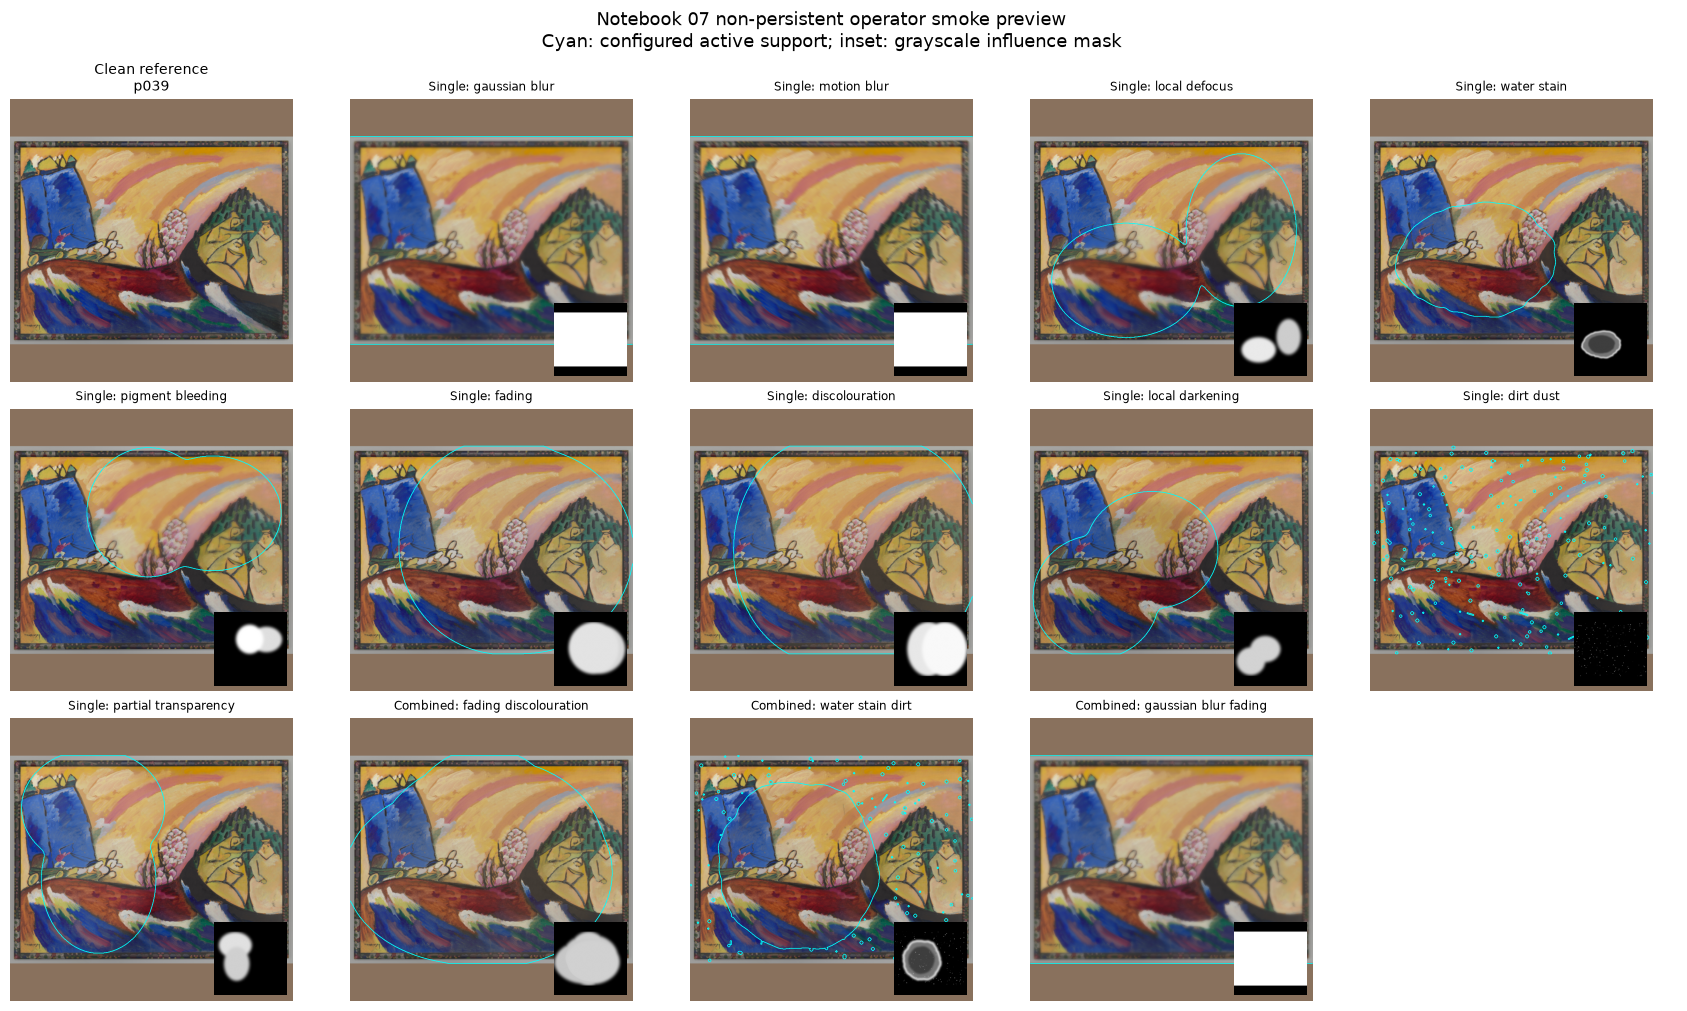

Rendered preview panels: 14
Preview saved to disk: False


In [9]:
# ---------------------------------------------------------------------------
# Render all single and combined smoke cases without saving
# ---------------------------------------------------------------------------

smoke_preview_figure, smoke_preview_axes = (
    plt.subplots(
        3,
        5,
        figsize=(
            17,
            10,
        ),
        constrained_layout=True,
    )
)

smoke_preview_axes_flat = (
    smoke_preview_axes.ravel()
)

smoke_preview_axes_flat[
    0
].imshow(
    smoke_clean_array
)

smoke_preview_axes_flat[
    0
].set_title(
    "Clean reference\np039",
    fontsize=10,
)

smoke_preview_axes_flat[
    0
].axis(
    "off"
)

for axis, design_row in zip(
    smoke_preview_axes_flat[
        1:
    ],
    smoke_case_design_df.to_dict(
        "records"
    ),
):
    case_id = str(
        design_row[
            "case_id"
        ]
    )

    generated_case = (
        smoke_generated_cases[
            case_id
        ]
    )

    degraded_array = (
        generated_case[
            "degraded_array"
        ]
    )

    mask_array = (
        generated_case[
            "mask_array"
        ]
    )

    active_threshold = int(
        generated_case[
            "generated"
        ].metadata[
            "active_threshold"
        ]
    )

    active_support = (
        mask_array
        >= active_threshold
    )

    axis.imshow(
        degraded_array
    )

    if active_support.any():
        axis.contour(
            active_support,
            levels=[
                0.5,
            ],
            colors=[
                "cyan",
            ],
            linewidths=0.55,
        )

    title_prefix = (
        "Combined"
        if bool(
            design_row[
                "is_combined"
            ]
        )
        else "Single"
    )

    axis.set_title(
        (
            f"{title_prefix}: "
            f"{str(design_row['degradation_family']).replace('_', ' ')}"
        ),
        fontsize=8.5,
    )

    axis.axis(
        "off"
    )

    mask_inset = axis.inset_axes(
        [
            0.72,
            0.02,
            0.26,
            0.26,
        ]
    )

    mask_inset.imshow(
        mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    mask_inset.axis(
        "off"
    )

for axis in smoke_preview_axes_flat[
    len(
        smoke_case_design_df
    )
    + 1:
]:
    axis.axis(
        "off"
    )

smoke_preview_figure.suptitle(
    (
        "Notebook 07 non-persistent operator smoke preview\n"
        "Cyan: configured active support; inset: grayscale influence mask"
    ),
    fontsize=13,
)

SMOKE_PREVIEW_PANEL_COUNT = (
    1
    + len(
        smoke_case_design_df
    )
)

display(
    smoke_preview_figure
)

plt.close(
    smoke_preview_figure
)

print(
    "Rendered preview panels:",
    SMOKE_PREVIEW_PANEL_COUNT,
)

print(
    "Preview saved to disk:",
    False,
)

In [10]:
BATCH_3_STAGE = (
    "batch_3_nonpersistent_smoke"
)


def add_batch_3_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return VALIDATION.add(
        validation_stage=BATCH_3_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# 1. Smoke cardinality

add_batch_3_check(
    check_id="smoke_cardinality",
    description=(
        "The executed smoke stage contains exactly "
        "ten single and three combined cases."
    ),
    expected={
        "total_cases": 13,
        "single_cases": 10,
        "combined_cases": 3,
    },
    observed={
        "total_cases": len(
            smoke_generation_audit_df
        ),
        "single_cases": int(
            (
                ~smoke_generation_audit_df[
                    "is_combined"
                ]
            ).sum()
        ),
        "combined_cases": int(
            smoke_generation_audit_df[
                "is_combined"
            ].sum()
        ),
    },
    passed=(
        len(
            smoke_generation_audit_df
        )
        == 13
        and int(
            (
                ~smoke_generation_audit_df[
                    "is_combined"
                ]
            ).sum()
        )
        == 10
        and int(
            smoke_generation_audit_df[
                "is_combined"
            ].sum()
        )
        == 3
    ),
)


# 2. Complete family coverage

expected_smoke_families = set(
    (
        *SUPPORTED_SINGLE_FAMILIES,
        *SUPPORTED_COMBINED_FAMILIES,
    )
)

observed_smoke_families = set(
    smoke_generation_audit_df[
        "degradation_family"
    ].astype(
        str
    )
)

add_batch_3_check(
    check_id="operator_family_coverage",
    description=(
        "Every configured single and combined "
        "degradation family was executed."
    ),
    expected={
        "families": sorted(
            expected_smoke_families
        ),
        "missing": [],
    },
    observed={
        "families": sorted(
            observed_smoke_families
        ),
        "missing": sorted(
            expected_smoke_families
            - observed_smoke_families
        ),
    },
    passed=(
        observed_smoke_families
        == expected_smoke_families
    ),
)


# 3. Effect-mask determinism

add_batch_3_check(
    check_id="effect_mask_determinism",
    description=(
        "Every repeated effect mask is "
        "pixel-identical."
    ),
    expected={
        "deterministic_cases": 13,
    },
    observed={
        "deterministic_cases": int(
            smoke_generation_audit_df[
                "effect_mask_deterministic"
            ].sum()
        ),
    },
    passed=smoke_generation_audit_df[
        "effect_mask_deterministic"
    ].all(),
)


# 4. Degraded-image determinism

add_batch_3_check(
    check_id="degraded_image_determinism",
    description=(
        "Every repeated degraded image is "
        "pixel-identical."
    ),
    expected={
        "deterministic_cases": 13,
    },
    observed={
        "deterministic_cases": int(
            smoke_generation_audit_df[
                "degraded_image_deterministic"
            ].sum()
        ),
    },
    passed=smoke_generation_audit_df[
        "degraded_image_deterministic"
    ].all(),
)


# 5. Metadata determinism

add_batch_3_check(
    check_id="metadata_determinism",
    description=(
        "Seeds, parameters, support metadata, "
        "and impact metrics repeat exactly."
    ),
    expected={
        "deterministic_cases": 13,
    },
    observed={
        "deterministic_cases": int(
            smoke_generation_audit_df[
                "metadata_deterministic"
            ].sum()
        ),
    },
    passed=smoke_generation_audit_df[
        "metadata_deterministic"
    ].all(),
)


# 6. Modes and dimensions

mode_dimension_passed = (
    smoke_generation_audit_df[
        "effect_mask_mode"
    ].eq(
        "L"
    ).all()
    and smoke_generation_audit_df[
        "degraded_mode"
    ].eq(
        "RGB"
    ).all()
    and smoke_generation_audit_df[
        "width"
    ].eq(
        int(
            smoke_geometry_row[
                "width"
            ]
        )
    ).all()
    and smoke_generation_audit_df[
        "height"
    ].eq(
        int(
            smoke_geometry_row[
                "height"
            ]
        )
    ).all()
)

add_batch_3_check(
    check_id="mode_and_dimensions",
    description=(
        "All effect masks are L images and all "
        "degraded outputs are dimension-matched RGB."
    ),
    expected={
        "effect_mask_mode": "L",
        "degraded_mode": "RGB",
        "width": int(
            smoke_geometry_row[
                "width"
            ]
        ),
        "height": int(
            smoke_geometry_row[
                "height"
            ]
        ),
    },
    observed={
        "effect_mask_modes": sorted(
            smoke_generation_audit_df[
                "effect_mask_mode"
            ].unique().tolist()
        ),
        "degraded_modes": sorted(
            smoke_generation_audit_df[
                "degraded_mode"
            ].unique().tolist()
        ),
        "widths": sorted(
            smoke_generation_audit_df[
                "width"
            ].unique().tolist()
        ),
        "heights": sorted(
            smoke_generation_audit_df[
                "height"
            ].unique().tolist()
        ),
    },
    passed=mode_dimension_passed,
)


# 7. Spatial support containment

add_batch_3_check(
    check_id="support_content_containment",
    description=(
        "Every non-zero influence-mask pixel "
        "remains inside painting content."
    ),
    expected={
        "outside_content_support_pixels": 0,
    },
    observed={
        "outside_content_support_pixels": int(
            smoke_generation_audit_df[
                "outside_content_support_pixels"
            ].sum()
        ),
    },
    passed=smoke_generation_audit_df[
        "outside_content_support_pixels"
    ].eq(
        0
    ).all(),
)


# 8. Soft influence semantics

soft_support_failures = (
    smoke_generation_audit_df.loc[
        ~smoke_generation_audit_df[
            "soft_support_valid"
        ],
        "case_id",
    ].tolist()
)

add_batch_3_check(
    check_id="soft_influence_semantics",
    description=(
        "Every applicable soft-support case "
        "contains intermediate influence values."
    ),
    expected={
        "invalid_soft_support_cases": 0,
    },
    observed={
        "invalid_soft_support_cases": len(
            soft_support_failures
        ),
    },
    passed=not soft_support_failures,
    details=soft_support_failures,
)


# 9. Non-empty support and degradation

nonempty_columns = [
    "support_nonempty",
    "active_support_nonempty",
    "degradation_nonempty",
]

add_batch_3_check(
    check_id="nonempty_effects",
    description=(
        "Every case contains support, active "
        "support, and at least one changed pixel."
    ),
    expected={
        "failed_fields": 0,
    },
    observed={
        "failed_fields": int(
            (
                ~smoke_generation_audit_df[
                    nonempty_columns
                ]
            ).sum().sum()
        ),
    },
    passed=smoke_generation_audit_df[
        nonempty_columns
    ].all().all(),
)


# 10. Changed pixels remain in support

add_batch_3_check(
    check_id="changed_pixels_within_support",
    description=(
        "No operator changes pixels outside its "
        "recorded effect support."
    ),
    expected={
        "outside_support_changed_pixels": 0,
    },
    observed={
        "outside_support_changed_pixels": int(
            smoke_generation_audit_df[
                "outside_support_changed_pixels"
            ].sum()
        ),
    },
    passed=smoke_generation_audit_df[
        "outside_support_changed_pixels"
    ].eq(
        0
    ).all(),
)


# 11. Pixel-count reconciliation

count_match_columns = [
    "support_pixels_match",
    "active_pixels_match",
    "changed_pixels_match",
]

add_batch_3_check(
    check_id="pixel_count_reconciliation",
    description=(
        "Support, active-support, and changed "
        "pixel counts match generated metadata."
    ),
    expected={
        "failed_fields": 0,
    },
    observed={
        "failed_fields": int(
            (
                ~smoke_generation_audit_df[
                    count_match_columns
                ]
            ).sum().sum()
        ),
    },
    passed=smoke_generation_audit_df[
        count_match_columns
    ].all().all(),
)


# 12. Parameters and seeds

parameter_seed_columns = [
    "parameter_components_match",
    "seed_components_match",
]

add_batch_3_check(
    check_id="parameter_and_seed_records",
    description=(
        "Every component has an explicit parameter "
        "mapping and deterministic operator seed."
    ),
    expected={
        "failed_fields": 0,
    },
    observed={
        "failed_fields": int(
            (
                ~smoke_generation_audit_df[
                    parameter_seed_columns
                ]
            ).sum().sum()
        ),
    },
    passed=smoke_generation_audit_df[
        parameter_seed_columns
    ].all().all(),
)


# 13. Finite impact proxies

add_batch_3_check(
    check_id="impact_metrics_finite",
    description=(
        "All colour, luminance, saturation, "
        "gradient, and texture proxies are finite."
    ),
    expected={
        "finite_cases": 13,
    },
    observed={
        "finite_cases": int(
            smoke_generation_audit_df[
                "impact_metrics_finite"
            ].sum()
        ),
    },
    passed=smoke_generation_audit_df[
        "impact_metrics_finite"
    ].all(),
)


# 14. Distinct degraded results and unchanged clean reference

unique_degraded_results = (
    smoke_generation_audit_df[
        "degraded_pixel_sha256"
    ].nunique()
)

clean_reference_unchanged = (
    smoke_clean_sha256_before
    == smoke_clean_sha256_after
)

add_batch_3_check(
    check_id="result_distinctness_and_clean_preservation",
    description=(
        "All 13 degraded results are distinct "
        "while the clean reference remains unchanged."
    ),
    expected={
        "unique_degraded_results": 13,
        "clean_reference_unchanged": True,
    },
    observed={
        "unique_degraded_results": int(
            unique_degraded_results
        ),
        "clean_reference_unchanged": (
            clean_reference_unchanged
        ),
    },
    passed=(
        unique_degraded_results
        == 13
        and clean_reference_unchanged
    ),
)


# 15. Preview and non-persistence

scientific_files_after_batch_3 = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
)

add_batch_3_check(
    check_id="preview_and_nonpersistence",
    description=(
        "The 14-panel preview rendered in memory "
        "and no scientific file was written."
    ),
    expected={
        "preview_panels": 14,
        "scientific_files": 0,
    },
    observed={
        "preview_panels": (
            SMOKE_PREVIEW_PANEL_COUNT
        ),
        "scientific_files": len(
            scientific_files_after_batch_3
        ),
    },
    passed=(
        SMOKE_PREVIEW_PANEL_COUNT
        == 14
        and not scientific_files_after_batch_3
    ),
    details=scientific_files_after_batch_3,
)


# ---------------------------------------------------------------------------
# Batch 3 completion gate and evidence
# ---------------------------------------------------------------------------

batch_3_checks_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_3_STAGE
        )
    ]
    .reset_index(
        drop=True
    )
)

if len(
    batch_3_checks_df
) != 15:
    raise RuntimeError(
        "Batch 3 must contain exactly "
        f"15 checks; observed "
        f"{len(batch_3_checks_df)}."
    )

VALIDATION.raise_for_blocking()

print(
    "Batch 3 validation checks:"
)

display(
    batch_3_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nOperator smoke audit:"
)

display(
    smoke_generation_audit_df[
        [
            "degradation_family",
            "is_combined",
            "components",
            "component_support_types",
            "mask_unique_value_count",
            "support_pixels",
            "active_pixels",
            "changed_pixels",
            "outside_support_changed_pixels",
            "mean_absolute_rgb_difference",
            "mean_rgb_colour_distance",
            "mean_luminance_shift",
            "mean_saturation_shift",
            "gradient_energy_ratio",
            "laplacian_variance_ratio",
            "effect_mask_deterministic",
            "degraded_image_deterministic",
        ]
    ]
)

effect_mask_reuse_df = (
    smoke_generation_audit_df
    .groupby(
        "effect_mask_pixel_sha256",
        as_index=False,
    )
    .agg(
        families=(
            "degradation_family",
            lambda values: " | ".join(
                values.astype(
                    str
                )
            ),
        ),
        case_count=(
            "case_id",
            "size",
        ),
    )
    .sort_values(
        [
            "case_count",
            "families",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nEffect-support reuse audit:"
)

print(
    "Identical support masks across different "
    "operators are permitted because spatial "
    "support and degradation operators are "
    "separate experimental components."
)

display(
    effect_mask_reuse_df
)

print(
    "\nBatch 3 completed successfully."
)

print(
    "Batch 3 checks:",
    len(
        batch_3_checks_df
    ),
)

print(
    "Batch 3 passed:",
    int(
        batch_3_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Cumulative checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Scientific output files:",
    len(
        scientific_files_after_batch_3
    ),
)

print(
    "Next approved stage: Batch 4 - "
    "complete canonical 165-case generation "
    "with progress every 10 completed cases."
)

Batch 3 validation checks:


,check_id,severity,expected,observed,passed
0,smoke_cardinality,blocking,"{""combined_cases"": 3, ""single_cases"": 10, ""tot...","{""combined_cases"": 3, ""single_cases"": 10, ""tot...",True
1,operator_family_coverage,blocking,"{""families"": [""dirt_dust"", ""discolouration"", ""...","{""families"": [""dirt_dust"", ""discolouration"", ""...",True
2,effect_mask_determinism,blocking,"{""deterministic_cases"": 13}","{""deterministic_cases"": 13}",True
3,degraded_image_determinism,blocking,"{""deterministic_cases"": 13}","{""deterministic_cases"": 13}",True
4,metadata_determinism,blocking,"{""deterministic_cases"": 13}","{""deterministic_cases"": 13}",True
5,mode_and_dimensions,blocking,"{""degraded_mode"": ""RGB"", ""effect_mask_mode"": ""...","{""degraded_modes"": [""RGB""], ""effect_mask_modes...",True
6,support_content_containment,blocking,"{""outside_content_support_pixels"": 0}","{""outside_content_support_pixels"": 0}",True
7,soft_influence_semantics,blocking,"{""invalid_soft_support_cases"": 0}","{""invalid_soft_support_cases"": 0}",True
8,nonempty_effects,blocking,"{""failed_fields"": 0}","{""failed_fields"": 0}",True
9,changed_pixels_within_support,blocking,"{""outside_support_changed_pixels"": 0}","{""outside_support_changed_pixels"": 0}",True



Operator smoke audit:


,degradation_family,is_combined,components,component_support_types,mask_unique_value_count,support_pixels,active_pixels,changed_pixels,outside_support_changed_pixels,mean_absolute_rgb_difference,mean_rgb_colour_distance,mean_luminance_shift,mean_saturation_shift,gradient_energy_ratio,laplacian_variance_ratio,effect_mask_deterministic,degraded_image_deterministic
0,gaussian_blur,False,gaussian_blur,full_content,2,433152,433152,430482,0,6.664389,12.686154,-0.000580,-0.005736,0.439106,0.075049,True,True
1,motion_blur,False,motion_blur,full_content,2,433152,433152,427091,0,5.936607,11.330775,-0.000397,-0.003654,0.559978,0.148274,True,True
2,local_defocus,False,local_defocus,soft_local_blobs,235,224489,195060,185512,0,5.051825,9.699995,0.000003,-0.006706,0.595142,0.328483,True,True
3,water_stain,False,water_stain,soft_ring_stain,209,110780,103365,105295,0,4.447665,8.532005,-0.002149,-0.008843,0.915052,0.837363,True,True
4,pigment_bleeding,False,pigment_bleeding,soft_local_blobs,256,166816,146722,140654,0,3.419814,6.676390,-0.000020,-0.001956,0.665374,0.452389,True,True
5,fading,False,fading,soft_broad_patch,228,311612,291072,283452,0,3.869538,7.770506,0.007667,-0.032797,0.975377,0.954126,True,True
6,discolouration,False,discolouration,soft_broad_patch,250,341529,326493,324438,0,5.133882,10.240778,0.018568,0.001140,0.902206,0.817676,True,True
7,local_darkening,False,local_darkening,soft_local_blobs,212,170822,151282,156681,0,10.089534,18.364798,-0.039010,-0.025041,0.901429,0.808480,True,True
8,dirt_dust,False,dirt_dust,speckles_and_streaks,246,10707,6962,8130,0,5.093708,9.591962,-0.016981,-0.016585,1.206424,1.072898,True,True
9,partial_transparency,False,partial_transparency,soft_local_blobs,226,179743,160206,165784,0,9.292508,17.060558,0.037374,-0.025816,0.915234,0.840680,True,True



Effect-support reuse audit:
Identical support masks across different operators are permitted because spatial support and degradation operators are separate experimental components.


,effect_mask_pixel_sha256,families,case_count
0,282059aa1b4c2feef723f749a1dcdb3d0ed0b16ad4f639...,gaussian_blur | motion_blur | gaussian_blur_fa...,3
1,ef64130555691694fd021c2598703dda89711c56d88a4d...,dirt_dust,1
2,685e305ff84d857f7d060e5edf60bf75f7f15ef0199533...,discolouration,1
3,a97d8257dfa54f99f5e9b559af86b2e7583d74f86458c1...,fading,1
4,3c691a63fed7cb938e1af049bd5b2e6494175861f4d433...,fading_discolouration,1
5,bcbcedca35759723d8d48c2b4d97deaa878ea9de6864dd...,local_darkening,1
6,d6448870c24d1e28336c4db77a840777b0c1626031e690...,local_defocus,1
7,8c9283040cc315e806a5e81fb251b32ee6eab6266f3def...,partial_transparency,1
8,41d2c07dff69e15d406daae258f91da2effedb25c0f10f...,pigment_bleeding,1
9,cc5c97353b6e283ea045bc0c01557f3b593180b2979254...,water_stain,1



Batch 3 completed successfully.
Batch 3 checks: 15
Batch 3 passed: 15
Cumulative checks: 44
Scientific output files: 0
Next approved stage: Batch 4 - complete canonical 165-case generation with progress every 10 completed cases.


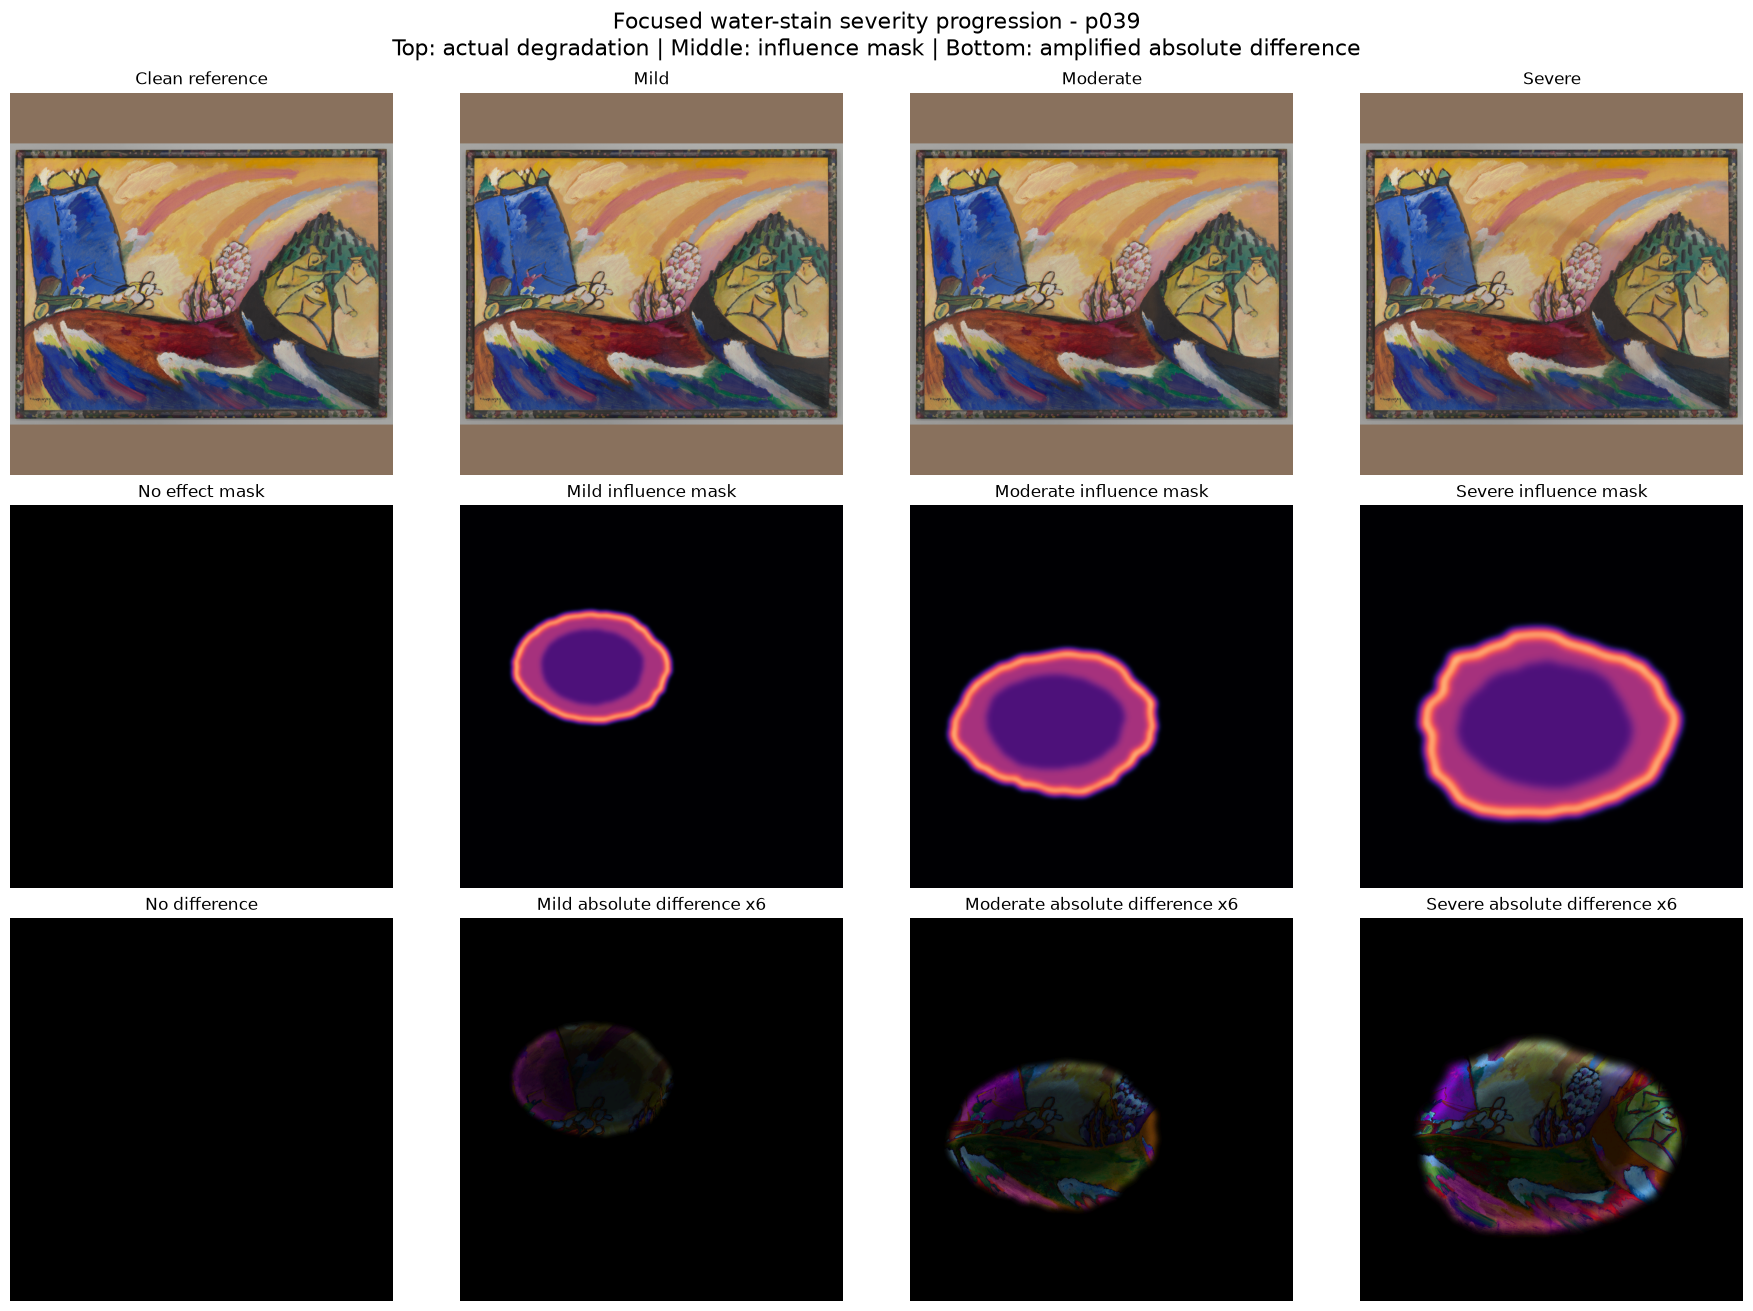

,severity,mean_absolute_rgb_difference,mean_rgb_colour_distance,support_pixels,changed_pixels,changed_fraction_within_support,changed_pixels_outside_support
0,mild,2.814173,5.308542,65647,61011,0.929380,0
1,moderate,4.447665,8.532005,110780,105295,0.950487,0
2,severe,6.715223,12.700581,184430,176421,0.956574,0


Focused cases checked: 3
Scientific files written by diagnostic: 0


In [11]:
# Focused water-stain severity diagnostic
# In-memory only: this cell writes no files.

water_design_df = (
    case_design_df.loc[
        (case_design_df["painting_id"] == "p039")
        & (case_design_df["degradation_family"] == "water_stain")
        & (~case_design_df["is_combined"])
    ]
    .sort_values("severity_rank")
    .reset_index(drop=True)
)

assert water_design_df["severity"].tolist() == [
    "mild",
    "moderate",
    "severe",
]

water_results = []

for design_row in water_design_df.to_dict("records"):
    generated = generate_degradation_case(
        clean_image=smoke_clean_image,
        geometry=smoke_geometry_row,
        design_row=design_row,
        config=synthetic_config,
    )

    degraded_array = np.asarray(
        generated.degraded,
        dtype=np.uint8,
    )

    effect_mask_array = np.asarray(
        generated.effect_mask,
        dtype=np.uint8,
    )

    difference = np.abs(
        degraded_array.astype(np.int16)
        - smoke_clean_array.astype(np.int16)
    ).astype(np.float32)

    water_results.append(
        {
            "severity": design_row["severity"],
            "image": degraded_array,
            "mask": effect_mask_array,
            "difference": difference,
            "metadata": dict(generated.metadata),
        }
    )

fig, axes = plt.subplots(
    3,
    4,
    figsize=(18, 13),
    constrained_layout=True,
)

column_titles = [
    "Clean reference",
    "Mild",
    "Moderate",
    "Severe",
]

# Clean-reference column
axes[0, 0].imshow(smoke_clean_array)
axes[0, 0].set_title(column_titles[0])

axes[1, 0].imshow(
    np.zeros(smoke_clean_array.shape[:2], dtype=np.uint8),
    cmap="gray",
    vmin=0,
    vmax=255,
)
axes[1, 0].set_title("No effect mask")

axes[2, 0].imshow(
    np.zeros_like(smoke_clean_array)
)
axes[2, 0].set_title("No difference")

diagnostic_rows = []

for column_index, result in enumerate(
    water_results,
    start=1,
):
    severity = result["severity"]
    degraded_array = result["image"]
    effect_mask_array = result["mask"]
    difference = result["difference"]
    metadata = result["metadata"]

    # No contour overlay: judge the degradation itself.
    axes[0, column_index].imshow(degraded_array)
    axes[0, column_index].set_title(
        column_titles[column_index]
    )

    axes[1, column_index].imshow(
        effect_mask_array,
        cmap="magma",
        vmin=0,
        vmax=255,
    )
    axes[1, column_index].set_title(
        f"{severity.title()} influence mask"
    )

    # Amplification is diagnostic only.
    amplified_difference = np.clip(
        difference * 6.0,
        0,
        255,
    ).astype(np.uint8)

    axes[2, column_index].imshow(
        amplified_difference
    )
    axes[2, column_index].set_title(
        f"{severity.title()} absolute difference x6"
    )

    support_threshold = int(
        metadata["support_threshold"]
    )

    support_mask = (
        effect_mask_array >= support_threshold
    )

    changed_mask = np.any(
        degraded_array != smoke_clean_array,
        axis=2,
    )

    diagnostic_rows.append(
        {
            "severity": severity,
            "mean_absolute_rgb_difference": float(
                metadata["mean_absolute_rgb_difference"]
            ),
            "mean_rgb_colour_distance": float(
                metadata["mean_rgb_colour_distance"]
            ),
            "support_pixels": int(
                support_mask.sum()
            ),
            "changed_pixels": int(
                changed_mask.sum()
            ),
            "changed_fraction_within_support": float(
                changed_mask[support_mask].mean()
            ),
            "changed_pixels_outside_support": int(
                (
                    changed_mask
                    & ~support_mask
                ).sum()
            ),
        }
    )

for axis in axes.flat:
    axis.axis("off")

fig.suptitle(
    "Focused water-stain severity progression - p039\n"
    "Top: actual degradation | Middle: influence mask | "
    "Bottom: amplified absolute difference",
    fontsize=16,
)

plt.show()

water_diagnostic_df = pd.DataFrame(
    diagnostic_rows
)

display(water_diagnostic_df)

scientific_files = [
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
]

print(
    "Focused cases checked:",
    len(water_results),
)
print(
    "Scientific files written by diagnostic:",
    len(scientific_files),
)

assert len(water_results) == 3
assert len(scientific_files) == 0
assert (
    water_diagnostic_df[
        "changed_pixels_outside_support"
    ]
    == 0
).all()

## Batch 4 - Complete Canonical Dataset Generation

This batch generates and persists the complete approved synthetic-degradation dataset.

It will:

- rebuild the canonical 165-case design directly from the versioned configuration;
- generate 150 single-degradation cases across three severity levels;
- generate 15 selected combined-degradation cases;
- persist exactly 165 grayscale effect-support masks;
- persist exactly 165 degraded RGB images;
- preserve the canonical Notebook 02 clean references without modification;
- use stable case, mask, and operator seeds;
- report progress after every 10 completed cases and after the final case;
- report completed cases, percentage, elapsed time, throughput, and latest case ID;
- stop immediately on any generation failure rather than silently skipping a case;
- record successful execution, failure, retry, and stale-file accounting in memory;
- verify immediate case, image, progress, checksum, and output-scope invariants.

The configured stale-output policy replaces prior Notebook 07 PNG outputs only inside the canonical effect-mask and degraded-image directories. It does not modify upstream Notebook 02 inputs or any other notebook-owned output root.

This batch persists the canonical images but keeps the normalized case table and execution checks in memory. Complete filesystem reload validation and consolidated tabular persistence occur in later batches.

In [12]:
import time


# ---------------------------------------------------------------------------
# Rebuild the canonical generation design
# ---------------------------------------------------------------------------

canonical_generation_design_df = (
    build_degradation_design(
        synthetic_config
    )
)

expected_generation_case_ids = (
    case_design_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

canonical_generation_case_ids = (
    canonical_generation_design_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

assert (
    canonical_generation_case_ids
    == expected_generation_case_ids
)

EXPECTED_GENERATION_CASE_COUNT = int(
    synthetic_config[
        "expected"
    ][
        "case_count"
    ]
)

PROGRESS_INTERVAL_CASES = int(
    synthetic_config[
        "generator"
    ][
        "progress_interval_cases"
    ]
)

assert (
    len(
        canonical_generation_design_df
    )
    == EXPECTED_GENERATION_CASE_COUNT
)

assert PROGRESS_INTERVAL_CASES == 10


# ---------------------------------------------------------------------------
# Record clean-reference checksums before generation
# ---------------------------------------------------------------------------

cohort_clean_paths = {}

for geometry_row in cohort_df.to_dict(
    "records"
):
    painting_id = str(
        geometry_row[
            "painting_id"
        ]
    )

    cohort_clean_paths[
        painting_id
    ] = resolve_repo_path(
        str(
            geometry_row[
                "processed_path"
            ]
        ),
        PROJECT_ROOT,
    )

cohort_clean_sha256_before = {
    painting_id: sha256_file(
        clean_path
    )
    for painting_id, clean_path
    in cohort_clean_paths.items()
}


# ---------------------------------------------------------------------------
# Progress callback
# ---------------------------------------------------------------------------

generation_progress_records = []
generation_started_clock = (
    time.perf_counter()
)

generation_started_at_utc = (
    utc_now_iso()
)


def report_generation_progress(
    completed,
    total,
    latest_case_id,
):
    elapsed_seconds = (
        time.perf_counter()
        - generation_started_clock
    )

    percentage = (
        100.0
        * completed
        / total
    )

    throughput = (
        completed
        / elapsed_seconds
        if elapsed_seconds > 0
        else 0.0
    )

    generation_progress_records.append(
        {
            "completed_cases": int(
                completed
            ),
            "total_cases": int(
                total
            ),
            "percentage": float(
                percentage
            ),
            "elapsed_seconds": float(
                elapsed_seconds
            ),
            "cases_per_second": float(
                throughput
            ),
            "latest_case_id": str(
                latest_case_id
            ),
        }
    )

    print(
        f"[{completed:>3}/{total}] "
        f"{percentage:6.2f}% | "
        f"elapsed={elapsed_seconds:8.2f}s | "
        f"throughput={throughput:6.2f} cases/s | "
        f"latest={latest_case_id}",
        flush=True,
    )


# ---------------------------------------------------------------------------
# Canonical persistent generation
# ---------------------------------------------------------------------------

print(
    "Canonical generation target:",
    OUTPUT_ROOT,
)

print(
    "Stale PNG action:",
    synthetic_config[
        "generator"
    ][
        "stale_file_action"
    ],
)

print(
    "Planned cases:",
    EXPECTED_GENERATION_CASE_COUNT,
)

print(
    "Progress interval:",
    PROGRESS_INTERVAL_CASES,
)

generation_failure = None

try:
    full_generation_result = (
        generate_synthetic_degradation_dataset(
            preprocessed=preprocessed_df,
            config=synthetic_config,
            project_root=PROJECT_ROOT,
            output_root=OUTPUT_ROOT,
            design=(
                canonical_generation_design_df
            ),
            persist=True,
            progress_callback=(
                report_generation_progress
            ),
        )
    )

except Exception as error:
    generation_failure = {
        "exception_type": type(
            error
        ).__name__,
        "exception_message": str(
            error
        ),
    }

    print(
        "Canonical generation failed:",
        generation_failure,
    )

    raise


generation_finished_at_utc = (
    utc_now_iso()
)

generation_elapsed_seconds = (
    time.perf_counter()
    - generation_started_clock
)

full_generation_cases_df = (
    full_generation_result
    .cases
    .copy()
)

removed_stale_paths = list(
    full_generation_result
    .removed_stale_paths
)

generation_progress_df = (
    pd.DataFrame(
        generation_progress_records
    )
)


# ---------------------------------------------------------------------------
# Record execution and retry accounting
# ---------------------------------------------------------------------------

generation_execution_df = pd.DataFrame(
    [
        {
            "attempt_number": 1,
            "execution_status": "passed",
            "started_at_utc": (
                generation_started_at_utc
            ),
            "finished_at_utc": (
                generation_finished_at_utc
            ),
            "elapsed_seconds": float(
                generation_elapsed_seconds
            ),
            "planned_case_count": int(
                EXPECTED_GENERATION_CASE_COUNT
            ),
            "completed_case_count": int(
                len(
                    full_generation_cases_df
                )
            ),
            "failed_case_count": 0,
            "skipped_case_count": 0,
            "retry_count": 0,
            "removed_stale_file_count": int(
                len(
                    removed_stale_paths
                )
            ),
            "last_completed_case_id": (
                str(
                    generation_progress_df.iloc[
                        -1
                    ][
                        "latest_case_id"
                    ]
                )
                if not generation_progress_df.empty
                else ""
            ),
            "failure_type": "",
            "failure_message": "",
        }
    ]
)


# ---------------------------------------------------------------------------
# Immediate filesystem inventory
# ---------------------------------------------------------------------------

generated_effect_mask_paths = sorted(
    EFFECT_MASK_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
)

generated_degraded_paths = sorted(
    DEGRADED_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
)

all_generated_image_paths = [
    *generated_effect_mask_paths,
    *generated_degraded_paths,
]

cohort_clean_sha256_after = {
    painting_id: sha256_file(
        clean_path
    )
    for painting_id, clean_path
    in cohort_clean_paths.items()
}


# ---------------------------------------------------------------------------
# Concise execution summary
# ---------------------------------------------------------------------------

display(
    generation_execution_df
)

print(
    "Generated case rows:",
    len(
        full_generation_cases_df
    ),
)

print(
    "Effect-mask PNG files:",
    len(
        generated_effect_mask_paths
    ),
)

print(
    "Degraded RGB PNG files:",
    len(
        generated_degraded_paths
    ),
)

print(
    "Removed stale PNG files:",
    len(
        removed_stale_paths
    ),
)

print(
    "Clean references unchanged:",
    (
        cohort_clean_sha256_before
        == cohort_clean_sha256_after
    ),
)

print(
    "Total elapsed seconds:",
    round(
        generation_elapsed_seconds,
        2,
    ),
)

print(
    "Overall throughput:",
    round(
        (
            len(
                full_generation_cases_df
            )
            / generation_elapsed_seconds
        ),
        3,
    ),
    "cases/s",
)

print(
    "\nFinal progress events:"
)

display(
    generation_progress_df.tail(
        5
    )
)

Canonical generation target: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\07_synthetic_degradation_dataset_generation
Stale PNG action: remove
Planned cases: 165
Progress interval: 10
[ 10/165]   6.06% | elapsed=   12.09s | throughput=  0.83 cases/s | latest=synthetic_degradation__p001__water_stain__mild
[ 20/165]  12.12% | elapsed=   22.90s | throughput=  0.87 cases/s | latest=synthetic_degradation__p001__discolouration__moderate
[ 30/165]  18.18% | elapsed=   33.24s | throughput=  0.90 cases/s | latest=synthetic_degradation__p001__partial_transparency__severe
[ 40/165]  24.24% | elapsed=   45.44s | throughput=  0.88 cases/s | latest=synthetic_degradation__p018__local_defocus__mild
[ 50/165]  30.30% | elapsed=   54.98s | throughput=  0.91 cases/s | latest=synthetic_degradation__p018__fading__moderate
[ 60/165]  36.36% | elapsed=   63.52s | throughput=  0.94 cases/s | latest=synthetic_degradation__p018__dirt_dust__severe
[ 70/165]  42.42% | elapsed=   73.30s | throughput=  0.

,attempt_number,execution_status,started_at_utc,finished_at_utc,elapsed_seconds,planned_case_count,completed_case_count,failed_case_count,skipped_case_count,retry_count,removed_stale_file_count,last_completed_case_id,failure_type,failure_message
0,1,passed,2026-08-19T22:52:33.406116Z,2026-08-19T22:55:15.028851Z,161.622902,165,165,0,0,0,0,synthetic_degradation__p043__gaussian_blur_fad...,,


Generated case rows: 165
Effect-mask PNG files: 165
Degraded RGB PNG files: 165
Removed stale PNG files: 0
Clean references unchanged: True
Total elapsed seconds: 161.62
Overall throughput: 1.021 cases/s

Final progress events:


,completed_cases,total_cases,percentage,elapsed_seconds,cases_per_second,latest_case_id
12,130,165,78.787879,127.486811,1.019713,synthetic_degradation__p039__fading_discoloura...
13,140,165,84.848485,137.376607,1.019096,synthetic_degradation__p043__local_defocus__mo...
14,150,165,90.909091,146.317328,1.025169,synthetic_degradation__p043__fading__severe
15,160,165,96.969697,156.451530,1.022681,synthetic_degradation__p043__partial_transpare...
16,165,165,100.000000,161.597960,1.021052,synthetic_degradation__p043__gaussian_blur_fad...


In [13]:
BATCH_4_STAGE = (
    "batch_4_complete_generation"
)


def add_batch_4_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return VALIDATION.add(
        validation_stage=BATCH_4_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# Expected progress sequence
# ---------------------------------------------------------------------------

expected_progress_completed = list(
    range(
        PROGRESS_INTERVAL_CASES,
        EXPECTED_GENERATION_CASE_COUNT + 1,
        PROGRESS_INTERVAL_CASES,
    )
)

if (
    not expected_progress_completed
    or expected_progress_completed[-1]
    != EXPECTED_GENERATION_CASE_COUNT
):
    expected_progress_completed.append(
        EXPECTED_GENERATION_CASE_COUNT
    )

observed_progress_completed = (
    generation_progress_df[
        "completed_cases"
    ]
    .astype(int)
    .tolist()
)


# ---------------------------------------------------------------------------
# Generated case schema
# ---------------------------------------------------------------------------

full_generation_schema_result = (
    validate_dataframe(
        full_generation_cases_df,
        SYNTHETIC_DEGRADATION_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Resolve every declared generated image path
# ---------------------------------------------------------------------------

declared_effect_mask_paths = [
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
    )
    for relative_path in (
        full_generation_cases_df[
            "effect_mask_path"
        ]
        .astype(str)
        .tolist()
    )
]

declared_degraded_paths = [
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
    )
    for relative_path in (
        full_generation_cases_df[
            "degraded_image_path"
        ]
        .astype(str)
        .tolist()
    )
]

declared_generated_paths = [
    *declared_effect_mask_paths,
    *declared_degraded_paths,
]

generated_paths_contained = all(
    path.resolve().is_relative_to(
        OUTPUT_ROOT.resolve()
    )
    for path in declared_generated_paths
)

removed_paths_contained = all(
    Path(path).resolve().is_relative_to(
        OUTPUT_ROOT.resolve()
    )
    for path in removed_stale_paths
)


# 1. Complete case cardinality

add_batch_4_check(
    check_id="full_generation_cardinality",
    description=(
        "Canonical generation returns exactly "
        "165 cases with the approved single and "
        "combined case distribution."
    ),
    expected={
        "total_cases": 165,
        "single_cases": 150,
        "combined_cases": 15,
    },
    observed={
        "total_cases": len(
            full_generation_cases_df
        ),
        "single_cases": int(
            (
                ~full_generation_cases_df[
                    "is_combined"
                ].astype(bool)
            ).sum()
        ),
        "combined_cases": int(
            full_generation_cases_df[
                "is_combined"
            ].astype(bool).sum()
        ),
    },
    passed=(
        len(
            full_generation_cases_df
        )
        == int(
            synthetic_config[
                "expected"
            ][
                "case_count"
            ]
        )
        and int(
            (
                ~full_generation_cases_df[
                    "is_combined"
                ].astype(bool)
            ).sum()
        )
        == int(
            synthetic_config[
                "expected"
            ][
                "single_case_count"
            ]
        )
        and int(
            full_generation_cases_df[
                "is_combined"
            ].astype(bool).sum()
        )
        == int(
            synthetic_config[
                "expected"
            ][
                "combined_case_count"
            ]
        )
    ),
)


# 2. Schema and stable identity

add_batch_4_check(
    check_id="generated_schema_and_identity",
    description=(
        "Generated cases satisfy the normalized "
        "schema and retain the complete canonical "
        "case order without duplicate identifiers."
    ),
    expected={
        "schema_passed": True,
        "unexpected_columns": 0,
        "case_order_matches": True,
        "duplicate_case_ids": 0,
    },
    observed={
        "schema_passed": (
            full_generation_schema_result.passed
        ),
        "unexpected_columns": len(
            full_generation_schema_result
            .unexpected_columns
        ),
        "case_order_matches": (
            full_generation_cases_df[
                "case_id"
            ].astype(str).tolist()
            == canonical_generation_case_ids
        ),
        "duplicate_case_ids": int(
            full_generation_cases_df[
                "case_id"
            ].duplicated().sum()
        ),
    },
    passed=(
        full_generation_schema_result.passed
        and not (
            full_generation_schema_result
            .unexpected_columns
        )
        and (
            full_generation_cases_df[
                "case_id"
            ].astype(str).tolist()
            == canonical_generation_case_ids
        )
        and not full_generation_cases_df[
            "case_id"
        ].duplicated().any()
    ),
    details=(
        full_generation_schema_result.to_dict()
    ),
)


# 3. Successful execution with no skips or retries

add_batch_4_check(
    check_id="execution_accounting",
    description=(
        "The complete design finishes in one "
        "successful attempt without failed, skipped, "
        "or silently omitted cases."
    ),
    expected={
        "execution_status": "passed",
        "completed_cases": 165,
        "failed_cases": 0,
        "skipped_cases": 0,
        "retries": 0,
    },
    observed={
        "execution_status": (
            generation_execution_df.iloc[
                0
            ][
                "execution_status"
            ]
        ),
        "completed_cases": int(
            generation_execution_df.iloc[
                0
            ][
                "completed_case_count"
            ]
        ),
        "failed_cases": int(
            generation_execution_df.iloc[
                0
            ][
                "failed_case_count"
            ]
        ),
        "skipped_cases": int(
            generation_execution_df.iloc[
                0
            ][
                "skipped_case_count"
            ]
        ),
        "retries": int(
            generation_execution_df.iloc[
                0
            ][
                "retry_count"
            ]
        ),
    },
    passed=(
        generation_failure is None
        and generation_execution_df.iloc[
            0
        ][
            "execution_status"
        ]
        == "passed"
        and int(
            generation_execution_df.iloc[
                0
            ][
                "completed_case_count"
            ]
        )
        == EXPECTED_GENERATION_CASE_COUNT
        and int(
            generation_execution_df.iloc[
                0
            ][
                "failed_case_count"
            ]
        )
        == 0
        and int(
            generation_execution_df.iloc[
                0
            ][
                "skipped_case_count"
            ]
        )
        == 0
        and int(
            generation_execution_df.iloc[
                0
            ][
                "retry_count"
            ]
        )
        == 0
    ),
)


# 4. Canonical image cardinality

expected_effect_mask_count = int(
    synthetic_config[
        "expected"
    ][
        "effect_mask_file_count"
    ]
)

expected_degraded_count = int(
    synthetic_config[
        "expected"
    ][
        "degraded_file_count"
    ]
)

add_batch_4_check(
    check_id="persisted_image_cardinality",
    description=(
        "Generation persists exactly one non-empty "
        "effect-mask PNG and one non-empty degraded "
        "RGB PNG for every canonical case."
    ),
    expected={
        "effect_masks": expected_effect_mask_count,
        "degraded_images": expected_degraded_count,
        "missing_declared_paths": 0,
        "empty_files": 0,
    },
    observed={
        "effect_masks": len(
            generated_effect_mask_paths
        ),
        "degraded_images": len(
            generated_degraded_paths
        ),
        "missing_declared_paths": sum(
            not path.is_file()
            for path in declared_generated_paths
        ),
        "empty_files": sum(
            (
                not path.is_file()
                or path.stat().st_size <= 0
            )
            for path in declared_generated_paths
        ),
    },
    passed=(
        len(
            generated_effect_mask_paths
        )
        == expected_effect_mask_count
        and len(
            generated_degraded_paths
        )
        == expected_degraded_count
        and all(
            path.is_file()
            and path.stat().st_size > 0
            for path in declared_generated_paths
        )
    ),
)


# 5. Clean-reference preservation

changed_clean_reference_ids = sorted(
    painting_id
    for painting_id
    in cohort_clean_sha256_before
    if (
        cohort_clean_sha256_before[
            painting_id
        ]
        != cohort_clean_sha256_after[
            painting_id
        ]
    )
)

add_batch_4_check(
    check_id="clean_reference_preservation",
    description=(
        "Generation leaves all five canonical "
        "Notebook 02 clean references unchanged."
    ),
    expected={
        "unchanged_references": 5,
        "changed_painting_ids": [],
    },
    observed={
        "unchanged_references": (
            len(
                cohort_clean_sha256_before
            )
            - len(
                changed_clean_reference_ids
            )
        ),
        "changed_painting_ids": (
            changed_clean_reference_ids
        ),
    },
    passed=(
        cohort_clean_sha256_before
        == cohort_clean_sha256_after
        and len(
            cohort_clean_sha256_before
        )
        == int(
            synthetic_config[
                "expected"
            ][
                "painting_count"
            ]
        )
    ),
)


# 6. Progress-reporting contract

add_batch_4_check(
    check_id="progress_reporting_contract",
    description=(
        "Progress is reported after every ten "
        "completed cases and after the final case "
        "with monotonic timing and complete fields."
    ),
    expected={
        "completed_sequence": (
            expected_progress_completed
        ),
        "final_percentage": 100.0,
        "missing_latest_case_ids": 0,
    },
    observed={
        "completed_sequence": (
            observed_progress_completed
        ),
        "final_percentage": float(
            generation_progress_df.iloc[
                -1
            ][
                "percentage"
            ]
        ),
        "missing_latest_case_ids": int(
            generation_progress_df[
                "latest_case_id"
            ].astype(str).str.strip().eq(
                ""
            ).sum()
        ),
    },
    passed=(
        observed_progress_completed
        == expected_progress_completed
        and float(
            generation_progress_df.iloc[
                -1
            ][
                "percentage"
            ]
        )
        == 100.0
        and generation_progress_df[
            "elapsed_seconds"
        ].is_monotonic_increasing
        and (
            generation_progress_df[
                "cases_per_second"
            ]
            > 0
        ).all()
        and not generation_progress_df[
            "latest_case_id"
        ].astype(str).str.strip().eq(
            ""
        ).any()
    ),
)


# 7. Generation statuses and metadata population

generation_metadata_columns = [
    "case_seed",
    "effect_mask_seed",
    "operator_seeds_json",
    "operator_parameters_json",
    "affected_support_pixels",
    "affected_active_pixels",
    "changed_pixels",
    "mean_absolute_rgb_difference",
    "mean_rgb_colour_distance",
    "gradient_energy_ratio",
    "laplacian_variance_ratio",
]

add_batch_4_check(
    check_id="generation_metadata_population",
    description=(
        "Every generated case is marked passed and "
        "contains its required seed, parameter, "
        "support, change, colour, and texture fields."
    ),
    expected={
        "passed_rows": 165,
        "rows_with_missing_metadata": 0,
    },
    observed={
        "passed_rows": int(
            full_generation_cases_df[
                "generation_status"
            ].eq(
                "passed"
            ).sum()
        ),
        "rows_with_missing_metadata": int(
            full_generation_cases_df[
                generation_metadata_columns
            ].isna().any(
                axis=1
            ).sum()
        ),
    },
    passed=(
        full_generation_cases_df[
            "generation_status"
        ].eq(
            "passed"
        ).all()
        and full_generation_cases_df[
            "status"
        ].eq(
            "passed"
        ).all()
        and not full_generation_cases_df[
            generation_metadata_columns
        ].isna().any().any()
    ),
)


# 8. Output containment and stale-file scope

add_batch_4_check(
    check_id="output_scope_and_stale_handling",
    description=(
        "All generated and removed stale paths are "
        "contained inside the exact Notebook 07 "
        "output root."
    ),
    expected={
        "generated_paths_contained": True,
        "removed_paths_contained": True,
        "generated_path_count": 330,
    },
    observed={
        "generated_paths_contained": (
            generated_paths_contained
        ),
        "removed_paths_contained": (
            removed_paths_contained
        ),
        "generated_path_count": len(
            declared_generated_paths
        ),
        "removed_stale_path_count": len(
            removed_stale_paths
        ),
    },
    passed=(
        generated_paths_contained
        and removed_paths_contained
        and len(
            declared_generated_paths
        )
        == (
            expected_effect_mask_count
            + expected_degraded_count
        )
    ),
    details={
        "removed_stale_paths": (
            removed_stale_paths
        ),
    },
)


# ---------------------------------------------------------------------------
# Batch 4 result
# ---------------------------------------------------------------------------

batch_4_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: (
            frame[
                "validation_stage"
            ]
            == BATCH_4_STAGE
        )
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 4 validation checks:"
)

display(
    batch_4_validation_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

VALIDATION.raise_for_blocking()

print(
    "\nBatch 4 completed successfully."
)

print(
    "Batch 4 checks:",
    len(
        batch_4_validation_df
    ),
)

print(
    "Batch 4 passed:",
    int(
        batch_4_validation_df[
            "passed"
        ].sum()
    ),
)

print(
    "Cumulative checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Canonical generated image files:",
    len(
        all_generated_image_paths
    ),
)

print(
    "Next approved stage: "
    "Batch 5 - complete scientific and "
    "filesystem reload validation."
)

Batch 4 validation checks:


,check_id,severity,expected,observed,passed
0,full_generation_cardinality,blocking,"{""combined_cases"": 15, ""single_cases"": 150, ""t...","{""combined_cases"": 15, ""single_cases"": 150, ""t...",True
1,generated_schema_and_identity,blocking,"{""case_order_matches"": true, ""duplicate_case_i...","{""case_order_matches"": true, ""duplicate_case_i...",True
2,execution_accounting,blocking,"{""completed_cases"": 165, ""execution_status"": ""...","{""completed_cases"": 165, ""execution_status"": ""...",True
3,persisted_image_cardinality,blocking,"{""degraded_images"": 165, ""effect_masks"": 165, ...","{""degraded_images"": 165, ""effect_masks"": 165, ...",True
4,clean_reference_preservation,blocking,"{""changed_painting_ids"": [], ""unchanged_refere...","{""changed_painting_ids"": [], ""unchanged_refere...",True
5,progress_reporting_contract,blocking,"{""completed_sequence"": [10, 20, 30, 40, 50, 60...","{""completed_sequence"": [10, 20, 30, 40, 50, 60...",True
6,generation_metadata_population,blocking,"{""passed_rows"": 165, ""rows_with_missing_metada...","{""passed_rows"": 165, ""rows_with_missing_metada...",True
7,output_scope_and_stale_handling,blocking,"{""generated_path_count"": 330, ""generated_paths...","{""generated_path_count"": 330, ""generated_paths...",True



Batch 4 completed successfully.
Batch 4 checks: 8
Batch 4 passed: 8
Cumulative checks: 52
Canonical generated image files: 330
Next approved stage: Batch 5 - complete scientific and filesystem reload validation.


## Batch 5 - Scientific and Filesystem Reload Validation

This batch independently reloads and validates all 165 persisted degradation cases.

It will:

- reload every clean reference, effect-support mask, and degraded image;
- validate the normalized 165-row case schema;
- construct the canonical 165-row generation audit;
- verify PNG formats, image modes, dimensions, and file checksums;
- verify that clean references remain unchanged;
- reconcile support, active, and changed-pixel counts;
- verify that all changed pixels remain inside the recorded effect support;
- verify that effect support remains inside the painting-content region;
- verify recorded seeds, parameters, and impact proxies;
- verify finite and internally consistent affected-area fractions;
- reconcile declared paths with the complete filesystem;
- detect missing, stale, and orphaned images;
- summarize validation by painting, degradation family, and severity;
- add consolidated blocking validation checks.

This batch does not generate new scientific images and does not yet persist the audit or validation tables.

In [14]:
# ---------------------------------------------------------------------------
# Independently reload the complete persisted dataset
# ---------------------------------------------------------------------------

reload_validation_started_at_utc = (
    utc_now_iso()
)

reload_validation_started_clock = (
    time.perf_counter()
)

print(
    "Reload-validating canonical cases:",
    len(
        full_generation_cases_df
    ),
)

saved_dataset_validation_result = (
    validate_saved_synthetic_degradation_dataset(
        cases=full_generation_cases_df,
        config=synthetic_config,
        project_root=PROJECT_ROOT,
    )
)

reload_validation_elapsed_seconds = (
    time.perf_counter()
    - reload_validation_started_clock
)

reload_validation_finished_at_utc = (
    utc_now_iso()
)

generation_audit_df = (
    saved_dataset_validation_result
    .audit
    .copy()
)

orphan_generated_paths = list(
    saved_dataset_validation_result
    .orphan_paths
)


# ---------------------------------------------------------------------------
# Validate the canonical audit schema
# ---------------------------------------------------------------------------

generation_audit_schema_result = (
    validate_dataframe(
        generation_audit_df,
        SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Boolean reload-contract fields
# ---------------------------------------------------------------------------

audit_boolean_contract_columns = [
    "clean_file_exists",
    "effect_mask_file_exists",
    "degraded_file_exists",
    "reload_passed",
    "dimensions_match",
    "effect_mask_mode_valid",
    "degraded_mode_valid",
    "format_valid",
    "content_only_valid",
    "parameters_recorded",
    "seeds_recorded",
    "affected_support_pixels_match",
    "affected_active_pixels_match",
    "changed_pixels_match",
    "changed_pixels_within_support",
    "clean_sha256_matches",
    "effect_mask_sha256_matches",
    "degraded_image_sha256_matches",
    "clean_reference_unchanged",
    "impact_metrics_finite",
    "output_contract_valid",
]

audit_boolean_failure_count = int(
    (
        ~generation_audit_df[
            audit_boolean_contract_columns
        ].astype(bool)
    )
    .sum()
    .sum()
)


# ---------------------------------------------------------------------------
# Declared path identity and filesystem reconciliation
# ---------------------------------------------------------------------------

path_identity_records = []

for case_row in full_generation_cases_df.to_dict(
    "records"
):
    painting_id = str(
        case_row[
            "painting_id"
        ]
    )

    degradation_id_value = str(
        case_row[
            "degradation_id"
        ]
    )

    relative_image_name = str(
        synthetic_config[
            "output"
        ][
            "image_path_template"
        ]
    ).format(
        painting_id=painting_id,
        degradation_id=(
            degradation_id_value
        ),
    )

    expected_effect_mask_path = (
        EFFECT_MASK_OUTPUT_DIRECTORY
        / relative_image_name
    )

    expected_degraded_path = (
        DEGRADED_OUTPUT_DIRECTORY
        / relative_image_name
    )

    path_identity_records.append(
        {
            "case_id": str(
                case_row[
                    "case_id"
                ]
            ),
            "effect_mask_path_matches": (
                str(
                    case_row[
                        "effect_mask_path"
                    ]
                )
                == to_repo_relative(
                    expected_effect_mask_path,
                    PROJECT_ROOT,
                )
            ),
            "degraded_path_matches": (
                str(
                    case_row[
                        "degraded_image_path"
                    ]
                )
                == to_repo_relative(
                    expected_degraded_path,
                    PROJECT_ROOT,
                )
            ),
        }
    )

path_identity_df = pd.DataFrame(
    path_identity_records
)

declared_effect_mask_path_set = {
    resolve_repo_path(
        path,
        PROJECT_ROOT,
    ).resolve()
    for path in full_generation_cases_df[
        "effect_mask_path"
    ].astype(str)
}

declared_degraded_path_set = {
    resolve_repo_path(
        path,
        PROJECT_ROOT,
    ).resolve()
    for path in full_generation_cases_df[
        "degraded_image_path"
    ].astype(str)
}

actual_effect_mask_path_set = {
    path.resolve()
    for path in (
        EFFECT_MASK_OUTPUT_DIRECTORY
        .rglob(
            "*.png"
        )
    )
}

actual_degraded_path_set = {
    path.resolve()
    for path in (
        DEGRADED_OUTPUT_DIRECTORY
        .rglob(
            "*.png"
        )
    )
}

missing_declared_paths = sorted(
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in (
            (
                declared_effect_mask_path_set
                - actual_effect_mask_path_set
            )
            | (
                declared_degraded_path_set
                - actual_degraded_path_set
            )
        )
    ]
)

stale_generated_paths = sorted(
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in (
            (
                actual_effect_mask_path_set
                - declared_effect_mask_path_set
            )
            | (
                actual_degraded_path_set
                - declared_degraded_path_set
            )
        )
    ]
)


# ---------------------------------------------------------------------------
# Scientific metadata invariants
# ---------------------------------------------------------------------------

case_invariant_df = (
    full_generation_cases_df[
        [
            "case_id",
            "painting_id",
            "degradation_family",
            "severity",
            "is_combined",
        ]
    ]
    .copy()
)

case_invariant_df[
    "support_count_valid"
] = (
    (
        full_generation_cases_df[
            "affected_support_pixels"
        ]
        > 0
    )
    & (
        full_generation_cases_df[
            "affected_support_pixels"
        ]
        <= full_generation_cases_df[
            "content_area_pixels"
        ]
    )
)

case_invariant_df[
    "active_count_valid"
] = (
    (
        full_generation_cases_df[
            "affected_active_pixels"
        ]
        > 0
    )
    & (
        full_generation_cases_df[
            "affected_active_pixels"
        ]
        <= full_generation_cases_df[
            "affected_support_pixels"
        ]
    )
)

case_invariant_df[
    "changed_count_valid"
] = (
    (
        full_generation_cases_df[
            "changed_pixels"
        ]
        > 0
    )
    & (
        full_generation_cases_df[
            "changed_pixels"
        ]
        <= full_generation_cases_df[
            "affected_support_pixels"
        ]
    )
)

case_invariant_df[
    "affected_fraction_valid"
] = (
    np.isclose(
        full_generation_cases_df[
            "affected_content_fraction"
        ].astype(float),
        (
            full_generation_cases_df[
                "affected_support_pixels"
            ].astype(float)
            / full_generation_cases_df[
                "content_area_pixels"
            ].astype(float)
        ),
        rtol=0.0,
        atol=1e-12,
    )
)

case_invariant_df[
    "changed_fraction_valid"
] = (
    np.isclose(
        full_generation_cases_df[
            "changed_content_fraction"
        ].astype(float),
        (
            full_generation_cases_df[
                "changed_pixels"
            ].astype(float)
            / full_generation_cases_df[
                "content_area_pixels"
            ].astype(float)
        ),
        rtol=0.0,
        atol=1e-12,
    )
)

case_invariant_df[
    "impact_nonzero"
] = (
    (
        full_generation_cases_df[
            "mean_absolute_rgb_difference"
        ].astype(float)
        > 0
    )
    & (
        full_generation_cases_df[
            "mean_rgb_colour_distance"
        ].astype(float)
        > 0
    )
)

case_invariant_df[
    "seed_values_valid"
] = (
    (
        full_generation_cases_df[
            "case_seed"
        ].astype("int64")
        >= 0
    )
    & (
        full_generation_cases_df[
            "effect_mask_seed"
        ].astype("int64")
        >= 0
    )
)

scientific_invariant_columns = [
    "support_count_valid",
    "active_count_valid",
    "changed_count_valid",
    "affected_fraction_valid",
    "changed_fraction_valid",
    "impact_nonzero",
    "seed_values_valid",
]


# ---------------------------------------------------------------------------
# Validation summaries
# ---------------------------------------------------------------------------

audit_summary_source_df = (
    full_generation_cases_df[
        [
            "case_id",
            "mean_absolute_rgb_difference",
            "mean_rgb_colour_distance",
            "gradient_energy_ratio",
            "laplacian_variance_ratio",
        ]
    ]
    .merge(
        generation_audit_df[
            [
                "case_id",
                "painting_id",
                "degradation_family",
                "severity",
                "is_combined",
                "output_contract_valid",
                "validation_status",
            ]
        ],
        on="case_id",
        how="inner",
        validate="one_to_one",
    )
)

painting_reload_summary_df = (
    audit_summary_source_df
    .groupby(
        "painting_id",
        as_index=False,
    )
    .agg(
        cases=(
            "case_id",
            "size",
        ),
        degradation_families=(
            "degradation_family",
            "nunique",
        ),
        passed_cases=(
            "output_contract_valid",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
        mean_absolute_rgb_difference=(
            "mean_absolute_rgb_difference",
            "mean",
        ),
        mean_rgb_colour_distance=(
            "mean_rgb_colour_distance",
            "mean",
        ),
    )
)

family_severity_reload_summary_df = (
    audit_summary_source_df
    .groupby(
        [
            "degradation_family",
            "severity",
            "is_combined",
        ],
        as_index=False,
    )
    .agg(
        cases=(
            "case_id",
            "size",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        passed_cases=(
            "output_contract_valid",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
        mean_absolute_rgb_difference=(
            "mean_absolute_rgb_difference",
            "mean",
        ),
        mean_rgb_colour_distance=(
            "mean_rgb_colour_distance",
            "mean",
        ),
        mean_gradient_energy_ratio=(
            "gradient_energy_ratio",
            "mean",
        ),
        mean_laplacian_variance_ratio=(
            "laplacian_variance_ratio",
            "mean",
        ),
    )
)


# ---------------------------------------------------------------------------
# Concise rendered output
# ---------------------------------------------------------------------------

print(
    "Reload validation completed in:",
    round(
        reload_validation_elapsed_seconds,
        2,
    ),
    "seconds",
)

print(
    "Generation-audit rows:",
    len(
        generation_audit_df
    ),
)

print(
    "Output contracts passed:",
    int(
        generation_audit_df[
            "output_contract_valid"
        ].astype(bool).sum()
    ),
)

print(
    "Boolean contract failures:",
    audit_boolean_failure_count,
)

print(
    "Missing declared paths:",
    len(
        missing_declared_paths
    ),
)

print(
    "Stale generated paths:",
    len(
        stale_generated_paths
    ),
)

print(
    "Helper-reported orphan paths:",
    len(
        orphan_generated_paths
    ),
)

print(
    "\nPer-painting reload summary:"
)

display(
    painting_reload_summary_df
)

print(
    "\nFamily and severity reload summary:"
)

display(
    family_severity_reload_summary_df
)

Reload-validating canonical cases: 165
Reload validation completed in: 17.46 seconds
Generation-audit rows: 165
Output contracts passed: 165
Boolean contract failures: 0
Missing declared paths: 0
Stale generated paths: 0
Helper-reported orphan paths: 0

Per-painting reload summary:


,painting_id,cases,degradation_families,passed_cases,mean_absolute_rgb_difference,mean_rgb_colour_distance
0,p001,33,13,33,5.297118,9.594679
1,p018,33,13,33,5.623717,10.313600
2,p026,33,13,33,5.937449,10.995370
3,p039,33,13,33,6.540414,12.364515
4,p043,33,13,33,6.150151,11.361316



Family and severity reload summary:


,degradation_family,severity,is_combined,cases,paintings,passed_cases,mean_absolute_rgb_difference,mean_rgb_colour_distance,mean_gradient_energy_ratio,mean_laplacian_variance_ratio
0,dirt_dust,mild,False,5,5,5,1.950303,3.622662,1.089868,1.012038
1,dirt_dust,moderate,False,5,5,5,3.555424,6.601943,1.158666,1.056193
2,dirt_dust,severe,False,5,5,5,5.461429,10.110073,1.263566,1.174311
3,discolouration,mild,False,5,5,5,4.097674,7.614559,0.952245,0.907762
4,discolouration,moderate,False,5,5,5,6.628068,12.756612,0.910688,0.836675
5,discolouration,severe,False,5,5,5,8.705888,17.238142,0.873817,0.774709
6,fading,mild,False,5,5,5,0.415399,0.935790,0.995781,0.992413
7,fading,moderate,False,5,5,5,2.299902,4.641224,0.977927,0.960427
8,fading,severe,False,5,5,5,6.779712,13.379824,0.927790,0.871164
9,fading_discolouration,moderate,True,5,5,5,7.141821,13.422966,0.908010,0.837541


In [15]:
BATCH_5_STAGE = (
    "batch_5_scientific_filesystem_validation"
)


def add_batch_5_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return VALIDATION.add(
        validation_stage=BATCH_5_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# 1. Canonical audit schema and identity

add_batch_5_check(
    check_id="generation_audit_schema",
    description=(
        "The independently constructed generation "
        "audit satisfies its exact normalized schema "
        "and contains one row per canonical case."
    ),
    expected={
        "schema_passed": True,
        "rows": 165,
        "duplicate_case_ids": 0,
        "unexpected_columns": 0,
    },
    observed={
        "schema_passed": (
            generation_audit_schema_result.passed
        ),
        "rows": len(
            generation_audit_df
        ),
        "duplicate_case_ids": int(
            generation_audit_df[
                "case_id"
            ].duplicated().sum()
        ),
        "unexpected_columns": len(
            generation_audit_schema_result
            .unexpected_columns
        ),
    },
    passed=(
        generation_audit_schema_result.passed
        and not (
            generation_audit_schema_result
            .unexpected_columns
        )
        and len(
            generation_audit_df
        )
        == int(
            synthetic_config[
                "expected"
            ][
                "audit_row_count"
            ]
        )
        and not generation_audit_df[
            "case_id"
        ].duplicated().any()
        and set(
            generation_audit_df[
                "case_id"
            ].astype(str)
        )
        == set(
            full_generation_cases_df[
                "case_id"
            ].astype(str)
        )
    ),
    details=(
        generation_audit_schema_result.to_dict()
    ),
)


# 2. Complete reload contract

add_batch_5_check(
    check_id="complete_reload_contract",
    description=(
        "Every clean reference, effect mask, and "
        "degraded image reloads and passes the "
        "complete saved-output contract."
    ),
    expected={
        "passed_cases": 165,
        "boolean_failures": 0,
        "failed_status_rows": 0,
    },
    observed={
        "passed_cases": int(
            generation_audit_df[
                "output_contract_valid"
            ].astype(bool).sum()
        ),
        "boolean_failures": (
            audit_boolean_failure_count
        ),
        "failed_status_rows": int(
            generation_audit_df[
                "validation_status"
            ].ne(
                "passed"
            ).sum()
        ),
    },
    passed=(
        saved_dataset_validation_result.passed
        and audit_boolean_failure_count == 0
        and generation_audit_df[
            "output_contract_valid"
        ].astype(bool).all()
        and generation_audit_df[
            "validation_status"
        ].eq(
            "passed"
        ).all()
        and generation_audit_df[
            "issue"
        ].astype(str).str.strip().eq(
            ""
        ).all()
    ),
)


# 3. Format, dimensions, and image modes

format_dimension_columns = [
    "reload_passed",
    "dimensions_match",
    "effect_mask_mode_valid",
    "degraded_mode_valid",
    "format_valid",
]

add_batch_5_check(
    check_id="format_dimension_mode_contract",
    description=(
        "All saved artifacts reload as 768 by 768 "
        "PNG images with grayscale effect masks and "
        "RGB degraded images."
    ),
    expected={
        "failed_fields": 0,
        "widths": [768],
        "heights": [768],
        "effect_mask_modes": ["L"],
        "degraded_modes": ["RGB"],
    },
    observed={
        "failed_fields": int(
            (
                ~generation_audit_df[
                    format_dimension_columns
                ].astype(bool)
            ).sum().sum()
        ),
        "widths": sorted(
            full_generation_cases_df[
                "width"
            ].astype(int).unique().tolist()
        ),
        "heights": sorted(
            full_generation_cases_df[
                "height"
            ].astype(int).unique().tolist()
        ),
        "effect_mask_modes": sorted(
            full_generation_cases_df[
                "effect_mask_mode"
            ].astype(str).unique().tolist()
        ),
        "degraded_modes": sorted(
            full_generation_cases_df[
                "degraded_mode"
            ].astype(str).unique().tolist()
        ),
    },
    passed=(
        generation_audit_df[
            format_dimension_columns
        ].astype(bool).all().all()
        and set(
            full_generation_cases_df[
                "width"
            ].astype(int)
        )
        == {768}
        and set(
            full_generation_cases_df[
                "height"
            ].astype(int)
        )
        == {768}
        and set(
            full_generation_cases_df[
                "effect_mask_mode"
            ].astype(str)
        )
        == {"L"}
        and set(
            full_generation_cases_df[
                "degraded_mode"
            ].astype(str)
        )
        == {"RGB"}
        and set(
            full_generation_cases_df[
                "format"
            ].astype(str)
        )
        == {"PNG"}
    ),
)


# 4. Checksum integrity and clean preservation

checksum_columns = [
    "clean_sha256_matches",
    "effect_mask_sha256_matches",
    "degraded_image_sha256_matches",
    "clean_reference_unchanged",
]

add_batch_5_check(
    check_id="checksum_and_clean_integrity",
    description=(
        "Every clean reference and generated image "
        "matches its recorded SHA-256 checksum, and "
        "all clean references remain unchanged."
    ),
    expected={
        "failed_checksum_fields": 0,
        "changed_clean_references": 0,
    },
    observed={
        "failed_checksum_fields": int(
            (
                ~generation_audit_df[
                    checksum_columns
                ].astype(bool)
            ).sum().sum()
        ),
        "changed_clean_references": int(
            (
                ~generation_audit_df[
                    "clean_reference_unchanged"
                ].astype(bool)
            ).sum()
        ),
    },
    passed=(
        generation_audit_df[
            checksum_columns
        ].astype(bool).all().all()
    ),
)


# 5. Spatial-support reconciliation

support_contract_columns = [
    "content_only_valid",
    "affected_support_pixels_match",
    "affected_active_pixels_match",
    "changed_pixels_match",
    "changed_pixels_within_support",
]

add_batch_5_check(
    check_id="spatial_support_reconciliation",
    description=(
        "Recorded support, active, and changed-pixel "
        "counts reconcile with reloaded images; all "
        "support remains inside content and all "
        "changed pixels remain inside support."
    ),
    expected={
        "failed_fields": 0,
        "outside_support_changed_pixels": 0,
    },
    observed={
        "failed_fields": int(
            (
                ~generation_audit_df[
                    support_contract_columns
                ].astype(bool)
            ).sum().sum()
        ),
        "outside_support_changed_pixels": int(
            generation_audit_df[
                "outside_support_changed_pixels"
            ].astype(int).sum()
        ),
    },
    passed=(
        generation_audit_df[
            support_contract_columns
        ].astype(bool).all().all()
        and (
            generation_audit_df[
                "outside_support_changed_pixels"
            ].astype(int)
            == 0
        ).all()
    ),
)


# 6. Parameters, seeds, and impact metadata

metadata_contract_columns = [
    "parameters_recorded",
    "seeds_recorded",
    "impact_metrics_finite",
]

add_batch_5_check(
    check_id="parameter_seed_impact_contract",
    description=(
        "Every case records valid parameters, "
        "stable seeds, and finite colour, luminance, "
        "saturation, gradient, and texture proxies."
    ),
    expected={
        "failed_metadata_fields": 0,
    },
    observed={
        "failed_metadata_fields": int(
            (
                ~generation_audit_df[
                    metadata_contract_columns
                ].astype(bool)
            ).sum().sum()
        ),
    },
    passed=(
        generation_audit_df[
            metadata_contract_columns
        ].astype(bool).all().all()
    ),
)


# 7. Scientific numeric invariants

failed_scientific_invariant_fields = int(
    (
        ~case_invariant_df[
            scientific_invariant_columns
        ].astype(bool)
    )
    .sum()
    .sum()
)

add_batch_5_check(
    check_id="scientific_numeric_invariants",
    description=(
        "Every case has non-empty ordered support, "
        "non-zero impact, valid seeds, and affected "
        "fractions that reconcile with pixel counts."
    ),
    expected={
        "failed_invariant_fields": 0,
        "cases": 165,
    },
    observed={
        "failed_invariant_fields": (
            failed_scientific_invariant_fields
        ),
        "cases": len(
            case_invariant_df
        ),
    },
    passed=(
        len(
            case_invariant_df
        )
        == EXPECTED_GENERATION_CASE_COUNT
        and failed_scientific_invariant_fields
        == 0
    ),
    details=(
        case_invariant_df.loc[
            ~case_invariant_df[
                scientific_invariant_columns
            ].all(
                axis=1
            )
        ]
        .to_dict(
            "records"
        )
    ),
)


# 8. Exact path and filesystem reconciliation

add_batch_5_check(
    check_id="path_and_filesystem_reconciliation",
    description=(
        "All case paths follow the configured "
        "painting/degradation template, and declared "
        "paths exactly match the filesystem without "
        "missing, stale, or orphaned PNG files."
    ),
    expected={
        "path_identity_failures": 0,
        "missing_paths": 0,
        "stale_paths": 0,
        "orphan_paths": 0,
    },
    observed={
        "path_identity_failures": int(
            (
                ~path_identity_df[
                    [
                        "effect_mask_path_matches",
                        "degraded_path_matches",
                    ]
                ].astype(bool)
            ).sum().sum()
        ),
        "missing_paths": len(
            missing_declared_paths
        ),
        "stale_paths": len(
            stale_generated_paths
        ),
        "orphan_paths": len(
            orphan_generated_paths
        ),
    },
    passed=(
        path_identity_df[
            [
                "effect_mask_path_matches",
                "degraded_path_matches",
            ]
        ].astype(bool).all().all()
        and not missing_declared_paths
        and not stale_generated_paths
        and not orphan_generated_paths
        and (
            declared_effect_mask_path_set
            == actual_effect_mask_path_set
        )
        and (
            declared_degraded_path_set
            == actual_degraded_path_set
        )
    ),
    details={
        "missing_paths": missing_declared_paths,
        "stale_paths": stale_generated_paths,
        "orphan_paths": orphan_generated_paths,
    },
)


# ---------------------------------------------------------------------------
# Batch 5 result
# ---------------------------------------------------------------------------

batch_5_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: (
            frame[
                "validation_stage"
            ]
            == BATCH_5_STAGE
        )
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 5 validation checks:"
)

display(
    batch_5_validation_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

VALIDATION.raise_for_blocking()

print(
    "\nBatch 5 completed successfully."
)

print(
    "Batch 5 checks:",
    len(
        batch_5_validation_df
    ),
)

print(
    "Batch 5 passed:",
    int(
        batch_5_validation_df[
            "passed"
        ].sum()
    ),
)

print(
    "Cumulative checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Validated generation-audit rows:",
    len(
        generation_audit_df
    ),
)

print(
    "Next approved stage: "
    "Batch 6 - analysis, representative "
    "visualization, and degradation protocol."
)

Batch 5 validation checks:


,check_id,severity,expected,observed,passed
0,generation_audit_schema,blocking,"{""duplicate_case_ids"": 0, ""rows"": 165, ""schema...","{""duplicate_case_ids"": 0, ""rows"": 165, ""schema...",True
1,complete_reload_contract,blocking,"{""boolean_failures"": 0, ""failed_status_rows"": ...","{""boolean_failures"": 0, ""failed_status_rows"": ...",True
2,format_dimension_mode_contract,blocking,"{""degraded_modes"": [""RGB""], ""effect_mask_modes...","{""degraded_modes"": [""RGB""], ""effect_mask_modes...",True
3,checksum_and_clean_integrity,blocking,"{""changed_clean_references"": 0, ""failed_checks...","{""changed_clean_references"": 0, ""failed_checks...",True
4,spatial_support_reconciliation,blocking,"{""failed_fields"": 0, ""outside_support_changed_...","{""failed_fields"": 0, ""outside_support_changed_...",True
5,parameter_seed_impact_contract,blocking,"{""failed_metadata_fields"": 0}","{""failed_metadata_fields"": 0}",True
6,scientific_numeric_invariants,blocking,"{""cases"": 165, ""failed_invariant_fields"": 0}","{""cases"": 165, ""failed_invariant_fields"": 0}",True
7,path_and_filesystem_reconciliation,blocking,"{""missing_paths"": 0, ""orphan_paths"": 0, ""path_...","{""missing_paths"": 0, ""orphan_paths"": 0, ""path_...",True



Batch 5 completed successfully.
Batch 5 checks: 8
Batch 5 passed: 8
Cumulative checks: 60
Validated generation-audit rows: 165
Next approved stage: Batch 6 - analysis, representative visualization, and degradation protocol.


## Batch 6 - Analysis, Representative Visualization, and Protocol

This batch produces the human-facing and methodological evidence required by the Notebook 07 roadmap.

It will:

- summarize affected area and quantitative impact by degradation family and severity;
- verify the configured mild-to-moderate-to-severe progression;
- render compact heatmaps using explicitly panel-specific normalization;
- select representative cases using the configured deterministic rule;
- persist the canonical degradation-examples figure;
- include the clean reference, all ten moderate single degradations, and all three combined degradations;
- display active-support contours and grayscale influence-mask insets;
- write the synthetic-degradation protocol;
- document every operator, severity level, parameter mapping, seed policy, combined sequence, support-mask interpretation, and physical limitation;
- state explicitly that these effects are procedural evaluation proxies rather than exact simulations of conservation damage;
- state explicitly that this branch is not missing-region damage;
- defer restoration-model eligibility decisions to Notebook 08.

Only the canonical example figure and protocol report are persisted in this batch. Quantitative summary tables remain rendered in the notebook because the normalized case and generation-audit tables already contain their underlying evidence.

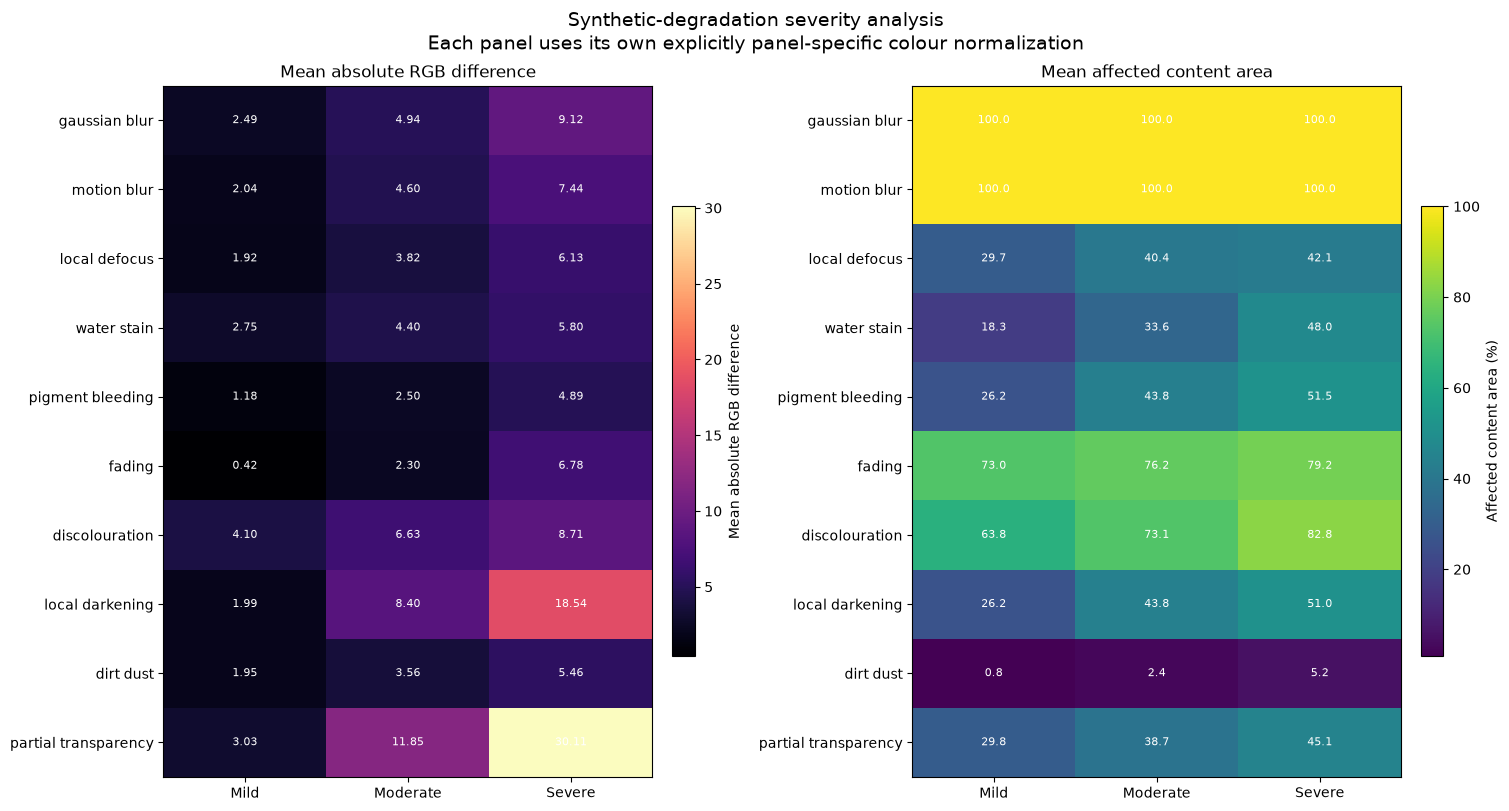

Severity monotonicity:


,degradation_family,severity_rows_present,mean_rgb_impact_monotonic,mean_colour_distance_monotonic,mean_affected_fraction_monotonic,mild_mean_rgb_difference,moderate_mean_rgb_difference,severe_mean_rgb_difference
0,gaussian_blur,True,True,True,True,2.492870,4.942024,9.124381
1,motion_blur,True,True,True,True,2.038810,4.600861,7.440814
2,local_defocus,True,True,True,True,1.915347,3.817910,6.130885
3,water_stain,True,True,True,True,2.749660,4.395224,5.795693
4,pigment_bleeding,True,True,True,True,1.179909,2.497294,4.890554
5,fading,True,True,True,True,0.415399,2.299902,6.779712
6,discolouration,True,True,True,True,4.097674,6.628068,8.705888
7,local_darkening,True,True,True,True,1.989752,8.403190,18.543415
8,dirt_dust,True,True,True,True,1.950303,3.555424,5.461429
9,partial_transparency,True,True,True,True,3.029407,11.846100,30.107328



Combined-degradation summary:


,degradation_family,severity,cases,paintings,mean_affected_content_fraction,mean_absolute_rgb_difference,mean_rgb_colour_distance,mean_gradient_energy_ratio,mean_laplacian_variance_ratio
30,fading_discolouration,moderate,5,5,0.823070,7.141821,13.422966,0.908010,0.837541
31,water_stain_dirt,moderate,5,5,0.403159,4.244324,8.308855,0.925484,0.850802
32,gaussian_blur_fading,moderate,5,5,1.000000,5.811031,10.954370,0.376693,0.074985


In [16]:
# ---------------------------------------------------------------------------
# Family and severity analysis
# ---------------------------------------------------------------------------

analysis_summary_df = (
    full_generation_cases_df
    .groupby(
        [
            "degradation_family",
            "severity",
            "severity_rank",
            "is_combined",
        ],
        as_index=False,
    )
    .agg(
        cases=(
            "case_id",
            "size",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        mean_affected_content_fraction=(
            "affected_content_fraction",
            "mean",
        ),
        mean_changed_content_fraction=(
            "changed_content_fraction",
            "mean",
        ),
        mean_absolute_rgb_difference=(
            "mean_absolute_rgb_difference",
            "mean",
        ),
        mean_rgb_colour_distance=(
            "mean_rgb_colour_distance",
            "mean",
        ),
        mean_luminance_shift=(
            "mean_luminance_shift",
            "mean",
        ),
        mean_saturation_shift=(
            "mean_saturation_shift",
            "mean",
        ),
        mean_gradient_energy_ratio=(
            "gradient_energy_ratio",
            "mean",
        ),
        mean_laplacian_variance_ratio=(
            "laplacian_variance_ratio",
            "mean",
        ),
    )
)

analysis_family_order = {
    family_id: index
    for index, family_id in enumerate(
        (
            *SUPPORTED_SINGLE_FAMILIES,
            *SUPPORTED_COMBINED_FAMILIES,
        )
    )
}

analysis_summary_df[
    "_family_order"
] = analysis_summary_df[
    "degradation_family"
].map(
    analysis_family_order
)

analysis_summary_df = (
    analysis_summary_df
    .sort_values(
        [
            "_family_order",
            "severity_rank",
        ]
    )
    .reset_index(
        drop=True
    )
)

single_severity_summary_df = (
    analysis_summary_df.loc[
        ~analysis_summary_df[
            "is_combined"
        ].astype(bool)
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Mean severity-progression validation
# ---------------------------------------------------------------------------

severity_monotonicity_records = []

for family_id in SUPPORTED_SINGLE_FAMILIES:
    family_summary = (
        single_severity_summary_df.loc[
            single_severity_summary_df[
                "degradation_family"
            ]
            == family_id
        ]
        .set_index(
            "severity"
        )
        .reindex(
            SUPPORTED_SEVERITIES
        )
    )

    impact_values = family_summary[
        "mean_absolute_rgb_difference"
    ].astype(float).to_numpy()

    colour_distance_values = family_summary[
        "mean_rgb_colour_distance"
    ].astype(float).to_numpy()

    affected_fraction_values = family_summary[
        "mean_affected_content_fraction"
    ].astype(float).to_numpy()

    severity_monotonicity_records.append(
        {
            "degradation_family": family_id,
            "severity_rows_present": bool(
                len(
                    family_summary
                )
                == 3
                and not family_summary[
                    "cases"
                ].isna().any()
            ),
            "mean_rgb_impact_monotonic": bool(
                np.all(
                    np.diff(
                        impact_values
                    )
                    > 0
                )
            ),
            "mean_colour_distance_monotonic": bool(
                np.all(
                    np.diff(
                        colour_distance_values
                    )
                    > 0
                )
            ),
            "mean_affected_fraction_monotonic": bool(
                np.all(
                    np.diff(
                        affected_fraction_values
                    )
                    >= 0
                )
            ),
            "mild_mean_rgb_difference": float(
                impact_values[0]
            ),
            "moderate_mean_rgb_difference": float(
                impact_values[1]
            ),
            "severe_mean_rgb_difference": float(
                impact_values[2]
            ),
        }
    )

severity_monotonicity_df = pd.DataFrame(
    severity_monotonicity_records
)


# ---------------------------------------------------------------------------
# Heatmap matrices
# ---------------------------------------------------------------------------

impact_heatmap_df = (
    single_severity_summary_df
    .pivot(
        index="degradation_family",
        columns="severity",
        values=(
            "mean_absolute_rgb_difference"
        ),
    )
    .reindex(
        index=SUPPORTED_SINGLE_FAMILIES,
        columns=SUPPORTED_SEVERITIES,
    )
)

affected_fraction_heatmap_df = (
    single_severity_summary_df
    .pivot(
        index="degradation_family",
        columns="severity",
        values=(
            "mean_affected_content_fraction"
        ),
    )
    .reindex(
        index=SUPPORTED_SINGLE_FAMILIES,
        columns=SUPPORTED_SEVERITIES,
    )
    * 100.0
)


# ---------------------------------------------------------------------------
# Render compact analysis heatmaps
# ---------------------------------------------------------------------------

analysis_figure, analysis_axes = (
    plt.subplots(
        1,
        2,
        figsize=(
            15,
            8,
        ),
        constrained_layout=True,
    )
)

heatmap_specs = [
    {
        "axis": analysis_axes[0],
        "values": (
            impact_heatmap_df
            .to_numpy(
                dtype=float
            )
        ),
        "title": (
            "Mean absolute RGB difference"
        ),
        "colourmap": "magma",
        "number_format": ".2f",
        "colourbar_label": (
            "Mean absolute RGB difference"
        ),
    },
    {
        "axis": analysis_axes[1],
        "values": (
            affected_fraction_heatmap_df
            .to_numpy(
                dtype=float
            )
        ),
        "title": (
            "Mean affected content area"
        ),
        "colourmap": "viridis",
        "number_format": ".1f",
        "colourbar_label": (
            "Affected content area (%)"
        ),
    },
]

for heatmap_spec in heatmap_specs:
    axis = heatmap_spec[
        "axis"
    ]

    values = heatmap_spec[
        "values"
    ]

    image = axis.imshow(
        values,
        aspect="auto",
        cmap=heatmap_spec[
            "colourmap"
        ],
    )

    axis.set_title(
        heatmap_spec[
            "title"
        ]
    )

    axis.set_xticks(
        range(
            len(
                SUPPORTED_SEVERITIES
            )
        ),
        labels=[
            severity.title()
            for severity
            in SUPPORTED_SEVERITIES
        ],
    )

    axis.set_yticks(
        range(
            len(
                SUPPORTED_SINGLE_FAMILIES
            )
        ),
        labels=[
            family_id.replace(
                "_",
                " ",
            )
            for family_id
            in SUPPORTED_SINGLE_FAMILIES
        ],
    )

    for row_index in range(
        values.shape[0]
    ):
        for column_index in range(
            values.shape[1]
        ):
            axis.text(
                column_index,
                row_index,
                format(
                    values[
                        row_index,
                        column_index,
                    ],
                    heatmap_spec[
                        "number_format"
                    ],
                ),
                ha="center",
                va="center",
                fontsize=8,
                color="white",
            )

    colourbar = (
        analysis_figure.colorbar(
            image,
            ax=axis,
            fraction=0.046,
            pad=0.04,
        )
    )

    colourbar.set_label(
        heatmap_spec[
            "colourbar_label"
        ]
    )

analysis_figure.suptitle(
    "Synthetic-degradation severity analysis\n"
    "Each panel uses its own explicitly "
    "panel-specific colour normalization",
    fontsize=14,
)

plt.show()


# ---------------------------------------------------------------------------
# Concise tables
# ---------------------------------------------------------------------------

print(
    "Severity monotonicity:"
)

display(
    severity_monotonicity_df
)

print(
    "\nCombined-degradation summary:"
)

display(
    analysis_summary_df.loc[
        analysis_summary_df[
            "is_combined"
        ].astype(bool),
        [
            "degradation_family",
            "severity",
            "cases",
            "paintings",
            "mean_affected_content_fraction",
            "mean_absolute_rgb_difference",
            "mean_rgb_colour_distance",
            "mean_gradient_energy_ratio",
            "mean_laplacian_variance_ratio",
        ],
    ]
)

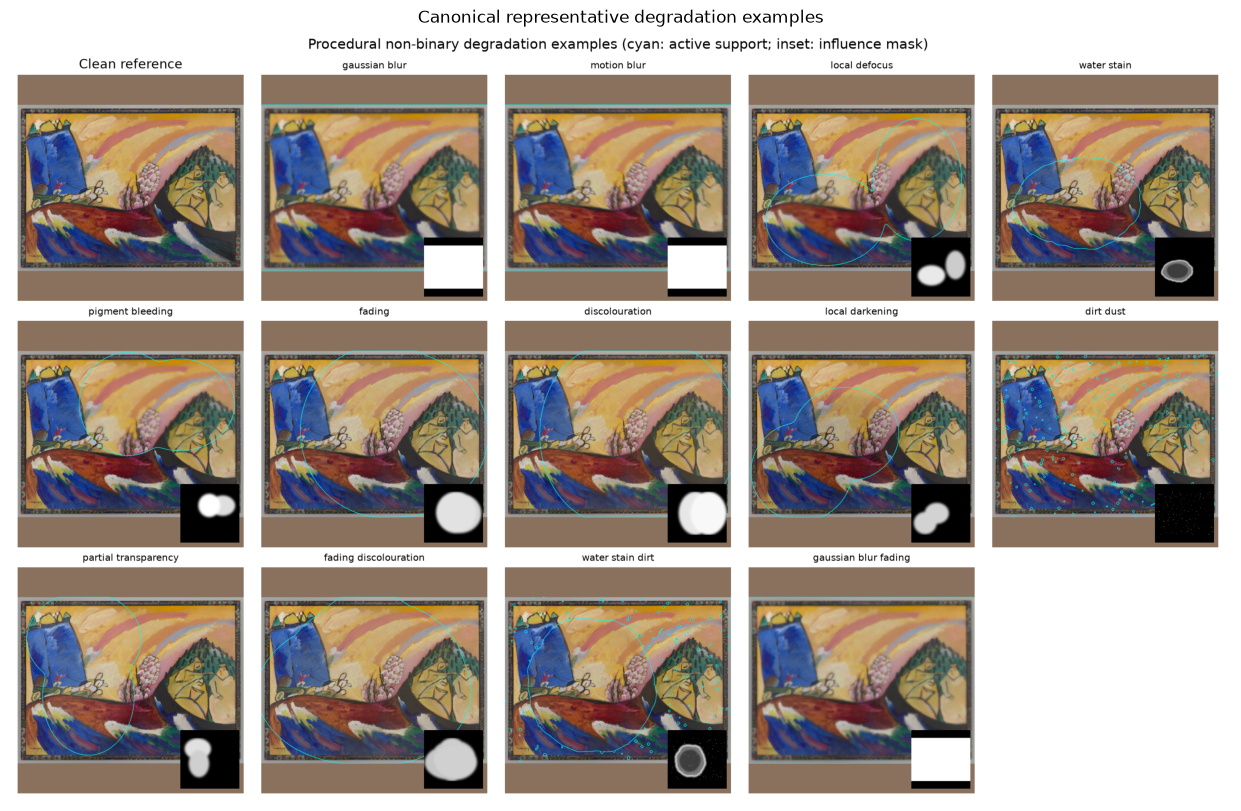

Example cases selected: 13
Example figure: outputs/07_synthetic_degradation_dataset_generation/figures/degradation_examples.png
Example figure format: PNG
Example figure mode: RGBA
Example figure dimensions: (2567, 1618)
Protocol: outputs/07_synthetic_degradation_dataset_generation/reports/degradation_protocol.md
Protocol characters: 22619
Missing required protocol phrases: []


In [17]:
# ---------------------------------------------------------------------------
# Deterministic representative selection
# ---------------------------------------------------------------------------

EXAMPLE_PAINTING_ID = str(
    synthetic_config[
        "examples"
    ][
        "painting_id"
    ]
)

EXAMPLE_SINGLE_SEVERITY = str(
    synthetic_config[
        "examples"
    ][
        "single_severity"
    ]
)

example_selection_df = (
    full_generation_cases_df.loc[
        (
            full_generation_cases_df[
                "painting_id"
            ].astype(str)
            == EXAMPLE_PAINTING_ID
        )
        & (
            full_generation_cases_df[
                "is_combined"
            ].astype(bool)
            | (
                full_generation_cases_df[
                    "severity"
                ].astype(str)
                == EXAMPLE_SINGLE_SEVERITY
            )
        )
    ]
    .copy()
)

example_selection_df[
    "_family_order"
] = example_selection_df[
    "degradation_family"
].map(
    analysis_family_order
)

example_selection_df = (
    example_selection_df
    .sort_values(
        "_family_order"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Persist the canonical example figure
# ---------------------------------------------------------------------------

DEGRADATION_EXAMPLES_PATH = (
    OUTPUT_PATHS[
        "synthetic_degradation_examples"
    ]
)

DEGRADATION_PROTOCOL_PATH = (
    OUTPUT_PATHS[
        "synthetic_degradation_protocol"
    ]
)

created_examples_path = (
    create_degradation_examples_figure(
        cases=full_generation_cases_df,
        config=synthetic_config,
        project_root=PROJECT_ROOT,
        output_path=(
            DEGRADATION_EXAMPLES_PATH
        ),
    )
)

with Image.open(
    created_examples_path
) as examples_handle:
    examples_figure_format = (
        examples_handle.format
    )

    examples_figure_mode = (
        examples_handle.mode
    )

    examples_figure_dimensions = (
        examples_handle.size
    )

    examples_preview = (
        examples_handle
        .convert(
            "RGB"
        )
        .copy()
    )

plt.figure(
    figsize=(
        16,
        10,
    )
)

plt.imshow(
    examples_preview
)

plt.title(
    "Canonical representative degradation examples"
)

plt.axis(
    "off"
)

plt.show()


# ---------------------------------------------------------------------------
# Operator protocol tables
# ---------------------------------------------------------------------------

configured_single_families = (
    family_configuration(
        synthetic_config
    )
)

configured_combined_families = (
    combined_configuration(
        synthetic_config
    )
)

operator_protocol_records = []

for family_id in SUPPORTED_SINGLE_FAMILIES:
    family_config = (
        configured_single_families[
            family_id
        ]
    )

    for severity in SUPPORTED_SEVERITIES:
        operator_protocol_records.append(
            {
                "family": family_id,
                "severity": severity,
                "operator": str(
                    family_config[
                        "operator"
                    ]
                ),
                "spatial_support": str(
                    family_config[
                        "spatial_support_type"
                    ]
                ),
                "parameters": json.dumps(
                    family_config[
                        "parameters"
                    ][
                        severity
                    ],
                    ensure_ascii=False,
                    sort_keys=True,
                ),
            }
        )

operator_protocol_df = pd.DataFrame(
    operator_protocol_records
)

combined_protocol_records = []

for family_id in SUPPORTED_COMBINED_FAMILIES:
    family_config = (
        configured_combined_families[
            family_id
        ]
    )

    combined_protocol_records.append(
        {
            "combined_family": family_id,
            "severity": str(
                family_config[
                    "severity"
                ]
            ),
            "ordered_components": (
                " -> ".join(
                    family_config[
                        "components"
                    ]
                )
            ),
        }
    )

combined_protocol_df = pd.DataFrame(
    combined_protocol_records
)


# ---------------------------------------------------------------------------
# Compact observed-impact table for the protocol
# ---------------------------------------------------------------------------

protocol_impact_summary_df = (
    analysis_summary_df[
        [
            "degradation_family",
            "severity",
            "is_combined",
            "cases",
            "paintings",
            "mean_affected_content_fraction",
            "mean_changed_content_fraction",
            "mean_absolute_rgb_difference",
            "mean_rgb_colour_distance",
            "mean_gradient_energy_ratio",
            "mean_laplacian_variance_ratio",
        ]
    ]
    .copy()
)

fraction_columns = [
    "mean_affected_content_fraction",
    "mean_changed_content_fraction",
]

protocol_impact_summary_df[
    fraction_columns
] = (
    protocol_impact_summary_df[
        fraction_columns
    ]
    * 100.0
)

protocol_impact_summary_df = (
    protocol_impact_summary_df.rename(
        columns={
            "mean_affected_content_fraction": (
                "mean_affected_content_percent"
            ),
            "mean_changed_content_fraction": (
                "mean_changed_content_percent"
            ),
        }
    )
)

protocol_numeric_columns = [
    column
    for column in (
        protocol_impact_summary_df
        .select_dtypes(
            include=[
                "number"
            ]
        )
        .columns
    )
    if column not in {
        "cases",
        "paintings",
    }
]

protocol_impact_summary_df[
    protocol_numeric_columns
] = (
    protocol_impact_summary_df[
        protocol_numeric_columns
    ].round(
        6
    )
)


# ---------------------------------------------------------------------------
# Write the canonical degradation protocol
# ---------------------------------------------------------------------------

cohort_protocol_df = (
    cohort_df[
        [
            "painting_id",
            "category",
            "processed_image_id",
            "processed_path",
        ]
    ]
    .copy()
)

protocol_text = f"""# Synthetic Degradation Protocol

## Status and scope

- Notebook: `{NOTEBOOK_STEM}`
- Dataset: `{synthetic_config["dataset"]["dataset_id"]}`
- Dataset version: `{synthetic_config["dataset"]["dataset_version"]}`
- Dataset scope: `{synthetic_config["dataset"]["dataset_scope"]}`
- Experiment: `{synthetic_config["dataset"]["experiment_id"]}`
- Configuration schema: `{synthetic_config["config_schema_version"]}`
- Configuration version: `{synthetic_config["config_version"]}`
- Generator: `{GENERATOR_VERSION}`
- Seed scheme: `{synthetic_config["generator"]["seed_scheme_version"]}`
- Global seed: `{synthetic_config["generator"]["global_seed"]}`
- Canonical cases: `{len(full_generation_cases_df)}`
- Effect-support masks: `{len(generated_effect_mask_paths)}`
- Degraded images: `{len(generated_degraded_paths)}`

This protocol defines a controlled non-binary procedural-degradation
branch for restoration-evaluation research.

## Interpretation boundary

The generated effects are controlled procedural evaluation proxies.
They are not exact simulations of conservation damage, material aging,
pigment chemistry, varnish behavior, moisture transport, substrate
exposure, or any specific historical deterioration process.

This branch is not missing-region damage. The effect-support masks must
not be interpreted as binary missing-pixel masks, physical damage
segmentations, conservation annotations, or material-loss ground truth.

Visual plausibility is not equivalent to historical correctness,
conservation approval, or restoration trustworthiness.

## Effect-support semantics

Every effect-support mask is an 8-bit grayscale `L` PNG.

- `0` means the operator has no configured spatial influence.
- Values from `1` through `255` encode increasing spatial influence.
- The support threshold is
  `{synthetic_config["generator"]["support_threshold"]}`.
- The active threshold is
  `{synthetic_config["generator"]["active_threshold"]}`.
- Combined masks use the pixelwise maximum/union of their component
  influence masks.
- Changed pixels are required to remain inside the recorded support.
- Support is required to remain inside the Notebook 02 content box.

The mask is an algorithmic operator-influence record. It is not a claim
about real physical damage boundaries.

## Balanced five-painting cohort

{cohort_protocol_df.to_markdown(index=False)}

## Case design

The canonical design contains:

- 10 single degradation families;
- 3 configured severity levels;
- 5 paintings;
- 150 single-degradation cases;
- 3 ordered combined degradations at the configured moderate level;
- 15 combined cases;
- 165 total cases.

Clean references remain canonical Notebook 02 inputs and are not copied,
overwritten, or modified by this notebook.

## Single-degradation operators and parameters

{operator_protocol_df.to_markdown(index=False)}

## Ordered combined degradations

{combined_protocol_df.to_markdown(index=False)}

Component order is part of the experimental definition. Reversing the
order would define a different transformation and is not treated as an
equivalent case.

## Determinism and provenance

Each case records:

- the global generator seed;
- a stable case seed;
- a stable effect-mask seed;
- an operator seed for every component;
- the complete operator-parameter mapping;
- the generator and configuration versions;
- the clean, effect-mask, and degraded-image SHA-256 checksums;
- content geometry inherited from Notebook 02.

Identical configuration, input checksums, helper version, and seed
scheme are expected to reproduce identical pixels and metadata.

## Recorded impact evidence

Affected area, changed pixels, RGB difference, colour distance,
luminance shift, saturation shift, gradient-energy ratio, and
Laplacian-variance ratio are descriptive generation proxies. They do
not measure conservation severity or historical fidelity.

{protocol_impact_summary_df.to_markdown(index=False)}

## Validation

All `{len(generation_audit_df)}` canonical cases were independently
reloaded. The final reload audit found:

- `{int(generation_audit_df["output_contract_valid"].sum())}` valid
  output contracts;
- `{int(generation_audit_df["outside_support_changed_pixels"].sum())}`
  changed pixels outside recorded support;
- `{len(missing_declared_paths)}` missing declared paths;
- `{len(stale_generated_paths)}` stale paths;
- `{len(orphan_generated_paths)}` orphan paths;
- `{audit_boolean_failure_count}` failed boolean contract fields.

## Physical and methodological limitations

1. RGB-domain operators do not model spectral reflectance, pigment
   composition, varnish layers, substrate mechanics, craquelure
   propagation, chemical reactions, humidity transport, or aging time.
2. Severity levels are configured ordinal experimental levels. They are
   not calibrated conservation-condition grades.
3. Affected-area fraction does not equal physical damage severity.
4. Influence masks encode algorithmic blending support and are not
   expert damage annotations.
5. The five-painting cohort improves controlled visual diversity but
   does not represent the full distribution of artists, periods,
   materials, techniques, or conservation conditions.
6. Combined degradations are selected ordered compositions and do not
   enumerate all real-world interactions.
7. Pixel, colour, gradient, and Laplacian statistics are descriptive
   proxies rather than evidence of historical authenticity.
8. These generated cases may expose algorithmic behavior but cannot
   certify conservation readiness.
9. Restoration-model eligibility and evaluation-region policy are
   explicitly deferred to Notebook 08.
10. Human conservation review remains necessary for any real-world
    interpretation.

## Downstream use

The normalized case manifest is prepared for Notebook 08, which decides
model eligibility and region policy. Downstream notebooks must retain
the non-binary effect-support semantics and the interpretation
boundaries stated above.
"""

DEGRADATION_PROTOCOL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

protocol_temporary_path = (
    DEGRADATION_PROTOCOL_PATH
    .with_suffix(
        ".md.tmp"
    )
)

protocol_temporary_path.write_text(
    protocol_text,
    encoding="utf-8",
)

protocol_temporary_path.replace(
    DEGRADATION_PROTOCOL_PATH
)

protocol_required_phrases = [
    "not exact simulations of conservation damage",
    "not missing-region damage",
    "effect-support masks",
    "Visual plausibility is not equivalent",
    "Notebook 08",
    "Human conservation review",
]

missing_protocol_phrases = [
    phrase
    for phrase in protocol_required_phrases
    if phrase.lower()
    not in protocol_text.lower()
]


# ---------------------------------------------------------------------------
# Artifact inspection
# ---------------------------------------------------------------------------

examples_figure_sha256 = sha256_file(
    DEGRADATION_EXAMPLES_PATH
)

protocol_sha256 = sha256_file(
    DEGRADATION_PROTOCOL_PATH
)

print(
    "Example cases selected:",
    len(
        example_selection_df
    ),
)

print(
    "Example figure:",
    to_repo_relative(
        DEGRADATION_EXAMPLES_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Example figure format:",
    examples_figure_format,
)

print(
    "Example figure mode:",
    examples_figure_mode,
)

print(
    "Example figure dimensions:",
    examples_figure_dimensions,
)

print(
    "Protocol:",
    to_repo_relative(
        DEGRADATION_PROTOCOL_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Protocol characters:",
    len(
        protocol_text
    ),
)

print(
    "Missing required protocol phrases:",
    missing_protocol_phrases,
)

In [20]:
BATCH_6_STAGE = (
    "batch_6_analysis_visualization_protocol"
)


def add_batch_6_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return VALIDATION.add(
        validation_stage=BATCH_6_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# 1. Complete analysis coverage

analysis_numeric_columns = [
    "mean_affected_content_fraction",
    "mean_changed_content_fraction",
    "mean_absolute_rgb_difference",
    "mean_rgb_colour_distance",
    "mean_luminance_shift",
    "mean_saturation_shift",
    "mean_gradient_energy_ratio",
    "mean_laplacian_variance_ratio",
]

add_batch_6_check(
    check_id="analysis_coverage",
    description=(
        "Analysis covers all ten single families "
        "at three severities and all three combined "
        "families across five paintings."
    ),
    expected={
        "summary_rows": 33,
        "single_families": 10,
        "combined_families": 3,
        "paintings_per_row": 5,
        "nonfinite_values": 0,
    },
    observed={
        "summary_rows": len(
            analysis_summary_df
        ),
        "single_families": int(
            single_severity_summary_df[
                "degradation_family"
            ].nunique()
        ),
        "combined_families": int(
            analysis_summary_df.loc[
                analysis_summary_df[
                    "is_combined"
                ].astype(bool),
                "degradation_family",
            ].nunique()
        ),
        "minimum_paintings_per_row": int(
            analysis_summary_df[
                "paintings"
            ].min()
        ),
        "nonfinite_values": int(
            (
                ~np.isfinite(
                    analysis_summary_df[
                        analysis_numeric_columns
                    ].astype(float)
                )
            ).sum().sum()
        ),
    },
    passed=(
        len(
            analysis_summary_df
        )
        == 33
        and single_severity_summary_df[
            "degradation_family"
        ].nunique()
        == 10
        and analysis_summary_df.loc[
            analysis_summary_df[
                "is_combined"
            ].astype(bool),
            "degradation_family",
        ].nunique()
        == 3
        and (
            analysis_summary_df[
                "paintings"
            ].astype(int)
            == 5
        ).all()
        and np.isfinite(
            analysis_summary_df[
                analysis_numeric_columns
            ].astype(float)
        ).all().all()
    ),
)


# 2. Severity progression

severity_progression_columns = [
    "severity_rows_present",
    "mean_rgb_impact_monotonic",
    "mean_colour_distance_monotonic",
    "mean_affected_fraction_monotonic",
]

add_batch_6_check(
    check_id="severity_progression",
    description=(
        "Every single degradation family has a "
        "complete mild, moderate, and severe sequence "
        "with monotonically increasing mean impact "
        "and non-decreasing affected area."
    ),
    expected={
        "families": 10,
        "failed_fields": 0,
    },
    observed={
        "families": len(
            severity_monotonicity_df
        ),
        "failed_fields": int(
            (
                ~severity_monotonicity_df[
                    severity_progression_columns
                ].astype(bool)
            ).sum().sum()
        ),
    },
    passed=(
        len(
            severity_monotonicity_df
        )
        == 10
        and severity_monotonicity_df[
            severity_progression_columns
        ].astype(bool).all().all()
    ),
    details=(
        severity_monotonicity_df.loc[
            ~severity_monotonicity_df[
                severity_progression_columns
            ].all(
                axis=1
            )
        ]
        .to_dict(
            "records"
        )
    ),
)


# 3. Deterministic example selection

add_batch_6_check(
    check_id="representative_selection",
    description=(
        "The configured representative selection "
        "contains one clean reference context, ten "
        "moderate single cases, and three combined "
        "cases for p039."
    ),
    expected={
        "painting_id": "p039",
        "selected_cases": 13,
        "single_cases": 10,
        "combined_cases": 3,
        "unique_families": 13,
    },
    observed={
        "painting_ids": sorted(
            example_selection_df[
                "painting_id"
            ].astype(str).unique().tolist()
        ),
        "selected_cases": len(
            example_selection_df
        ),
        "single_cases": int(
            (
                ~example_selection_df[
                    "is_combined"
                ].astype(bool)
            ).sum()
        ),
        "combined_cases": int(
            example_selection_df[
                "is_combined"
            ].astype(bool).sum()
        ),
        "unique_families": int(
            example_selection_df[
                "degradation_family"
            ].nunique()
        ),
    },
    passed=(
        set(
            example_selection_df[
                "painting_id"
            ].astype(str)
        )
        == {EXAMPLE_PAINTING_ID}
        and len(
            example_selection_df
        )
        == 13
        and int(
            (
                ~example_selection_df[
                    "is_combined"
                ].astype(bool)
            ).sum()
        )
        == 10
        and int(
            example_selection_df[
                "is_combined"
            ].astype(bool).sum()
        )
        == 3
        and example_selection_df[
            "degradation_family"
        ].nunique()
        == 13
    ),
)


# 4. Canonical figure artifact

add_batch_6_check(
    check_id="degradation_examples_figure",
    description=(
        "The canonical representative figure exists, "
        "reloads as a non-empty PNG, and is contained "
        "inside the exact Notebook 07 output root."
    ),
    expected={
        "exists": True,
        "format": "PNG",
        "nonempty": True,
        "inside_output_root": True,
    },
    observed={
        "exists": (
            DEGRADATION_EXAMPLES_PATH.is_file()
        ),
        "format": examples_figure_format,
        "mode": examples_figure_mode,
        "dimensions": (
            examples_figure_dimensions
        ),
        "size_bytes": int(
            DEGRADATION_EXAMPLES_PATH
            .stat()
            .st_size
        ),
        "inside_output_root": (
            DEGRADATION_EXAMPLES_PATH
            .resolve()
            .is_relative_to(
                OUTPUT_ROOT.resolve()
            )
        ),
    },
    passed=(
        DEGRADATION_EXAMPLES_PATH.is_file()
        and DEGRADATION_EXAMPLES_PATH
        .stat()
        .st_size
        > 0
        and examples_figure_format
        == "PNG"
        and examples_figure_dimensions[
            0
        ]
        > 0
        and examples_figure_dimensions[
            1
        ]
        > 0
        and DEGRADATION_EXAMPLES_PATH
        .resolve()
        .is_relative_to(
            OUTPUT_ROOT.resolve()
        )
    ),
)


# 5. Canonical protocol artifact

add_batch_6_check(
    check_id="degradation_protocol",
    description=(
        "The canonical protocol exists, is non-empty, "
        "and records effect-support semantics, "
        "physical limitations, interpretation "
        "boundaries, and the Notebook 08 handoff."
    ),
    expected={
        "exists": True,
        "missing_required_phrases": 0,
        "inside_output_root": True,
    },
    observed={
        "exists": (
            DEGRADATION_PROTOCOL_PATH.is_file()
        ),
        "characters": len(
            protocol_text
        ),
        "missing_required_phrases": len(
            missing_protocol_phrases
        ),
        "inside_output_root": (
            DEGRADATION_PROTOCOL_PATH
            .resolve()
            .is_relative_to(
                OUTPUT_ROOT.resolve()
            )
        ),
    },
    passed=(
        DEGRADATION_PROTOCOL_PATH.is_file()
        and DEGRADATION_PROTOCOL_PATH
        .stat()
        .st_size
        > 0
        and len(
            protocol_text
        )
        > 1000
        and not missing_protocol_phrases
        and DEGRADATION_PROTOCOL_PATH
        .resolve()
        .is_relative_to(
            OUTPUT_ROOT.resolve()
        )
    ),
    details={
        "missing_phrases": (
            missing_protocol_phrases
        ),
    },
)


# 6. Batch 6 filesystem state

batch_6_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
)

batch_6_png_files = [
    path
    for path in batch_6_output_files
    if path.suffix.lower()
    == ".png"
]

batch_6_markdown_files = [
    path
    for path in batch_6_output_files
    if path.suffix.lower()
    == ".md"
]

batch_6_unexpected_files = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in batch_6_output_files
    if path.suffix.lower()
    not in {
        ".png",
        ".md",
    }
]

add_batch_6_check(
    check_id="batch_6_filesystem_state",
    description=(
        "After Batch 6 the output root contains only "
        "the 330 generated case images, one canonical "
        "example PNG, and one protocol Markdown file."
    ),
    expected={
        "total_files": 332,
        "png_files": 331,
        "markdown_files": 1,
        "unexpected_files": 0,
    },
    observed={
        "total_files": len(
            batch_6_output_files
        ),
        "png_files": len(
            batch_6_png_files
        ),
        "markdown_files": len(
            batch_6_markdown_files
        ),
        "unexpected_files": len(
            batch_6_unexpected_files
        ),
    },
    passed=(
        len(
            batch_6_output_files
        )
        == 332
        and len(
            batch_6_png_files
        )
        == 331
        and len(
            batch_6_markdown_files
        )
        == 1
        and not batch_6_unexpected_files
    ),
    details={
        "unexpected_files": (
            batch_6_unexpected_files
        ),
    },
)


# ---------------------------------------------------------------------------
# Batch 6 result
# ---------------------------------------------------------------------------

batch_6_validation_df = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: (
            frame[
                "validation_stage"
            ]
            == BATCH_6_STAGE
        )
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 6 validation checks:"
)

display(
    batch_6_validation_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

VALIDATION.raise_for_blocking()

print(
    "\nBatch 6 completed successfully."
)

print(
    "Batch 6 checks:",
    len(
        batch_6_validation_df
    ),
)

print(
    "Batch 6 passed:",
    int(
        batch_6_validation_df[
            "passed"
        ].sum()
    ),
)

print(
    "Cumulative checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Notebook 07 files after Batch 6:",
    len(
        batch_6_output_files
    ),
)

print(
    "Next approved stage: "
    "Batch 7 - canonical table persistence, "
    "run manifest, artifact manifest, and "
    "consolidated validation handoff."
)

Batch 6 validation checks:


,check_id,severity,expected,observed,passed
0,analysis_coverage,blocking,"{""combined_families"": 3, ""nonfinite_values"": 0...","{""combined_families"": 3, ""minimum_paintings_pe...",True
1,severity_progression,blocking,"{""failed_fields"": 0, ""families"": 10}","{""failed_fields"": 0, ""families"": 10}",True
2,representative_selection,blocking,"{""combined_cases"": 3, ""painting_id"": ""p039"", ""...","{""combined_cases"": 3, ""painting_ids"": [""p039""]...",True
3,degradation_examples_figure,blocking,"{""exists"": true, ""format"": ""PNG"", ""inside_outp...","{""dimensions"": [2567, 1618], ""exists"": true, ""...",True
4,degradation_protocol,blocking,"{""exists"": true, ""inside_output_root"": true, ""...","{""characters"": 22619, ""exists"": true, ""inside_...",True
5,batch_6_filesystem_state,blocking,"{""markdown_files"": 1, ""png_files"": 331, ""total...","{""markdown_files"": 1, ""png_files"": 331, ""total...",True



Batch 6 completed successfully.
Batch 6 checks: 6
Batch 6 passed: 6
Cumulative checks: 66
Notebook 07 files after Batch 6: 332
Next approved stage: Batch 7 - canonical table persistence, run manifest, artifact manifest, and consolidated validation handoff.


## Batch 7 - Canonical Persistence and Provisional Handoff

This batch persists the validated Notebook 07 handoff:

- `data/cases.csv`;
- `metrics/generation_audit.csv`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- provisional `manifests/run_manifest.json`.

It independently reloads the three CSV files, validates their schemas and stable identities, rechecks both 165-image collections, reloads the canonical figure and protocol, builds the seven-record normalized artifact manifest, and verifies the exact 337-file output contract.

The 66 consolidated scientific checks remain separate from Batch 7 persistence and manifest-handoff checks.

The run manifest remains in a `running` state until Batch 8 performs the final completion audit, updates the project-path registry, and rewrites the run manifest as completed.

In [21]:
from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


EXPECTED_CONSOLIDATED_VALIDATION_ROWS = 66
EXPECTED_ARTIFACT_RECORD_COUNT = 7
EXPECTED_TOTAL_OUTPUT_FILE_COUNT = 337


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The consolidated Notebook 07 validation "
        "gate has not passed."
    )

validation_checks_df = (
    VALIDATION.to_dataframe()
)

if len(
    validation_checks_df
) != EXPECTED_CONSOLIDATED_VALIDATION_ROWS:
    raise RuntimeError(
        "Exactly "
        f"{EXPECTED_CONSOLIDATED_VALIDATION_ROWS} "
        "consolidated validation rows are required; "
        f"found {len(validation_checks_df)}."
    )

if len(
    full_generation_cases_df
) != EXPECTED_GENERATION_CASE_COUNT:
    raise RuntimeError(
        "The canonical case table does not contain "
        "the expected 165 rows."
    )

if len(
    generation_audit_df
) != EXPECTED_GENERATION_CASE_COUNT:
    raise RuntimeError(
        "The generation audit does not contain "
        "the expected 165 rows."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in (
    OUTPUT_PATHS.items()
):
    try:
        validated_output_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if (
            validated_output_path
            != output_path.resolve()
        ):
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(
                        output_path
                    ),
                    "issue": (
                        "resolved_path_mismatch"
                    ),
                }
            )

    except Exception as error:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(
                    output_path
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate "
        "Notebook 07 ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Atomic canonical CSV persistence
# ---------------------------------------------------------------------------

canonical_table_specs = [
    (
        full_generation_cases_df,
        OUTPUT_PATHS[
            "synthetic_degradation_cases"
        ],
    ),
    (
        generation_audit_df,
        OUTPUT_PATHS[
            "synthetic_degradation_generation_audit"
        ],
    ),
    (
        validation_checks_df,
        OUTPUT_PATHS[
            "validation_checks"
        ],
    ),
]

for dataframe, output_path in (
    canonical_table_specs
):
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = (
        output_path.with_suffix(
            output_path.suffix
            + ".tmp"
        )
    )

    try:
        dataframe.to_csv(
            temporary_path,
            index=False,
        )

        temporary_path.replace(
            output_path
        )

    finally:
        temporary_path.unlink(
            missing_ok=True
        )


# ---------------------------------------------------------------------------
# Independent CSV reload
# ---------------------------------------------------------------------------

cases_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "synthetic_degradation_cases"
    ],
    low_memory=False,
)

generation_audit_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "synthetic_degradation_generation_audit"
    ],
    low_memory=False,
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)

cases_reload_schema_result = (
    validate_dataframe(
        cases_reloaded_df,
        SYNTHETIC_DEGRADATION_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

audit_reload_schema_result = (
    validate_dataframe(
        generation_audit_reloaded_df,
        SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_reload_schema_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Stable identity evidence
# ---------------------------------------------------------------------------

expected_case_ids = set(
    full_generation_cases_df[
        "case_id"
    ].astype(str)
)

reloaded_case_ids = set(
    cases_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_audit_case_ids = set(
    generation_audit_df[
        "case_id"
    ].astype(str)
)

reloaded_audit_case_ids = set(
    generation_audit_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_effect_mask_relative_paths = set(
    full_generation_cases_df[
        "effect_mask_path"
    ].astype(str)
)

reloaded_effect_mask_table_paths = set(
    cases_reloaded_df[
        "effect_mask_path"
    ].astype(str)
)

expected_degraded_relative_paths = set(
    full_generation_cases_df[
        "degraded_image_path"
    ].astype(str)
)

reloaded_degraded_table_paths = set(
    cases_reloaded_df[
        "degraded_image_path"
    ].astype(str)
)

expected_validation_keys = {
    (
        str(
            check.validation_stage
        ),
        str(
            check.check_id
        ),
    )
    for check in VALIDATION.checks
}

reloaded_validation_keys = {
    (
        str(
            row.validation_stage
        ),
        str(
            row.check_id
        ),
    )
    for row in (
        validation_checks_reloaded_df
        .itertuples(
            index=False
        )
    )
}

all_reloaded_validation_checks_passed = bool(
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq(
        "true"
    )
    .all()
)


# ---------------------------------------------------------------------------
# Recheck both image collections and their checksums
# ---------------------------------------------------------------------------

reloaded_effect_mask_files = sorted(
    path
    for path in (
        EFFECT_MASK_OUTPUT_DIRECTORY
        .rglob(
            "*.png"
        )
    )
    if path.is_file()
)

reloaded_degraded_files = sorted(
    path
    for path in (
        DEGRADED_OUTPUT_DIRECTORY
        .rglob(
            "*.png"
        )
    )
    if path.is_file()
)

reloaded_effect_mask_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in reloaded_effect_mask_files
}

reloaded_degraded_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in reloaded_degraded_files
}

effect_mask_checksum_failures = []
degraded_checksum_failures = []

for case_row in cases_reloaded_df.itertuples(
    index=False
):
    effect_mask_path = resolve_repo_path(
        str(
            case_row.effect_mask_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    degraded_path = resolve_repo_path(
        str(
            case_row.degraded_image_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_effect_mask_checksum = (
        sha256_file(
            effect_mask_path
        )
    )

    observed_degraded_checksum = (
        sha256_file(
            degraded_path
        )
    )

    if (
        observed_effect_mask_checksum
        != str(
            case_row.effect_mask_sha256
        )
    ):
        effect_mask_checksum_failures.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "relative_path": (
                    case_row.effect_mask_path
                ),
                "expected_checksum": (
                    case_row.effect_mask_sha256
                ),
                "observed_checksum": (
                    observed_effect_mask_checksum
                ),
            }
        )

    if (
        observed_degraded_checksum
        != str(
            case_row.degraded_image_sha256
        )
    ):
        degraded_checksum_failures.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "relative_path": (
                    case_row.degraded_image_path
                ),
                "expected_checksum": (
                    case_row.degraded_image_sha256
                ),
                "observed_checksum": (
                    observed_degraded_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Reload the canonical figure and protocol
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "synthetic_degradation_examples"
    ]
) as figure_file:
    figure_file.load()

    persisted_figure_evidence = {
        "format": str(
            figure_file.format
        ),
        "mode": str(
            figure_file.mode
        ),
        "width": int(
            figure_file.width
        ),
        "height": int(
            figure_file.height
        ),
        "size_bytes": int(
            OUTPUT_PATHS[
                "synthetic_degradation_examples"
            ].stat().st_size
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "synthetic_degradation_examples"
            ]
        ),
    }

persisted_protocol_text = (
    OUTPUT_PATHS[
        "synthetic_degradation_protocol"
    ]
    .read_text(
        encoding="utf-8"
    )
)

persisted_protocol_evidence = {
    "size_bytes": int(
        OUTPUT_PATHS[
            "synthetic_degradation_protocol"
        ].stat().st_size
    ),
    "character_count": len(
        persisted_protocol_text
    ),
    "sha256": sha256_file(
        OUTPUT_PATHS[
            "synthetic_degradation_protocol"
        ]
    ),
    "matches_batch_6_text": (
        persisted_protocol_text
        == protocol_text
    ),
    "missing_required_phrases": [
        phrase
        for phrase
        in protocol_required_phrases
        if phrase.lower()
        not in persisted_protocol_text.lower()
    ],
}


# ---------------------------------------------------------------------------
# Separate canonical-persistence validation gate
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = (
    ValidationCollector()
)


def add_persistence_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# 1. Output ownership

add_persistence_check(
    check_id="output_path_ownership",
    description=(
        "Every declared output remains inside "
        "the exact Notebook 07 output root."
    ),
    expected=[],
    observed=(
        output_ownership_failures
    ),
    passed=not (
        output_ownership_failures
    ),
)


# 2. Cases CSV

cases_reload_passed = (
    cases_reload_schema_result.passed
    and not (
        cases_reload_schema_result
        .unexpected_columns
    )
    and len(
        cases_reloaded_df
    )
    == EXPECTED_GENERATION_CASE_COUNT
    and reloaded_case_ids
    == expected_case_ids
    and reloaded_effect_mask_table_paths
    == expected_effect_mask_relative_paths
    and reloaded_degraded_table_paths
    == expected_degraded_relative_paths
)

add_persistence_check(
    check_id="synthetic_degradation_cases_csv_reload",
    description=(
        "Persisted cases.csv reloads under "
        "synthetic_degradation_cases.v1 with every "
        "expected case and image path."
    ),
    expected={
        "rows": (
            EXPECTED_GENERATION_CASE_COUNT
        ),
        "schema_passed": True,
        "case_ids_match": True,
        "effect_mask_paths_match": True,
        "degraded_paths_match": True,
    },
    observed={
        "rows": len(
            cases_reloaded_df
        ),
        "schema": (
            cases_reload_schema_result
            .to_dict()
        ),
        "case_ids_match": (
            reloaded_case_ids
            == expected_case_ids
        ),
        "effect_mask_paths_match": (
            reloaded_effect_mask_table_paths
            == expected_effect_mask_relative_paths
        ),
        "degraded_paths_match": (
            reloaded_degraded_table_paths
            == expected_degraded_relative_paths
        ),
    },
    passed=cases_reload_passed,
)


# 3. Generation-audit CSV

audit_reload_passed = (
    audit_reload_schema_result.passed
    and not (
        audit_reload_schema_result
        .unexpected_columns
    )
    and len(
        generation_audit_reloaded_df
    )
    == EXPECTED_GENERATION_CASE_COUNT
    and reloaded_audit_case_ids
    == expected_audit_case_ids
    and generation_audit_reloaded_df[
        "validation_status"
    ].eq(
        "passed"
    ).all()
)

add_persistence_check(
    check_id="generation_audit_csv_reload",
    description=(
        "Persisted generation_audit.csv reloads "
        "under its exact schema with every expected "
        "passing case."
    ),
    expected={
        "rows": (
            EXPECTED_GENERATION_CASE_COUNT
        ),
        "schema_passed": True,
        "case_ids_match": True,
        "failed_cases": 0,
    },
    observed={
        "rows": len(
            generation_audit_reloaded_df
        ),
        "schema": (
            audit_reload_schema_result
            .to_dict()
        ),
        "case_ids_match": (
            reloaded_audit_case_ids
            == expected_audit_case_ids
        ),
        "failed_cases": int(
            generation_audit_reloaded_df[
                "validation_status"
            ].ne(
                "passed"
            ).sum()
        ),
    },
    passed=audit_reload_passed,
)


# 4. Consolidated validation CSV

validation_csv_reload_passed = (
    validation_reload_schema_result.passed
    and not (
        validation_reload_schema_result
        .unexpected_columns
    )
    and len(
        validation_checks_reloaded_df
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and reloaded_validation_keys
    == expected_validation_keys
    and all_reloaded_validation_checks_passed
)

add_persistence_check(
    check_id="validation_checks_csv_reload",
    description=(
        "Persisted checks.csv reloads under "
        "validation_checks.v1 with all 66 unique "
        "passing consolidated checks."
    ),
    expected={
        "rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "schema": (
            validation_reload_schema_result
            .to_dict()
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": (
            all_reloaded_validation_checks_passed
        ),
    },
    passed=validation_csv_reload_passed,
)


# 5. Effect-mask collection

effect_mask_collection_passed = (
    len(
        reloaded_effect_mask_files
    )
    == EXPECTED_GENERATION_CASE_COUNT
    and reloaded_effect_mask_relative_paths
    == expected_effect_mask_relative_paths
    and not effect_mask_checksum_failures
)

add_persistence_check(
    check_id="effect_mask_collection_reload",
    description=(
        "The effect-mask collection contains exactly "
        "165 declared PNGs and every mask matches its "
        "recorded checksum."
    ),
    expected={
        "file_count": 165,
        "paths_match": True,
        "checksum_failures": 0,
    },
    observed={
        "file_count": len(
            reloaded_effect_mask_files
        ),
        "paths_match": (
            reloaded_effect_mask_relative_paths
            == expected_effect_mask_relative_paths
        ),
        "checksum_failures": len(
            effect_mask_checksum_failures
        ),
    },
    passed=effect_mask_collection_passed,
    details=effect_mask_checksum_failures,
)


# 6. Degraded-image collection

degraded_collection_passed = (
    len(
        reloaded_degraded_files
    )
    == EXPECTED_GENERATION_CASE_COUNT
    and reloaded_degraded_relative_paths
    == expected_degraded_relative_paths
    and not degraded_checksum_failures
)

add_persistence_check(
    check_id="degraded_image_collection_reload",
    description=(
        "The degraded-image collection contains "
        "exactly 165 declared PNGs and every image "
        "matches its recorded checksum."
    ),
    expected={
        "file_count": 165,
        "paths_match": True,
        "checksum_failures": 0,
    },
    observed={
        "file_count": len(
            reloaded_degraded_files
        ),
        "paths_match": (
            reloaded_degraded_relative_paths
            == expected_degraded_relative_paths
        ),
        "checksum_failures": len(
            degraded_checksum_failures
        ),
    },
    passed=degraded_collection_passed,
    details=degraded_checksum_failures,
)


# 7. Canonical figure

figure_reload_passed = (
    persisted_figure_evidence[
        "format"
    ]
    == "PNG"
    and persisted_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and persisted_figure_evidence[
        "width"
    ]
    == examples_figure_dimensions[
        0
    ]
    and persisted_figure_evidence[
        "height"
    ]
    == examples_figure_dimensions[
        1
    ]
    and persisted_figure_evidence[
        "sha256"
    ]
    == examples_figure_sha256
)

add_persistence_check(
    check_id="degradation_examples_figure_reload",
    description=(
        "The canonical representative figure reloads "
        "as a full-resolution PNG and retains its "
        "Batch 6 checksum."
    ),
    expected={
        "format": "PNG",
        "allowed_modes": [
            "RGB",
            "RGBA",
        ],
        "dimensions": list(
            examples_figure_dimensions
        ),
        "sha256": (
            examples_figure_sha256
        ),
    },
    observed=(
        persisted_figure_evidence
    ),
    passed=figure_reload_passed,
)


# 8. Canonical protocol

protocol_reload_passed = (
    persisted_protocol_evidence[
        "size_bytes"
    ]
    > 0
    and persisted_protocol_evidence[
        "character_count"
    ]
    > 1000
    and persisted_protocol_evidence[
        "sha256"
    ]
    == protocol_sha256
    and persisted_protocol_evidence[
        "matches_batch_6_text"
    ]
    and not persisted_protocol_evidence[
        "missing_required_phrases"
    ]
)

add_persistence_check(
    check_id="degradation_protocol_reload",
    description=(
        "The degradation protocol reloads unchanged "
        "and retains all required interpretation and "
        "physical-limitation language."
    ),
    expected={
        "nonempty": True,
        "matches_batch_6_text": True,
        "missing_required_phrases": 0,
        "sha256": protocol_sha256,
    },
    observed=(
        persisted_protocol_evidence
    ),
    passed=protocol_reload_passed,
)


persistence_checks_df = (
    PERSISTENCE_VALIDATION
    .to_dataframe()
)

if len(
    persistence_checks_df
) != 8:
    raise RuntimeError(
        "Batch 7 must produce exactly eight "
        "canonical-persistence checks."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()

print(
    "Canonical persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Persisted cases:",
    cases_reloaded_df.shape,
)

print(
    "Persisted generation audit:",
    generation_audit_reloaded_df.shape,
)

print(
    "Persisted consolidated checks:",
    validation_checks_reloaded_df.shape,
)

Canonical persistence validation passed: True


,check_id,severity,passed
0,output_path_ownership,blocking,True
1,synthetic_degradation_cases_csv_reload,blocking,True
2,generation_audit_csv_reload,blocking,True
3,validation_checks_csv_reload,blocking,True
4,effect_mask_collection_reload,blocking,True
5,degraded_image_collection_reload,blocking,True
6,degradation_examples_figure_reload,blocking,True
7,degradation_protocol_reload,blocking,True


Persisted cases: (165, 65)
Persisted generation audit: (165, 34)
Persisted consolidated checks: (66, 8)


In [22]:
# ---------------------------------------------------------------------------
# Normalized output metadata
# ---------------------------------------------------------------------------

dataset_scope = str(
    synthetic_config[
        "dataset"
    ][
        "dataset_scope"
    ]
)

experiment_id = str(
    synthetic_config[
        "dataset"
    ][
        "experiment_id"
    ]
)

output_metadata = {
    "synthetic_degradation_cases": {
        "artifact_type": "dataset_table",
        "artifact_role": "primary_case_manifest",
        "schema_version": (
            SYNTHETIC_DEGRADATION_CASES_SCHEMA
            .version
        ),
    },
    "synthetic_degradation_effect_masks": {
        "artifact_type": "image_collection",
        "artifact_role": "effect_support_collection",
        "schema_version": (
            "synthetic_effect_mask_collection.v1"
        ),
    },
    "synthetic_degradation_images": {
        "artifact_type": "image_collection",
        "artifact_role": "degraded_image_collection",
        "schema_version": (
            "synthetic_degraded_image_collection.v1"
        ),
    },
    "synthetic_degradation_generation_audit": {
        "artifact_type": "audit_table",
        "artifact_role": "generation_audit",
        "schema_version": (
            SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA
            .version
        ),
    },
    "synthetic_degradation_examples": {
        "artifact_type": "figure",
        "artifact_role": "representative_visual_evidence",
        "schema_version": (
            "figure.synthetic_degradation_examples.v1"
        ),
    },
    "synthetic_degradation_protocol": {
        "artifact_type": "methodology_report",
        "artifact_role": "degradation_protocol",
        "schema_version": (
            "synthetic_degradation_protocol.v1"
        ),
    },
    "validation_checks": {
        "artifact_type": "validation_table",
        "artifact_role": "validation_evidence",
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA
            .version
        ),
    },
    "artifact_manifest": {
        "artifact_type": "manifest",
        "artifact_role": "artifact_registry",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA
            .version
        ),
    },
    "run_manifest": {
        "artifact_type": "manifest",
        "artifact_role": "run_provenance",
        "schema_version": (
            RUN_MANIFEST_SCHEMA_VERSION
        ),
    },
}


# ---------------------------------------------------------------------------
# Seven externally meaningful artifact records
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": (
            "synthetic_degradation_cases"
        ),
        "path": OUTPUT_PATHS[
            "synthetic_degradation_cases"
        ],
        "row_count": len(
            cases_reloaded_df
        ),
    },
    {
        "artifact_key": (
            "synthetic_degradation_effect_masks"
        ),
        "path": OUTPUT_PATHS[
            "synthetic_degradation_effect_masks"
        ],
        "row_count": len(
            reloaded_effect_mask_files
        ),
    },
    {
        "artifact_key": (
            "synthetic_degradation_images"
        ),
        "path": OUTPUT_PATHS[
            "synthetic_degradation_images"
        ],
        "row_count": len(
            reloaded_degraded_files
        ),
    },
    {
        "artifact_key": (
            "synthetic_degradation_generation_audit"
        ),
        "path": OUTPUT_PATHS[
            "synthetic_degradation_generation_audit"
        ],
        "row_count": len(
            generation_audit_reloaded_df
        ),
    },
    {
        "artifact_key": (
            "synthetic_degradation_examples"
        ),
        "path": OUTPUT_PATHS[
            "synthetic_degradation_examples"
        ],
        "row_count": None,
    },
    {
        "artifact_key": (
            "synthetic_degradation_protocol"
        ),
        "path": OUTPUT_PATHS[
            "synthetic_degradation_protocol"
        ],
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation_checks"
        ),
        "path": OUTPUT_PATHS[
            "validation_checks"
        ],
        "row_count": len(
            validation_checks_reloaded_df
        ),
    },
]

artifact_records = [
    build_artifact_record(
        artifact_key=(
            specification[
                "artifact_key"
            ]
        ),
        producer_notebook=(
            NOTEBOOK_STEM
        ),
        path=(
            specification[
                "path"
            ]
        ),
        artifact_type=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "artifact_type"
            ]
        ),
        artifact_role=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "artifact_role"
            ]
        ),
        schema_version=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "schema_version"
            ]
        ),
        dataset_scope=dataset_scope,
        experiment_id=experiment_id,
        validation_status="passed",
        row_count=(
            specification[
                "row_count"
            ]
        ),
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if len(
    artifact_manifest_df
) != EXPECTED_ARTIFACT_RECORD_COUNT:
    raise RuntimeError(
        "The artifact manifest does not contain "
        "the expected seven records."
    )

write_artifact_manifest(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Universal run-manifest inputs and outputs
# ---------------------------------------------------------------------------

run_inputs = json.loads(
    INPUT_CONTRACT.to_json(
        orient="records"
    )
)

run_outputs = [
    {
        "output_key": str(
            output_row.output_key
        ),
        "relative_path": str(
            output_row.relative_path
        ),
        "format": str(
            output_row.format
        ),
        "schema_version": str(
            output_row.schema_version
        ),
        "expected_cardinality": int(
            output_row.expected_cardinality
        ),
        "artifact_role": str(
            output_row.artifact_role
        ),
    }
    for output_row in (
        OUTPUT_CONTRACT.itertuples(
            index=False
        )
    )
]


# ---------------------------------------------------------------------------
# Configuration checksums
# ---------------------------------------------------------------------------

configuration_paths = [
    to_repo_relative(
        SYNTHETIC_CONFIG_PATH,
        PROJECT_ROOT,
    ),
]

configuration_checksums_by_path = (
    configuration_checksums(
        [
            SYNTHETIC_CONFIG_PATH,
        ],
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Expected and observed run counts
# ---------------------------------------------------------------------------

expected_run_counts = {
    "paintings": 5,
    "visual_categories": 5,
    "single_families": 10,
    "combined_families": 3,
    "single_cases": 150,
    "combined_cases": 15,
    "total_cases": 165,
    "effect_mask_files": 165,
    "degraded_image_files": 165,
    "generation_audit_rows": 165,
    "validation_rows": (
        EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    ),
    "artifact_records": (
        EXPECTED_ARTIFACT_RECORD_COUNT
    ),
    "canonical_figures": 1,
    "protocol_reports": 1,
    "total_output_files": (
        EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    ),
}

observed_run_counts = {
    "paintings": int(
        cases_reloaded_df[
            "painting_id"
        ].nunique()
    ),
    "visual_categories": int(
        cases_reloaded_df[
            "category"
        ].nunique()
    ),
    "single_families": int(
        cases_reloaded_df.loc[
            ~cases_reloaded_df[
                "is_combined"
            ].astype(bool),
            "degradation_family",
        ].nunique()
    ),
    "combined_families": int(
        cases_reloaded_df.loc[
            cases_reloaded_df[
                "is_combined"
            ].astype(bool),
            "degradation_family",
        ].nunique()
    ),
    "single_cases": int(
        (
            ~cases_reloaded_df[
                "is_combined"
            ].astype(bool)
        ).sum()
    ),
    "combined_cases": int(
        cases_reloaded_df[
            "is_combined"
        ].astype(bool).sum()
    ),
    "total_cases": len(
        cases_reloaded_df
    ),
    "effect_mask_files": len(
        reloaded_effect_mask_files
    ),
    "degraded_image_files": len(
        reloaded_degraded_files
    ),
    "generation_audit_rows": len(
        generation_audit_reloaded_df
    ),
    "validation_rows": len(
        validation_checks_reloaded_df
    ),
    "artifact_records": len(
        artifact_manifest_df
    ),
    "canonical_figures": int(
        OUTPUT_PATHS[
            "synthetic_degradation_examples"
        ].is_file()
    ),
    "protocol_reports": int(
        OUTPUT_PATHS[
            "synthetic_degradation_protocol"
        ].is_file()
    ),
    "failed_cases": int(
        generation_audit_reloaded_df[
            "validation_status"
        ].ne(
            "passed"
        ).sum()
    ),
    "missing_outputs": len(
        missing_declared_paths
    ),
    "stale_outputs": len(
        stale_generated_paths
    ),
    "orphan_outputs": len(
        orphan_generated_paths
    ),
    "generation_runtime_seconds": float(
        generation_elapsed_seconds
    ),
    "reload_validation_seconds": float(
        reload_validation_elapsed_seconds
    ),
}


# ---------------------------------------------------------------------------
# Known limitations
# ---------------------------------------------------------------------------

upstream_limitations = list(
    upstream_run_manifest.get(
        "known_limitations",
        [],
    )
)

synthetic_specific_limitations = [
    (
        "The synthetic-degradation cohort contains "
        "five explicitly pinned paintings, one per "
        "controlled visual category; it is not a "
        "population-representative art-historical "
        "sample."
    ),
    (
        "Procedural RGB-domain effects are controlled "
        "evaluation proxies and are not exact "
        "simulations of conservation damage."
    ),
    (
        "Effect-support masks encode operator "
        "influence and are not binary missing-region "
        "masks, physical damage segmentations, or "
        "expert conservation annotations."
    ),
    (
        "Configured severity levels are ordinal "
        "experimental settings rather than calibrated "
        "conservation-condition grades."
    ),
    (
        "Affected-area and pixel-impact proxies do "
        "not establish physical damage severity, "
        "historical correctness, or restoration "
        "trustworthiness."
    ),
    (
        "The three combined degradations are selected "
        "ordered compositions and do not represent "
        "every real-world material interaction."
    ),
    (
        "Restoration-model eligibility and evaluation "
        "region policy are deferred to Notebook 08."
    ),
    (
        "Recorded runtimes are specific to the current "
        "CPU, storage, Python environment, and system "
        "load."
    ),
]

known_limitations = list(
    dict.fromkeys(
        str(
            limitation
        ).strip()
        for limitation in (
            upstream_limitations
            + synthetic_specific_limitations
        )
        if str(
            limitation
        ).strip()
    )
)


# ---------------------------------------------------------------------------
# Provisional running-state manifest
# ---------------------------------------------------------------------------

upstream_dataset_versions = dict(
    upstream_run_manifest[
        "dataset_versions"
    ]
)

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            synthetic_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            synthetic_config[
                "dataset"
            ][
                "dataset_version"
            ]
        ),
        "dataset_scope": dataset_scope,
        "execution_profile": (
            synthetic_config[
                "dataset"
            ][
                "execution_profile"
            ]
        ),
        "experiment_id": experiment_id,
        "content_fingerprint": (
            upstream_dataset_versions.get(
                "content_fingerprint",
                "",
            )
        ),
        "fingerprint_version": (
            upstream_dataset_versions.get(
                "fingerprint_version",
                "",
            )
        ),
        "preprocessing_run_id": (
            upstream_run_manifest[
                "run_id"
            ]
        ),
        "preprocessed_images_sha256": (
            sha256_file(
                UPSTREAM_GEOMETRY_PATH
            )
        ),
        "clean_images_sha256": (
            sha256_path(
                UPSTREAM_CLEAN_IMAGE_DIRECTORY
            )
        ),
        "synthetic_degradation_cases_schema": (
            SYNTHETIC_DEGRADATION_CASES_SCHEMA
            .version
        ),
        "synthetic_degradation_audit_schema": (
            SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA
            .version
        ),
        "synthetic_degradation_config_schema": (
            SYNTHETIC_DEGRADATION_CONFIG_SCHEMA_VERSION
        ),
        "effect_mask_collection_schema": (
            "synthetic_effect_mask_collection.v1"
        ),
        "degraded_image_collection_schema": (
            "synthetic_degraded_image_collection.v1"
        ),
        "generator_name": (
            synthetic_config[
                "generator"
            ][
                "name"
            ]
        ),
        "generator_version": (
            synthetic_config[
                "generator"
            ][
                "version"
            ]
        ),
        "seed_scheme_version": (
            synthetic_config[
                "generator"
            ][
                "seed_scheme_version"
            ]
        ),
        "global_seed": int(
            synthetic_config[
                "generator"
            ][
                "global_seed"
            ]
        ),
        "synthetic_helper_sha256": (
            sha256_file(
                SYNTHETIC_HELPER_PATH
            )
        ),
        "cohort_painting_ids": list(
            cohort_painting_ids(
                synthetic_config
            )
        ),
        "single_families": list(
            SUPPORTED_SINGLE_FAMILIES
        ),
        "combined_families": list(
            SUPPORTED_COMBINED_FAMILIES
        ),
        "severity_levels": list(
            SUPPORTED_SEVERITIES
        ),
        "effect_mask_semantics": (
            synthetic_config[
                "interpretation"
            ][
                "effect_mask_semantics"
            ]
        ),
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "manifest_handoff": {
            "status": "pending",
            "passed": False,
        },
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=known_limitations,
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            (
                "02_image_preprocessing."
                "preprocessed_images"
            ),
            (
                "02_image_preprocessing."
                "clean_images"
            ),
            (
                "02_image_preprocessing."
                "artifacts"
            ),
            (
                "02_image_preprocessing."
                "run_manifest"
            ),
            (
                "synthetic_degradation_config"
            ),
            "current inventory",
            "project paths registry",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [
            experiment_id,
        ],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(
    run_manifest[
        "run_id"
    ]
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    run_manifest,
)

print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "run_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_df
    ),
)

print(
    "Provisional run ID:",
    RUN_ID,
)

print(
    "Run status:",
    run_manifest[
        "run_status"
    ],
)

Artifact manifest written: outputs/07_synthetic_degradation_dataset_generation/manifests/artifacts.csv
Provisional run manifest written: outputs/07_synthetic_degradation_dataset_generation/manifests/run_manifest.json
Artifact records: 7
Provisional run ID: run_306a79f17cfb48edb73fa90d174317f0
Run status: running


In [23]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "artifact_manifest"
        ]
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as run_manifest_file:
    run_manifest_reloaded = (
        json.load(
            run_manifest_file
        )
    )

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact-manifest contract
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "synthetic_degradation_cases",
    "synthetic_degradation_effect_masks",
    "synthetic_degradation_images",
    "synthetic_degradation_generation_audit",
    "synthetic_degradation_examples",
    "synthetic_degradation_protocol",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)

artifact_path_failures = []
artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": str(
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as error:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        run_manifest_reloaded
    )
)

run_manifest_json_normalized = json.loads(
    json.dumps(
        run_manifest,
        ensure_ascii=False,
    )
)

run_manifest_matches_memory = (
    run_manifest_reloaded
    == run_manifest_json_normalized
)

run_manifest_state_passed = (
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and run_manifest_reloaded[
        "completed_at_utc"
    ]
    == ""
    and run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "preprocessing_run_id"
    ]
    == upstream_run_manifest[
        "run_id"
    ]
    and run_manifest_reloaded[
        "validation_summary"
    ][
        "consolidated"
    ][
        "check_count"
    ]
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and run_manifest_reloaded[
        "validation_summary"
    ][
        "canonical_persistence"
    ][
        "check_count"
    ]
    == 8
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
)


# ---------------------------------------------------------------------------
# Exact 337-file output contract
# ---------------------------------------------------------------------------

collection_output_keys = {
    "synthetic_degradation_effect_masks",
    "synthetic_degradation_images",
}

expected_noncollection_relative_paths = {
    str(
        output_row.relative_path
    )
    for output_row in (
        OUTPUT_CONTRACT.itertuples(
            index=False
        )
    )
    if str(
        output_row.output_key
    )
    not in collection_output_keys
}

expected_output_relative_paths = (
    expected_effect_mask_relative_paths
    | expected_degraded_relative_paths
    | expected_noncollection_relative_paths
)

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        observed_output_relative_paths
    )
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

exact_output_set_passed = (
    len(
        observed_output_relative_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and observed_output_relative_paths
    == expected_output_relative_paths
    and not missing_output_paths
    and not undeclared_output_paths
    and not temporary_output_paths
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation gate
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_VALIDATION = (
    ValidationCollector()
)


def add_manifest_handoff_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    return MANIFEST_HANDOFF_VALIDATION.add(
        validation_stage=(
            "manifest_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# 1. Artifact-manifest schema and keys

add_manifest_handoff_check(
    check_id="artifact_manifest_contract",
    description=(
        "artifacts.csv satisfies artifact_manifest.v1 "
        "and contains exactly the seven declared "
        "Notebook 07 artifact records."
    ),
    expected={
        "records": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
        "schema_passed": True,
    },
    observed={
        "records": len(
            artifact_manifest_reloaded_df
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
        "schema": (
            artifact_manifest_reload_result
            .to_dict()
        ),
    },
    passed=(
        artifact_manifest_reload_result.passed
        and not (
            artifact_manifest_reload_result
            .unexpected_columns
        )
        and len(
            artifact_manifest_reloaded_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and observed_artifact_keys
        == expected_artifact_keys
        and artifact_manifest_reloaded_df[
            "validation_status"
        ].eq(
            "passed"
        ).all()
    ),
)


# 2. Artifact paths and checksums

add_manifest_handoff_check(
    check_id="artifact_paths_and_checksums",
    description=(
        "Every artifact-manifest path exists inside "
        "the Notebook 07 output root and matches its "
        "recorded checksum."
    ),
    expected={
        "path_failures": 0,
        "checksum_failures": 0,
    },
    observed={
        "path_failures": len(
            artifact_path_failures
        ),
        "checksum_failures": len(
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
    details={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
)


# 3. Provisional run manifest

add_manifest_handoff_check(
    check_id="provisional_run_manifest",
    description=(
        "run_manifest.json reloads under "
        "run_manifest.v1 with the current Notebook 02 "
        "lineage and the expected provisional state."
    ),
    expected={
        "missing_required_keys": 0,
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_passed,
)


# 4. Exact output file set

add_manifest_handoff_check(
    check_id="exact_output_file_set",
    description=(
        "The Notebook 07 output root contains "
        "exactly the declared 337 canonical files "
        "without missing, undeclared, or temporary "
        "artifacts."
    ),
    expected={
        "total_files": (
            EXPECTED_TOTAL_OUTPUT_FILE_COUNT
        ),
        "effect_masks": 165,
        "degraded_images": 165,
        "noncollection_files": 7,
        "missing_paths": 0,
        "undeclared_paths": 0,
        "temporary_paths": 0,
    },
    observed={
        "total_files": len(
            observed_output_relative_paths
        ),
        "effect_masks": len(
            expected_effect_mask_relative_paths
        ),
        "degraded_images": len(
            expected_degraded_relative_paths
        ),
        "noncollection_files": len(
            expected_noncollection_relative_paths
        ),
        "missing_paths": len(
            missing_output_paths
        ),
        "undeclared_paths": len(
            undeclared_output_paths
        ),
        "temporary_paths": len(
            temporary_output_paths
        ),
    },
    passed=exact_output_set_passed,
    details={
        "missing_paths": missing_output_paths,
        "undeclared_paths": (
            undeclared_output_paths
        ),
        "temporary_paths": (
            temporary_output_paths
        ),
    },
)


manifest_handoff_checks_df = (
    MANIFEST_HANDOFF_VALIDATION
    .to_dataframe()
)

if len(
    manifest_handoff_checks_df
) != 4:
    raise RuntimeError(
        "Batch 7 must produce exactly four "
        "manifest-handoff checks."
    )

MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()

print(
    "Manifest handoff validation passed:",
    MANIFEST_HANDOFF_VALIDATION.overall_passed,
)

display(
    manifest_handoff_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Canonical persistence checks:",
    len(
        persistence_checks_df
    ),
)

print(
    "Manifest handoff checks:",
    len(
        manifest_handoff_checks_df
    ),
)

print(
    "Consolidated scientific checks:",
    len(
        validation_checks_reloaded_df
    ),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_reloaded_df
    ),
)

print(
    "Exact Notebook 07 files:",
    len(
        observed_output_relative_paths
    ),
)

print(
    "Next approved stage: "
    "Batch 8 - final completion gate, "
    "completed run manifest, and project-path "
    "registry update."
)

Manifest handoff validation passed: True


,check_id,severity,passed
0,artifact_manifest_contract,blocking,True
1,artifact_paths_and_checksums,blocking,True
2,provisional_run_manifest,blocking,True
3,exact_output_file_set,blocking,True


Canonical persistence checks: 8
Manifest handoff checks: 4
Consolidated scientific checks: 66
Artifact records: 7
Exact Notebook 07 files: 337
Next approved stage: Batch 8 - final completion gate, completed run manifest, and project-path registry update.


## Batch 8 - Final Completion Gate and Project Registry

This batch performs the final Notebook 07 completion audit.

It will:

- reload every canonical table and manifest from disk;
- independently recompute the saved-dataset audit;
- compare the recomputed audit with the persisted generation audit;
- verify the complete 165-case design and both 165-image collections;
- verify grayscale influence-mask semantics for all applicable soft-support cases;
- verify normalized paths, stable identifiers, and Notebook 02 foreign keys;
- verify the severity progression, canonical figure, and degradation protocol;
- map every Notebook 07 roadmap responsibility to implementation evidence;
- verify the seven-record artifact manifest and exact 337-file output set;
- register seven validated Notebook 07 artifacts in the global project-path registry;
- rewrite the provisional run manifest with completed status;
- record completion, registry, persistence, and manifest validation summaries.

The project inventory is not refreshed inside this notebook. It will be refreshed once after the completed notebook has been inspected.

In [24]:
from pandas.api.types import (
    is_numeric_dtype,
)

from restoration_eval.paths import (
    PROJECT_PATHS_MARKDOWN_PATH,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Reload every canonical Notebook 07 handoff
# ---------------------------------------------------------------------------

final_cases_df = pd.read_csv(
    OUTPUT_PATHS[
        "synthetic_degradation_cases"
    ],
    low_memory=False,
)

final_persisted_audit_df = pd.read_csv(
    OUTPUT_PATHS[
        "synthetic_degradation_generation_audit"
    ],
    low_memory=False,
)

final_validation_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)

final_artifact_manifest_df = pd.read_csv(
    OUTPUT_PATHS[
        "artifact_manifest"
    ]
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as manifest_file:
    final_provisional_run_manifest = (
        json.load(
            manifest_file
        )
    )


# ---------------------------------------------------------------------------
# Exact schema validation
# ---------------------------------------------------------------------------

final_cases_schema_result = (
    validate_dataframe(
        final_cases_df,
        SYNTHETIC_DEGRADATION_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

final_audit_schema_result = (
    validate_dataframe(
        final_persisted_audit_df,
        SYNTHETIC_DEGRADATION_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Independent saved-dataset recomputation
# ---------------------------------------------------------------------------

final_saved_validation_result = (
    validate_saved_synthetic_degradation_dataset(
        cases=final_cases_df,
        config=synthetic_config,
        project_root=PROJECT_ROOT,
    )
)

final_recomputed_audit_df = (
    final_saved_validation_result
    .audit
    .copy()
)

final_persisted_audit_sorted_df = (
    final_persisted_audit_df
    .sort_values(
        "case_id"
    )
    .reset_index(
        drop=True
    )
)

final_recomputed_audit_sorted_df = (
    final_recomputed_audit_df
    .sort_values(
        "case_id"
    )
    .reset_index(
        drop=True
    )
)

final_audit_column_mismatches = []

for column in (
    final_persisted_audit_sorted_df
    .columns
):
    persisted_values = (
        final_persisted_audit_sorted_df[
            column
        ]
    )

    recomputed_values = (
        final_recomputed_audit_sorted_df[
            column
        ]
    )

    if (
        is_numeric_dtype(
            persisted_values
        )
        and is_numeric_dtype(
            recomputed_values
        )
    ):
        column_matches = bool(
            np.allclose(
                persisted_values.astype(
                    float
                ),
                recomputed_values.astype(
                    float
                ),
                rtol=1e-12,
                atol=1e-12,
                equal_nan=True,
            )
        )

    else:
        column_matches = bool(
            persisted_values
            .fillna("")
            .astype(str)
            .equals(
                recomputed_values
                .fillna("")
                .astype(str)
            )
        )

    if not column_matches:
        final_audit_column_mismatches.append(
            column
        )

final_audit_matches_recomputed = (
    not final_audit_column_mismatches
    and list(
        final_persisted_audit_sorted_df
        .columns
    )
    == list(
        final_recomputed_audit_sorted_df
        .columns
    )
)


# ---------------------------------------------------------------------------
# Complete design coverage
# ---------------------------------------------------------------------------

final_painting_case_counts = (
    final_cases_df
    .groupby(
        "painting_id"
    )
    .size()
    .to_dict()
)

final_single_family_counts = (
    final_cases_df.loc[
        ~final_cases_df[
            "is_combined"
        ].astype(bool)
    ]
    .groupby(
        "degradation_family"
    )
    .size()
    .to_dict()
)

final_combined_family_counts = (
    final_cases_df.loc[
        final_cases_df[
            "is_combined"
        ].astype(bool)
    ]
    .groupby(
        "degradation_family"
    )
    .size()
    .to_dict()
)

final_design_passed = (
    len(
        final_cases_df
    )
    == 165
    and final_cases_df[
        "painting_id"
    ].nunique()
    == 5
    and final_cases_df[
        "category"
    ].nunique()
    == 5
    and set(
        final_painting_case_counts.values()
    )
    == {33}
    and set(
        final_single_family_counts
    )
    == set(
        SUPPORTED_SINGLE_FAMILIES
    )
    and set(
        final_single_family_counts.values()
    )
    == {15}
    and set(
        final_combined_family_counts
    )
    == set(
        SUPPORTED_COMBINED_FAMILIES
    )
    and set(
        final_combined_family_counts.values()
    )
    == {5}
)


# ---------------------------------------------------------------------------
# Stable identifiers and normalized paths
# ---------------------------------------------------------------------------

final_identifier_uniqueness_passed = (
    not final_cases_df[
        "case_id"
    ].duplicated().any()
    and not final_cases_df[
        "effect_mask_path"
    ].duplicated().any()
    and not final_cases_df[
        "degraded_image_path"
    ].duplicated().any()
)

normalized_case_path_columns = [
    "clean_image_path",
    "effect_mask_path",
    "degraded_image_path",
    "source_manifest_path",
]

final_normalized_paths_passed = all(
    not values.map(
        lambda value: (
            Path(
                str(
                    value
                )
            ).is_absolute()
            or "\\"
            in str(
                value
            )
        )
    ).any()
    for _, values in (
        final_cases_df[
            normalized_case_path_columns
        ].items()
    )
)

final_foreign_keys_passed = (
    set(
        final_cases_df[
            "processed_image_id"
        ].astype(str)
    )
    <= set(
        preprocessed_df[
            "processed_image_id"
        ].astype(str)
    )
    and set(
        final_cases_df[
            "painting_id"
        ].astype(str)
    )
    == set(
        cohort_painting_ids(
            synthetic_config
        )
    )
)


# ---------------------------------------------------------------------------
# Validate soft influence-mask semantics across all cases
# ---------------------------------------------------------------------------

soft_influence_failures = []

for case_row in final_cases_df.to_dict(
    "records"
):
    components = json.loads(
        str(
            case_row[
                "component_degradations_json"
            ]
        )
    )

    component_support_types = [
        CONFIGURED_SINGLE_FAMILIES[
            component
        ][
            "spatial_support_type"
        ]
        for component in components
    ]

    soft_influence_expected = all(
        support_type
        != "full_content"
        for support_type in (
            component_support_types
        )
    )

    effect_mask_path = resolve_repo_path(
        str(
            case_row[
                "effect_mask_path"
            ]
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    with Image.open(
        effect_mask_path
    ) as mask_handle:
        mask_array = np.asarray(
            mask_handle.convert(
                "L"
            ),
            dtype=np.uint8,
        )

    intermediate_values_present = bool(
        np.any(
            (
                mask_array
                > 0
            )
            & (
                mask_array
                < 255
            )
        )
    )

    if (
        soft_influence_expected
        and not intermediate_values_present
    ):
        soft_influence_failures.append(
            {
                "case_id": (
                    case_row[
                        "case_id"
                    ]
                ),
                "components": components,
                "support_types": (
                    component_support_types
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final image and checksum contracts
# ---------------------------------------------------------------------------

final_effect_mask_files = sorted(
    EFFECT_MASK_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
)

final_degraded_files = sorted(
    DEGRADED_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
)

final_effect_mask_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in final_effect_mask_files
}

final_degraded_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in final_degraded_files
}

final_image_collections_passed = (
    len(
        final_effect_mask_files
    )
    == 165
    and len(
        final_degraded_files
    )
    == 165
    and final_effect_mask_relative_paths
    == set(
        final_cases_df[
            "effect_mask_path"
        ].astype(str)
    )
    and final_degraded_relative_paths
    == set(
        final_cases_df[
            "degraded_image_path"
        ].astype(str)
    )
    and not effect_mask_checksum_failures
    and not degraded_checksum_failures
)


# ---------------------------------------------------------------------------
# Final figure and protocol
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "synthetic_degradation_examples"
    ]
) as final_figure_handle:
    final_figure_handle.load()

    final_figure_evidence = {
        "format": str(
            final_figure_handle.format
        ),
        "mode": str(
            final_figure_handle.mode
        ),
        "width": int(
            final_figure_handle.width
        ),
        "height": int(
            final_figure_handle.height
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "synthetic_degradation_examples"
            ]
        ),
    }

final_figure_passed = (
    final_figure_evidence[
        "format"
    ]
    == "PNG"
    and final_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and final_figure_evidence[
        "sha256"
    ]
    == examples_figure_sha256
)

final_protocol_text = (
    OUTPUT_PATHS[
        "synthetic_degradation_protocol"
    ]
    .read_text(
        encoding="utf-8"
    )
)

final_protocol_missing_phrases = [
    phrase
    for phrase in (
        protocol_required_phrases
    )
    if phrase.lower()
    not in final_protocol_text.lower()
]

final_protocol_passed = (
    len(
        final_protocol_text
    )
    > 1000
    and sha256_file(
        OUTPUT_PATHS[
            "synthetic_degradation_protocol"
        ]
    )
    == protocol_sha256
    and not final_protocol_missing_phrases
)


# ---------------------------------------------------------------------------
# Final artifact-manifest verification
# ---------------------------------------------------------------------------

final_expected_artifact_keys = {
    "synthetic_degradation_cases",
    "synthetic_degradation_effect_masks",
    "synthetic_degradation_images",
    "synthetic_degradation_generation_audit",
    "synthetic_degradation_examples",
    "synthetic_degradation_protocol",
    "validation_checks",
}

final_observed_artifact_keys = set(
    final_artifact_manifest_df[
        "artifact_key"
    ].astype(str)
)

final_artifact_path_failures = []
final_artifact_checksum_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            final_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as error:
        final_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )

final_artifact_manifest_passed = (
    final_artifact_schema_result.passed
    and not (
        final_artifact_schema_result
        .unexpected_columns
    )
    and len(
        final_artifact_manifest_df
    )
    == 7
    and final_observed_artifact_keys
    == final_expected_artifact_keys
    and not final_artifact_path_failures
    and not final_artifact_checksum_failures
)


# ---------------------------------------------------------------------------
# Final exact output-set verification
# ---------------------------------------------------------------------------

final_expected_noncollection_paths = {
    str(
        output_row.relative_path
    )
    for output_row in (
        OUTPUT_CONTRACT.itertuples(
            index=False
        )
    )
    if str(
        output_row.output_key
    )
    not in {
        "synthetic_degradation_effect_masks",
        "synthetic_degradation_images",
    }
}

final_expected_output_paths = (
    set(
        final_cases_df[
            "effect_mask_path"
        ].astype(str)
    )
    | set(
        final_cases_df[
            "degraded_image_path"
        ].astype(str)
    )
    | final_expected_noncollection_paths
)

final_observed_output_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

final_missing_output_paths = sorted(
    final_expected_output_paths
    - final_observed_output_paths
)

final_undeclared_output_paths = sorted(
    final_observed_output_paths
    - final_expected_output_paths
)

final_temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        final_observed_output_paths
    )
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

final_exact_output_set_passed = (
    len(
        final_observed_output_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and final_observed_output_paths
    == final_expected_output_paths
    and not final_missing_output_paths
    and not final_undeclared_output_paths
    and not final_temporary_output_paths
)


# ---------------------------------------------------------------------------
# Completion-requirement table
# ---------------------------------------------------------------------------

completion_requirements = []


def add_completion_requirement(
    requirement_id,
    description,
    passed,
    evidence,
):
    completion_requirements.append(
        {
            "requirement_id": (
                requirement_id
            ),
            "description": (
                description
            ),
            "status": (
                "passed"
                if bool(
                    passed
                )
                else "failed"
            ),
            "passed": bool(
                passed
            ),
            "evidence": evidence,
        }
    )


final_config_errors = (
    validate_synthetic_degradation_config(
        synthetic_config
    )
)

add_completion_requirement(
    "approved_configuration",
    (
        "The approved versioned synthetic-"
        "degradation configuration remains valid."
    ),
    not final_config_errors,
    (
        f"errors={final_config_errors}; "
        f"schema="
        f"{synthetic_config['config_schema_version']}; "
        f"version="
        f"{synthetic_config['config_version']}"
    ),
)

add_completion_requirement(
    "upstream_handoff",
    (
        "The Notebook 02 preprocessing handoff "
        "remains completed and valid."
    ),
    (
        upstream_run_manifest[
            "run_status"
        ]
        == "completed"
        and not validate_synthetic_degradation_handoff(
            preprocessed_df,
            synthetic_config,
            PROJECT_ROOT,
            verify_files=True,
        )
    ),
    (
        f"run_status="
        f"{upstream_run_manifest['run_status']}; "
        f"run_id="
        f"{upstream_run_manifest['run_id']}"
    ),
)

add_completion_requirement(
    "case_schema",
    (
        "Persisted cases.csv satisfies the exact "
        "synthetic_degradation_cases.v1 schema."
    ),
    (
        final_cases_schema_result.passed
        and not (
            final_cases_schema_result
            .unexpected_columns
        )
    ),
    str(
        final_cases_schema_result.to_dict()
    ),
)

add_completion_requirement(
    "complete_case_design",
    (
        "The persisted dataset contains the approved "
        "balanced 165-case design."
    ),
    final_design_passed,
    (
        f"rows={len(final_cases_df)}; "
        f"paintings={final_painting_case_counts}; "
        f"single_families={final_single_family_counts}; "
        f"combined_families={final_combined_family_counts}"
    ),
)

add_completion_requirement(
    "identifiers_and_paths",
    (
        "Case IDs and generated paths are unique and "
        "all persisted paths are normalized and "
        "repository-relative."
    ),
    (
        final_identifier_uniqueness_passed
        and final_normalized_paths_passed
    ),
    (
        f"duplicate_cases="
        f"{int(final_cases_df['case_id'].duplicated().sum())}; "
        f"duplicate_masks="
        f"{int(final_cases_df['effect_mask_path'].duplicated().sum())}; "
        f"duplicate_degraded="
        f"{int(final_cases_df['degraded_image_path'].duplicated().sum())}"
    ),
)

add_completion_requirement(
    "normalized_foreign_keys",
    (
        "Cases retain valid Notebook 02 processed-"
        "image identities and the exact approved "
        "five-painting cohort."
    ),
    final_foreign_keys_passed,
    (
        f"processed_ids="
        f"{final_cases_df['processed_image_id'].nunique()}; "
        f"paintings="
        f"{sorted(final_cases_df['painting_id'].unique())}"
    ),
)

add_completion_requirement(
    "audit_schema",
    (
        "Persisted generation_audit.csv satisfies "
        "its exact normalized schema."
    ),
    (
        final_audit_schema_result.passed
        and not (
            final_audit_schema_result
            .unexpected_columns
        )
        and len(
            final_persisted_audit_df
        )
        == 165
    ),
    str(
        final_audit_schema_result.to_dict()
    ),
)

add_completion_requirement(
    "independent_reload_validation",
    (
        "The final independent saved-dataset "
        "validation passes all 165 cases."
    ),
    final_saved_validation_result.passed,
    (
        f"passed="
        f"{final_saved_validation_result.passed}; "
        f"orphan_paths="
        f"{list(final_saved_validation_result.orphan_paths)}"
    ),
)

add_completion_requirement(
    "audit_recomputation",
    (
        "The independently recomputed audit matches "
        "the persisted generation audit."
    ),
    final_audit_matches_recomputed,
    (
        f"mismatched_columns="
        f"{final_audit_column_mismatches}"
    ),
)

add_completion_requirement(
    "image_collections",
    (
        "The effect-mask and degraded-image "
        "collections each contain exactly 165 "
        "declared checksum-valid PNG files."
    ),
    final_image_collections_passed,
    (
        f"effect_masks={len(final_effect_mask_files)}; "
        f"degraded={len(final_degraded_files)}; "
        f"mask_checksum_failures="
        f"{len(effect_mask_checksum_failures)}; "
        f"degraded_checksum_failures="
        f"{len(degraded_checksum_failures)}"
    ),
)

add_completion_requirement(
    "soft_influence_semantics",
    (
        "Every applicable soft-support effect mask "
        "contains intermediate grayscale influence "
        "values rather than binary-only support."
    ),
    not soft_influence_failures,
    (
        f"failures={soft_influence_failures}"
    ),
)

parameter_seed_columns = [
    "parameters_recorded",
    "seeds_recorded",
    "impact_metrics_finite",
]

add_completion_requirement(
    "parameter_seed_impact_evidence",
    (
        "Every case records parameters, seeds, and "
        "finite colour and texture impact proxies."
    ),
    final_recomputed_audit_df[
        parameter_seed_columns
    ].astype(bool).all().all(),
    (
        f"failed_fields="
        f"{int((~final_recomputed_audit_df[parameter_seed_columns].astype(bool)).sum().sum())}"
    ),
)

add_completion_requirement(
    "support_reconciliation",
    (
        "All support, active, and changed-pixel "
        "counts reconcile; support stays in content "
        "and changed pixels stay inside support."
    ),
    (
        final_recomputed_audit_df[
            [
                "content_only_valid",
                "affected_support_pixels_match",
                "affected_active_pixels_match",
                "changed_pixels_match",
                "changed_pixels_within_support",
            ]
        ].astype(bool).all().all()
        and (
            final_recomputed_audit_df[
                "outside_support_changed_pixels"
            ].astype(int)
            == 0
        ).all()
    ),
    (
        f"outside_support_changed_pixels="
        f"{int(final_recomputed_audit_df['outside_support_changed_pixels'].sum())}"
    ),
)

add_completion_requirement(
    "severity_progression",
    (
        "All ten single degradation families retain "
        "their complete monotonic mild, moderate, "
        "and severe mean-impact progression."
    ),
    severity_monotonicity_df[
        severity_progression_columns
    ].astype(bool).all().all(),
    (
        f"families="
        f"{len(severity_monotonicity_df)}; "
        f"failed_fields="
        f"{int((~severity_monotonicity_df[severity_progression_columns].astype(bool)).sum().sum())}"
    ),
)

add_completion_requirement(
    "representative_figure",
    (
        "The canonical representative figure exists, "
        "reloads, and retains its checksum."
    ),
    final_figure_passed,
    str(
        final_figure_evidence
    ),
)

add_completion_requirement(
    "protocol_and_limitations",
    (
        "The canonical protocol retains the required "
        "effect-mask semantics, physical limitations, "
        "interpretation boundary, and Notebook 08 "
        "handoff."
    ),
    final_protocol_passed,
    (
        f"characters={len(final_protocol_text)}; "
        f"missing_phrases="
        f"{final_protocol_missing_phrases}"
    ),
)

final_consolidated_validation_passed = (
    final_validation_schema_result.passed
    and not (
        final_validation_schema_result
        .unexpected_columns
    )
    and len(
        final_validation_df
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq(
        "true"
    )
    .all()
)

add_completion_requirement(
    "consolidated_validation",
    (
        "The persisted validation table contains "
        "all 66 unique passing scientific checks."
    ),
    final_consolidated_validation_passed,
    (
        f"rows={len(final_validation_df)}; "
        f"schema="
        f"{final_validation_schema_result.to_dict()}"
    ),
)

add_completion_requirement(
    "artifact_manifest",
    (
        "The seven-record artifact manifest satisfies "
        "schema, path, checksum, and validation-status "
        "requirements."
    ),
    final_artifact_manifest_passed,
    (
        f"records={len(final_artifact_manifest_df)}; "
        f"path_failures={len(final_artifact_path_failures)}; "
        f"checksum_failures="
        f"{len(final_artifact_checksum_failures)}"
    ),
)

add_completion_requirement(
    "exact_output_set",
    (
        "The Notebook 07 output root contains exactly "
        "the declared 337 canonical files."
    ),
    final_exact_output_set_passed,
    (
        f"observed={len(final_observed_output_paths)}; "
        f"missing={final_missing_output_paths}; "
        f"undeclared={final_undeclared_output_paths}; "
        f"temporary={final_temporary_output_paths}"
    ),
)

deferred_metric_columns = {
    "psnr",
    "ssim",
    "lpips",
    "clip_score",
    "dinov2_score",
    "confidence_interval",
    "ranking",
    "restoration_eligibility",
}

observed_scientific_columns = (
    set(
        final_cases_df.columns
    )
    | set(
        final_persisted_audit_df.columns
    )
)

responsibility_boundary_passed = (
    not (
        deferred_metric_columns
        & observed_scientific_columns
    )
    and "Notebook 08"
    in final_protocol_text
    and "not missing-region damage"
    in final_protocol_text
)

add_completion_requirement(
    "responsibility_boundary",
    (
        "Notebook 07 remains a generation stage; "
        "restoration eligibility and region policy "
        "remain delegated to Notebook 08."
    ),
    responsibility_boundary_passed,
    (
        "deferred_notebook=08; "
        f"unexpected_columns="
        f"{sorted(deferred_metric_columns & observed_scientific_columns)}"
    ),
)


completion_gate_df = pd.DataFrame(
    completion_requirements
)

if len(
    completion_gate_df
) != 20:
    raise RuntimeError(
        "Batch 8 must define exactly 20 "
        "pre-registry completion requirements."
    )

PRE_REGISTRY_COMPLETION_PASSED = bool(
    completion_gate_df[
        "passed"
    ].all()
)

if not PRE_REGISTRY_COMPLETION_PASSED:
    failed_completion_requirements = (
        completion_gate_df.loc[
            ~completion_gate_df[
                "passed"
            ],
            [
                "requirement_id",
                "evidence",
            ],
        ]
    )

    raise RuntimeError(
        "Notebook 07 pre-registry completion "
        "gate failed:\n"
        f"{failed_completion_requirements}"
    )

print(
    "Pre-registry completion requirements:"
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

print(
    "Passed requirements:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        completion_gate_df
    ),
)

print(
    "Persisted/recomputed audit match:",
    final_audit_matches_recomputed,
)

print(
    "Final output files:",
    len(
        final_observed_output_paths
    ),
)

Pre-registry completion requirements:


,requirement_id,description,status,evidence
0,approved_configuration,The approved versioned synthetic-degradation c...,passed,errors=[]; schema=synthetic_degradation_config...
1,upstream_handoff,The Notebook 02 preprocessing handoff remains ...,passed,run_status=completed; run_id=run_5e54b2de32934...
2,case_schema,Persisted cases.csv satisfies the exact synthe...,passed,"{'schema_name': 'synthetic_degradation_cases',..."
3,complete_case_design,The persisted dataset contains the approved ba...,passed,"rows=165; paintings={'p001': 33, 'p018': 33, '..."
4,identifiers_and_paths,Case IDs and generated paths are unique and al...,passed,duplicate_cases=0; duplicate_masks=0; duplicat...
5,normalized_foreign_keys,Cases retain valid Notebook 02 processed-image...,passed,"processed_ids=5; paintings=['p001', 'p018', 'p..."
6,audit_schema,Persisted generation_audit.csv satisfies its e...,passed,{'schema_name': 'synthetic_degradation_generat...
7,independent_reload_validation,The final independent saved-dataset validation...,passed,passed=True; orphan_paths=[]
8,audit_recomputation,The independently recomputed audit matches the...,passed,mismatched_columns=[]
9,image_collections,The effect-mask and degraded-image collections...,passed,effect_masks=165; degraded=165; mask_checksum_...


Passed requirements: 20 / 20
Persisted/recomputed audit match: True
Final output files: 337


In [25]:
# ---------------------------------------------------------------------------
# Registry-update preconditions
# ---------------------------------------------------------------------------

if not (
    PRE_REGISTRY_COMPLETION_PASSED
    and PERSISTENCE_VALIDATION.overall_passed
    and MANIFEST_HANDOFF_VALIDATION.overall_passed
):
    raise RuntimeError(
        "Project-path registry update is blocked "
        "because a required validation gate has "
        "not passed."
    )


# ---------------------------------------------------------------------------
# Map Notebook 07 artifact keys to global registry keys
# ---------------------------------------------------------------------------

registry_key_mapping = {
    "synthetic_degradation_cases": (
        "synthetic_degradation.cases"
    ),
    "synthetic_degradation_effect_masks": (
        "synthetic_degradation.effect_masks"
    ),
    "synthetic_degradation_images": (
        "synthetic_degradation.images"
    ),
    "synthetic_degradation_generation_audit": (
        "synthetic_degradation.generation_audit"
    ),
    "synthetic_degradation_examples": (
        "synthetic_degradation.figure_examples"
    ),
    "synthetic_degradation_protocol": (
        "synthetic_degradation.protocol"
    ),
    "validation_checks": (
        "validation."
        "07_synthetic_degradation_"
        "dataset_generation"
    ),
}

registry_artifact_records = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    source_artifact_key = str(
        artifact_row.artifact_key
    )

    registry_artifact_records.append(
        {
            "artifact_key": (
                registry_key_mapping[
                    source_artifact_key
                ]
            ),
            "producer_notebook": (
                NOTEBOOK_STEM
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": (
                experiment_id
            ),
            "validation_status": (
                "passed"
            ),
            "row_count": (
                ""
                if pd.isna(
                    artifact_row.row_count
                )
                else int(
                    artifact_row.row_count
                )
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


# ---------------------------------------------------------------------------
# Atomically update JSON and Markdown registry views
# ---------------------------------------------------------------------------

project_paths_registry_before = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry_before,
        registry_artifact_records,
    )
)

written_registry_json_path, (
    written_registry_markdown_path
) = write_project_paths_registry(
    updated_project_paths_registry,
    PROJECT_ROOT,
)

project_paths_registry_after = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_validation_errors = (
    validate_project_paths_registry(
        project_paths_registry_after
    )
)

registry_artifacts_by_key = {
    str(
        artifact[
            "artifact_key"
        ]
    ): artifact
    for artifact in (
        project_paths_registry_after[
            "artifacts"
        ]
    )
}

expected_registry_keys = set(
    registry_key_mapping.values()
)

missing_registry_keys = sorted(
    expected_registry_keys
    - set(
        registry_artifacts_by_key
    )
)

registry_record_failures = []

artifact_manifest_by_source_key = (
    final_artifact_manifest_df
    .set_index(
        "artifact_key"
    )
)

for (
    source_artifact_key,
    registry_artifact_key,
) in registry_key_mapping.items():
    registry_record = (
        registry_artifacts_by_key.get(
            registry_artifact_key
        )
    )

    if registry_record is None:
        continue

    source_record = (
        artifact_manifest_by_source_key
        .loc[
            source_artifact_key
        ]
    )

    expected_fields = {
        "producer_notebook": (
            NOTEBOOK_STEM
        ),
        "relative_path": str(
            source_record[
                "relative_path"
            ]
        ),
        "schema_version": str(
            source_record[
                "schema_version"
            ]
        ),
        "dataset_scope": (
            dataset_scope
        ),
        "experiment_scope": (
            experiment_id
        ),
        "validation_status": (
            "passed"
        ),
        "file_count": int(
            source_record[
                "file_count"
            ]
        ),
        "checksum": str(
            source_record[
                "checksum"
            ]
        ),
    }

    mismatched_fields = {
        field: {
            "expected": expected_value,
            "observed": (
                registry_record.get(
                    field
                )
            ),
        }
        for field, expected_value in (
            expected_fields.items()
        )
        if registry_record.get(
            field
        )
        != expected_value
    }

    if mismatched_fields:
        registry_record_failures.append(
            {
                "artifact_key": (
                    registry_artifact_key
                ),
                "mismatched_fields": (
                    mismatched_fields
                ),
            }
        )


# ---------------------------------------------------------------------------
# Separate registry-update validation gate
# ---------------------------------------------------------------------------

REGISTRY_UPDATE_VALIDATION = (
    ValidationCollector()
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="registry_schema",
    check_description=(
        "The updated project-path registry reloads "
        "under project_paths.v1 without validation "
        "errors."
    ),
    severity="blocking",
    expected={
        "errors": 0,
    },
    observed={
        "errors": len(
            registry_validation_errors
        ),
    },
    passed=not registry_validation_errors,
    details=registry_validation_errors,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="notebook_07_registry_keys",
    check_description=(
        "All seven approved Notebook 07 registry "
        "keys are present exactly once."
    ),
    severity="blocking",
    expected={
        "keys": sorted(
            expected_registry_keys
        ),
        "missing_keys": 0,
    },
    observed={
        "keys": sorted(
            expected_registry_keys
            & set(
                registry_artifacts_by_key
            )
        ),
        "missing_keys": (
            missing_registry_keys
        ),
    },
    passed=not missing_registry_keys,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="notebook_07_registry_records",
    check_description=(
        "Every Notebook 07 registry record matches "
        "its artifact-manifest path, schema, scope, "
        "file count, status, and checksum."
    ),
    severity="blocking",
    expected={
        "record_failures": 0,
    },
    observed={
        "record_failures": len(
            registry_record_failures
        ),
    },
    passed=not registry_record_failures,
    details=registry_record_failures,
)

registry_update_checks_df = (
    REGISTRY_UPDATE_VALIDATION
    .to_dataframe()
)

REGISTRY_UPDATE_VALIDATION.raise_for_blocking()

print(
    "Project registry update passed:",
    REGISTRY_UPDATE_VALIDATION.overall_passed,
)

display(
    registry_update_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Registry JSON:",
    to_repo_relative(
        written_registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registry Markdown:",
    to_repo_relative(
        written_registry_markdown_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registered Notebook 07 artifacts:",
    len(
        expected_registry_keys
    ),
)

print(
    "Total registered project artifacts:",
    len(
        project_paths_registry_after[
            "artifacts"
        ]
    ),
)

Project registry update passed: True


,check_id,severity,passed
0,registry_schema,blocking,True
1,notebook_07_registry_keys,blocking,True
2,notebook_07_registry_records,blocking,True


Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md
Registered Notebook 07 artifacts: 7
Total registered project artifacts: 41


In [26]:
# ---------------------------------------------------------------------------
# Write the completed run manifest
# ---------------------------------------------------------------------------

completed_at_utc = utc_now_iso()

completed_run_manifest = dict(
    final_provisional_run_manifest
)

completed_run_manifest[
    "run_status"
] = "completed"

completed_run_manifest[
    "completed_at_utc"
] = completed_at_utc

completed_run_manifest[
    "refactor_status"
] = "complete"

completed_run_manifest[
    "validation_status"
] = "passed"

completed_run_manifest[
    "completion_gate_passed"
] = True

completed_run_manifest[
    "observed_counts"
] = dict(
    completed_run_manifest[
        "observed_counts"
    ]
)

completed_run_manifest[
    "observed_counts"
][
    "total_output_files"
] = len(
    final_observed_output_paths
)

completed_run_manifest[
    "observed_counts"
][
    "registered_project_artifacts"
] = len(
    expected_registry_keys
)

completed_run_manifest[
    "validation_summary"
] = {
    "consolidated": (
        VALIDATION.summary()
    ),
    "canonical_persistence": (
        PERSISTENCE_VALIDATION
        .summary()
    ),
    "manifest_handoff": (
        MANIFEST_HANDOFF_VALIDATION
        .summary()
    ),
    "completion_gate": {
        "status": "passed",
        "passed": True,
        "requirement_count": len(
            completion_gate_df
        ),
        "failed_requirement_ids": [],
    },
    "registry_update": (
        REGISTRY_UPDATE_VALIDATION
        .summary()
    ),
    "final_completion_gate": {
        "status": "pending",
        "passed": False,
    },
}

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    completed_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload completed manifest and recheck final state
# ---------------------------------------------------------------------------

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as completed_manifest_file:
    completed_manifest_reloaded = (
        json.load(
            completed_manifest_file
        )
    )

completed_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        completed_manifest_reloaded
    )
)

completed_manifest_state_passed = (
    not completed_manifest_missing_keys
    and completed_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and completed_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and completed_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and bool(
        completed_manifest_reloaded[
            "completed_at_utc"
        ]
    )
    and completed_manifest_reloaded[
        "refactor_status"
    ]
    == "complete"
    and completed_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and completed_manifest_reloaded[
        "completion_gate_passed"
    ]
    is True
)


# ---------------------------------------------------------------------------
# Recheck exact output set after manifest rewrite
# ---------------------------------------------------------------------------

post_completion_output_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

post_completion_exact_output_passed = (
    post_completion_output_paths
    == final_expected_output_paths
    and len(
        post_completion_output_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
)


# ---------------------------------------------------------------------------
# Recheck artifact records after all final writes
# ---------------------------------------------------------------------------

post_completion_artifact_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    artifact_path = resolve_repo_path(
        str(
            artifact_row.relative_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(
            artifact_row.checksum
        )
    ):
        post_completion_artifact_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected": str(
                    artifact_row.checksum
                ),
                "observed": (
                    observed_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final completion validation
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = (
    ValidationCollector()
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="completed_run_manifest",
    check_description=(
        "The final run manifest reloads under "
        "run_manifest.v1 with completed status and "
        "the original stable run ID."
    ),
    severity="blocking",
    expected={
        "run_status": "completed",
        "completion_gate_passed": True,
        "missing_required_keys": 0,
    },
    observed={
        "run_status": (
            completed_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            completed_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            completed_manifest_missing_keys
        ),
    },
    passed=completed_manifest_state_passed,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="all_validation_layers",
    check_description=(
        "Scientific, persistence, manifest, "
        "completion, and registry validation layers "
        "all pass."
    ),
    severity="blocking",
    expected={
        "all_layers_passed": True,
    },
    observed={
        "scientific": (
            VALIDATION.overall_passed
        ),
        "persistence": (
            PERSISTENCE_VALIDATION
            .overall_passed
        ),
        "manifest_handoff": (
            MANIFEST_HANDOFF_VALIDATION
            .overall_passed
        ),
        "completion_requirements": (
            PRE_REGISTRY_COMPLETION_PASSED
        ),
        "registry_update": (
            REGISTRY_UPDATE_VALIDATION
            .overall_passed
        ),
    },
    passed=(
        VALIDATION.overall_passed
        and PERSISTENCE_VALIDATION
        .overall_passed
        and MANIFEST_HANDOFF_VALIDATION
        .overall_passed
        and PRE_REGISTRY_COMPLETION_PASSED
        and REGISTRY_UPDATE_VALIDATION
        .overall_passed
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="final_artifact_integrity",
    check_description=(
        "All seven artifact-manifest records retain "
        "their final path checksums."
    ),
    severity="blocking",
    expected={
        "checksum_failures": 0,
    },
    observed={
        "checksum_failures": len(
            post_completion_artifact_failures
        ),
    },
    passed=not (
        post_completion_artifact_failures
    ),
    details=(
        post_completion_artifact_failures
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id="final_exact_output_set",
    check_description=(
        "The completed Notebook 07 output root still "
        "contains exactly the declared 337 files."
    ),
    severity="blocking",
    expected={
        "total_files": 337,
        "exact_set": True,
    },
    observed={
        "total_files": len(
            post_completion_output_paths
        ),
        "exact_set": (
            post_completion_output_paths
            == final_expected_output_paths
        ),
    },
    passed=(
        post_completion_exact_output_passed
    ),
)

final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION
    .to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Record the passed final gate in the run manifest
# ---------------------------------------------------------------------------

completed_run_manifest[
    "validation_summary"
][
    "final_completion_gate"
] = (
    FINAL_COMPLETION_VALIDATION
    .summary()
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    completed_run_manifest,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as final_manifest_file:
    final_run_manifest = json.load(
        final_manifest_file
    )

final_manifest_matches_memory = (
    final_run_manifest
    == json.loads(
        json.dumps(
            completed_run_manifest,
            ensure_ascii=False,
        )
    )
)

if not final_manifest_matches_memory:
    raise RuntimeError(
        "The final completed run manifest does not "
        "match its validated in-memory representation."
    )

FINAL_NOTEBOOK_COMPLETION_PASSED = bool(
    FINAL_COMPLETION_VALIDATION
    .overall_passed
    and final_manifest_matches_memory
    and final_run_manifest[
        "run_status"
    ]
    == "completed"
    and final_run_manifest[
        "completion_gate_passed"
    ]
    is True
)

if not FINAL_NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 07 final completion gate failed."
    )


# ---------------------------------------------------------------------------
# Final rendered completion summary
# ---------------------------------------------------------------------------

print(
    "Final completion checks:"
)

display(
    final_completion_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "\nNotebook 07 completion gate passed:",
    FINAL_NOTEBOOK_COMPLETION_PASSED,
)

print(
    "Run status:",
    final_run_manifest[
        "run_status"
    ],
)

print(
    "Run ID:",
    final_run_manifest[
        "run_id"
    ],
)

print(
    "Consolidated scientific checks:",
    len(
        final_validation_df
    ),
)

print(
    "Canonical persistence checks:",
    len(
        persistence_checks_df
    ),
)

print(
    "Manifest-handoff checks:",
    len(
        manifest_handoff_checks_df
    ),
)

print(
    "Completion requirements:",
    len(
        completion_gate_df
    ),
)

print(
    "Registry-update checks:",
    len(
        registry_update_checks_df
    ),
)

print(
    "Final completion checks:",
    len(
        final_completion_checks_df
    ),
)

print(
    "Registered Notebook 07 artifacts:",
    len(
        expected_registry_keys
    ),
)

print(
    "Final Notebook 07 output files:",
    len(
        post_completion_output_paths
    ),
)

print(
    "\nNotebook 07 is ready for final "
    "inspection, header-status update, and "
    "project inventory refresh."
)

Final completion checks:


,check_id,severity,passed
0,completed_run_manifest,blocking,True
1,all_validation_layers,blocking,True
2,final_artifact_integrity,blocking,True
3,final_exact_output_set,blocking,True



Notebook 07 completion gate passed: True
Run status: completed
Run ID: run_306a79f17cfb48edb73fa90d174317f0
Consolidated scientific checks: 66
Canonical persistence checks: 8
Manifest-handoff checks: 4
Completion requirements: 20
Registry-update checks: 3
Final completion checks: 4
Registered Notebook 07 artifacts: 7
Final Notebook 07 output files: 337

Notebook 07 is ready for final inspection, header-status update, and project inventory refresh.
